In [1]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

import uproot



### Functions to load files and plot

In [2]:
def histogram_distribution(df, column, bins):
    counts, edges = np.histogram(df[column], bins=bins)
    centers = 0.5 * (edges[:-1] + edges[1:])
    return  counts, centers

In [3]:
def load_celeritas(filepath):
    file = uproot.open(filepath)

    TREE_NAME = "CeleritasHits;1"
    BRANCHES = ["x", "y","z","t","wavelength", "pathLength", "numSteps"]
    celeritas = file[TREE_NAME].arrays(BRANCHES, library="pd")
    celeritas["t"] = celeritas["t"] * 1e9  # Convert time to nanoseconds
    celeritas["pathLength"] = celeritas["pathLength"] * 10  # Convert path length to millimeters
    return celeritas

In [4]:
def load_geant(filepath):
    file = uproot.open(filepath)
    TREE_NAME = "Geant4Hits;1"
    BRANCHES = ["x", "y","z","t","wavelength", "stepLength", "numSteps"]
    geant = file[TREE_NAME].arrays(BRANCHES, library="pd")
    return geant

In [5]:
def velocity(df, length):
    df["rough_velocity"] = df[length] / df["t"]  # in mm/ns; convert to v/c
    df["rough_velocity"] = df["rough_velocity"] / 299.792458  # mm/ns to v/c
    return df

In [6]:
def energy(df):
    df["energy"] = 1239.84193 / df['wavelength']
    return df

In [29]:
from matplotlib.pyplot import ylim


def plot_histogram_with_residual(edges_c, edges_g, counts_c, counts_g, xlabel, ylabel, title, ylim_min, ylim_max, xlim=None, ylim=None):
    import numpy as np
    import matplotlib.pyplot as plt

    fig, (ax, ax_res) = plt.subplots(
        2, 1,
        figsize=(10, 8),
        sharex=True,
        gridspec_kw={"height_ratios": [3, 1], "hspace": 0.05},
    )

    # Main plot
    ax.step(edges_c, counts_c, where="mid", label="Celeritas", color="blue")
    ax.step(edges_g, counts_g, where="mid", label="Geant4", color="red")

    ax.set_yscale("log")
    ax.set_ylabel(ylabel, fontsize=14)
    ax.set_title(title, fontsize=16)
    ax.grid(linestyle="--", alpha=0.4)
    ax.legend(fontsize=14)
    ax.set_ylim(ylim_min, ylim_max)
    ax.set_xlim(xlim[0], xlim[1]) if xlim else None
    # Residual: C/G - 1
    ratio = (counts_c / counts_g) - 1
    ax_res.step(edges_c, ratio, where="mid", color="black")
    ax_res.axhline(0, linestyle="--")
    ax_res.set_ylim(-0.20, 0.20)  # ±25%

    ax_res.set_xlabel(xlabel, fontsize=14)
    ax_res.set_ylabel(r"$\frac{Celeritas}{Geant4} - 1$", fontsize=12)
    ax_res.grid(linestyle="--", alpha=0.4)
    ax.tick_params(labelsize=14)
    ax_res.tick_params(labelsize=12)

    plt.show()

### Initial Work

In [55]:
file_cele = uproot.open("/Users/r1i/Desktop/OpticalSims-upstream/cele-root-files/dune10kt_v5_refactored_1x2x6_e_1GeV.root")

TREE_NAME_cele = "CeleritasHits;1"
BRANCHES = ["x", "y","z","t","wavelength"]
celeritas = file_cele[TREE_NAME_cele].arrays(BRANCHES, library="pd")

In [3]:
celeritas.head

<bound method NDFrame.head of             x           y            z             t  wavelength
0        1.15  277.511993   993.861877  7.134958e-08  113.627586
1        1.15  220.177917  1073.249268  1.819273e-06  111.938408
2        1.15  345.780823  1033.238037  2.224015e-08  126.112885
3        1.15  342.075195  1091.390015  3.538051e-08  134.773605
4        1.15  339.742340   846.237244  2.291818e-08  131.880310
...       ...         ...          ...           ...         ...
1223080 -1.05  159.064102   770.448242  1.946187e-07  132.917221
1223081  1.15  219.378830   666.070862  9.892783e-07  113.711388
1223082 -1.05  402.556976  1080.794067  3.309226e-07  129.179520
1223083 -1.15 -217.690643   491.269440  1.319210e-05  108.301781
1223084  1.15  345.355988  1133.276855  4.168920e-07  124.475639

[1223085 rows x 5 columns]>

In [135]:
celeritas.tail()

,x,y,z,t,wavelength
1223080,-1.05,159.064102,770.448242,1.946187e-07,132.917221
1223081,1.15,219.378830,666.070862,9.892783e-07,113.711388
1223082,-1.05,402.556976,1080.794067,3.309226e-07,129.179520
1223083,-1.15,-217.690643,491.269440,1.319210e-05,108.301781
1223084,1.15,345.355988,1133.276855,4.168920e-07,124.475639


In [7]:
# convert from cm to mm
celeritas["x"] *= 10
celeritas["y"] *= 10
celeritas["z"] *= 10

In [59]:
# convert from s to ns
celeritas["t"] *= 1e9

In [56]:
file_g4 = uproot.open("/Users/r1i/Desktop/OpticalSims-upstream/build-delete/dune10kt_v5_refactored_1x2x6_e_1GeV_g4.root")

TREE_NAME_g4 = "Geant4Hits;1"
BRANCHES = ["x", "y","z","t","wavelength"]
geant = file_g4[TREE_NAME_g4].arrays(BRANCHES, library="pd")

In [18]:
geant.head()

,x,y,z,t,wavelength
0,11.5,2154.690890,10207.308449,960.743559,124.340789
1,-10.5,900.498099,12529.212875,890.439692,123.016722
2,11.5,288.625474,7928.420269,930.372321,129.672158
3,11.5,5301.493734,10989.680387,1834.688169,139.696601
4,11.5,3464.010975,8514.255617,450.815104,119.375311


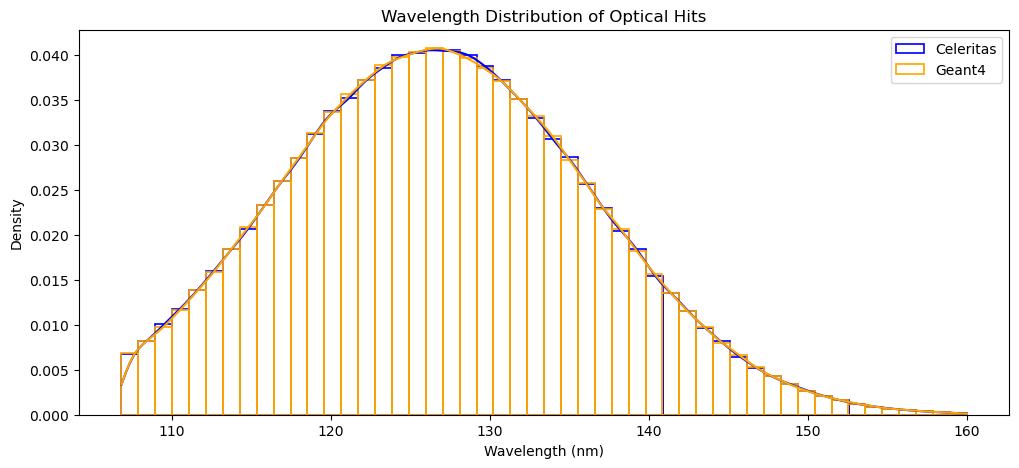

In [134]:
# Compare distributions
plt.figure(figsize=(12, 5))
sns.histplot(celeritas["wavelength"], color="blue", label="Celeritas", kde=True, stat="density", bins=50, fill=False)
sns.histplot(geant["wavelength"], color="orange", label="Geant4", kde=True, stat="density", bins=50, fill=False)
plt.xlabel("Wavelength (nm)")
plt.ylabel("Density")
plt.title("Wavelength Distribution of Optical Hits")
plt.legend()
plt.show()

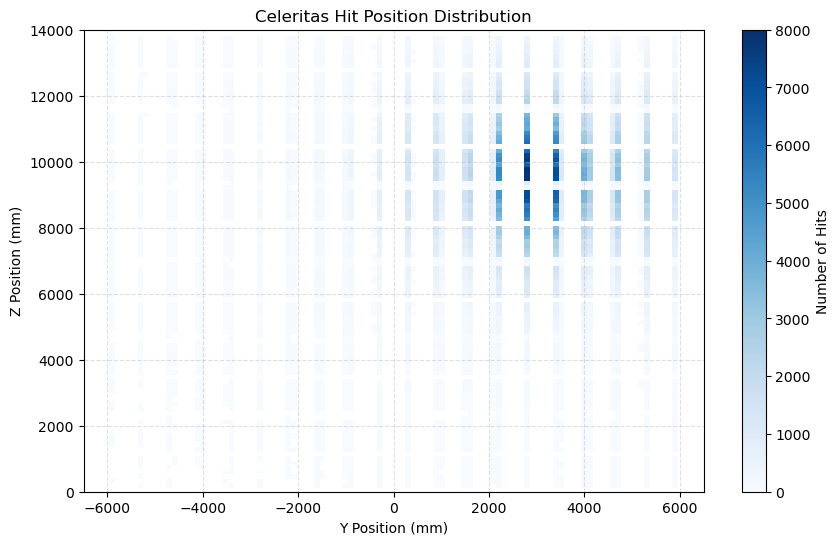

In [223]:
# overlap two comparison of plots for 2d plane distribution with bin content shown virdis and legend showing the number of hits in each bin
plt.figure(figsize=(10, 6))
sns.histplot(celeritas, x="y", y="z", bins=100,  label="Celeritas", alpha=1.0,cbar=True, cbar_kws={'label': 'Number of Hits'}, cmap="Blues")  
plt.xlabel("Y Position (mm)")
plt.ylabel("Z Position (mm)")
plt.xlim(-6500, 6500)
plt.ylim(0, 14000)
plt.title("Celeritas Hit Position Distribution")
plt.grid(linestyle="--", alpha=0.4)
plt.savefig("./celeritas_yz_distribution.png", dpi=300)

plt.show()

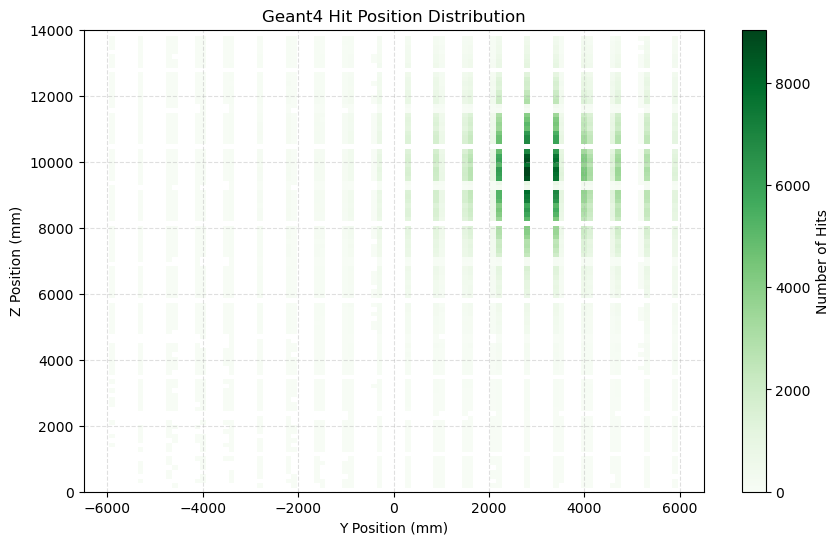

In [224]:
# overlap two comparison of plots for 2d plane distribution with bin content shown virdis and legend showing the number of hits in each bin
plt.figure(figsize=(10, 6))
sns.histplot(geant, x="y", y="z", bins=100,  label="Geant4", alpha=1.0,cbar=True, cbar_kws={'label': 'Number of Hits'}, cmap="Greens")  
plt.xlabel("Y Position (mm)")
plt.ylabel("Z Position (mm)")
plt.xlim(-6500, 6500)
plt.ylim(0, 14000)
plt.title("Geant4 Hit Position Distribution")
plt.savefig("./geant_yz_distribution.png", dpi=300)
plt.grid(linestyle="--", alpha=0.4)
plt.show()

Text(0.5, 1.0, 'Y Position Distribution of Celeritas Hits')

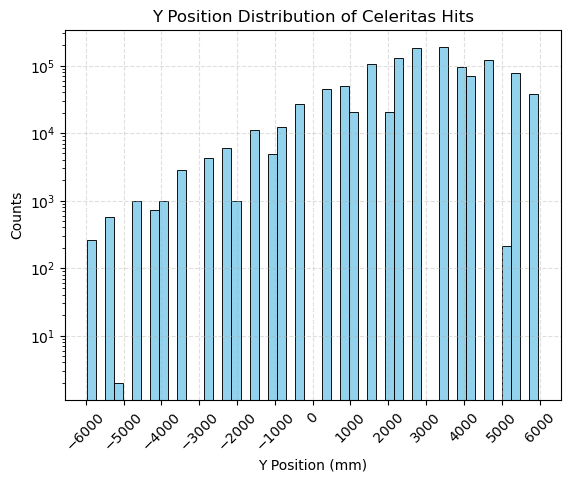

In [225]:
sns.histplot(celeritas["y"], bins=50,  label="Celeritas", alpha=0.9, color = "skyblue")
#sns.histplot(geant["y"], bins=50,  label="Geant4", alpha=0.4, color = "blue")
plt.yscale("log")
plt.xlabel("Y Position (mm)")
plt.ylabel("Counts")
plt.grid(linestyle="--", alpha=0.4,  axis="both")
plt.xticks(np.arange(-6000, 6500, 1000), rotation=45)
plt.savefig("./celeritas_y_distribution.png", dpi=300)
plt.title("Y Position Distribution of Celeritas Hits")

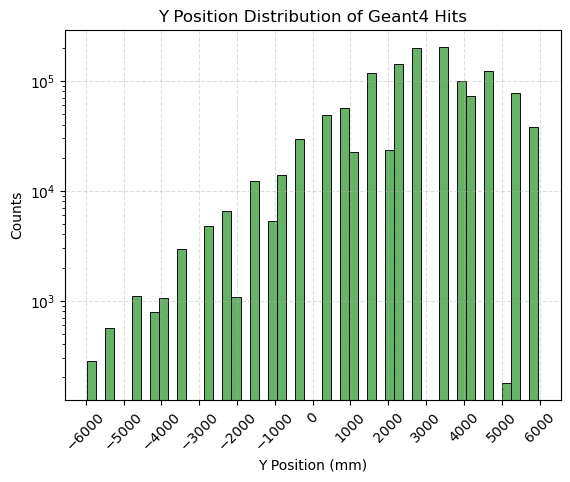

In [226]:
#sns.histplot(celeritas["y"], bins=25,  label="Celeritas", alpha=0.4, color = "black")
sns.histplot(geant["y"], bins=50,  label="Geant4", alpha=0.6, color = "green")
plt.yscale("log")
plt.xlabel("Y Position (mm)")
plt.title("Y Position Distribution of Geant4 Hits")
plt.ylabel("Counts")
plt.grid(linestyle="--", alpha=0.4,  axis="both")
plt.savefig("./geant_y_distribution.png", dpi=300)
plt.xticks(np.arange(-6000, 6500, 1000), rotation=45)
plt.show()

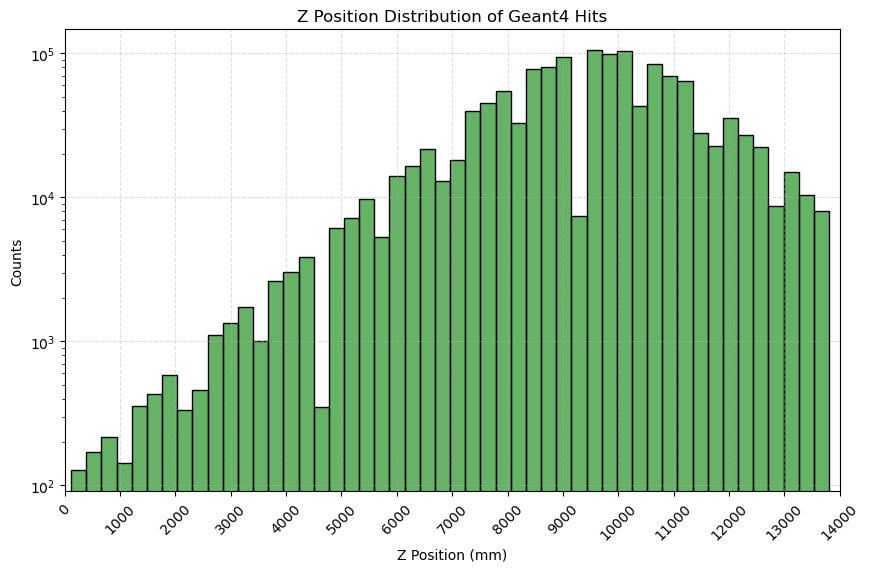

In [227]:
#sns.histplot(celeritas["y"], bins=25,  label="Celeritas", alpha=0.4, color = "black")
plt.figure(figsize=(10, 6))
sns.histplot(geant["z"], bins=50,  label="Geant4", alpha=0.6, color = "green")
plt.yscale("log")
plt.xlabel("Z Position (mm)")
plt.title("Z Position Distribution of Geant4 Hits")
plt.ylabel("Counts")
plt.xlim(0, 14000)
plt.xticks(np.arange(0, 15000, 1000), rotation=45)
plt.grid(linestyle="--", alpha=0.4, axis="both")
plt.savefig("./geant_z_distribution.png", dpi=300)
plt.show()

Text(0.5, 1.0, 'Z Position Distribution of Celeritas Hits')

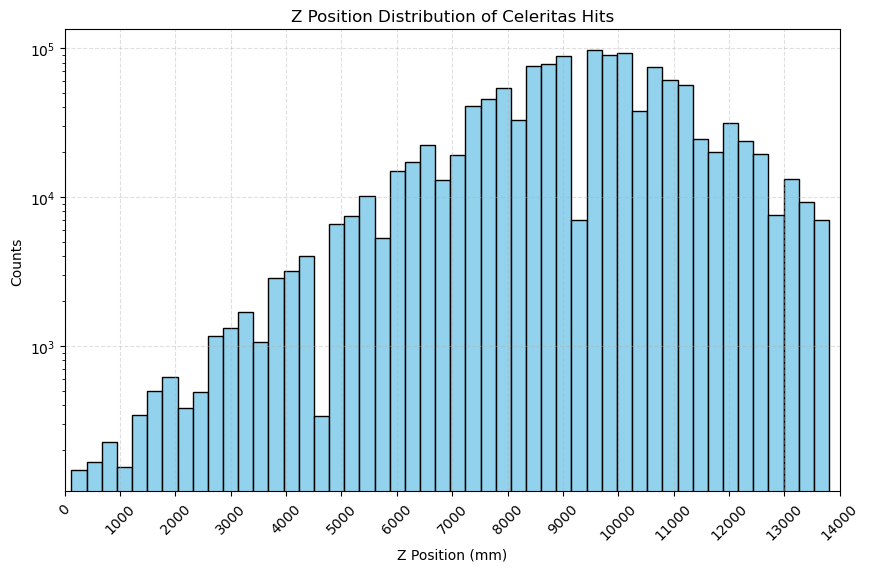

In [228]:
plt.figure(figsize=(10, 6))
sns.histplot(celeritas["z"], bins=50,  label="Celeritas", alpha=0.9, color = "skyblue")
plt.yscale("log")
plt.xlabel("Z Position (mm)")
plt.ylabel("Counts")
plt.grid(linestyle="--", alpha=0.4 ,axis="both")
plt.xlim(0, 14000)
plt.xticks(np.arange(0, 15000, 1000), rotation=45)
plt.savefig("./celeritas_z_distribution.png", dpi=300)
plt.title("Z Position Distribution of Celeritas Hits")

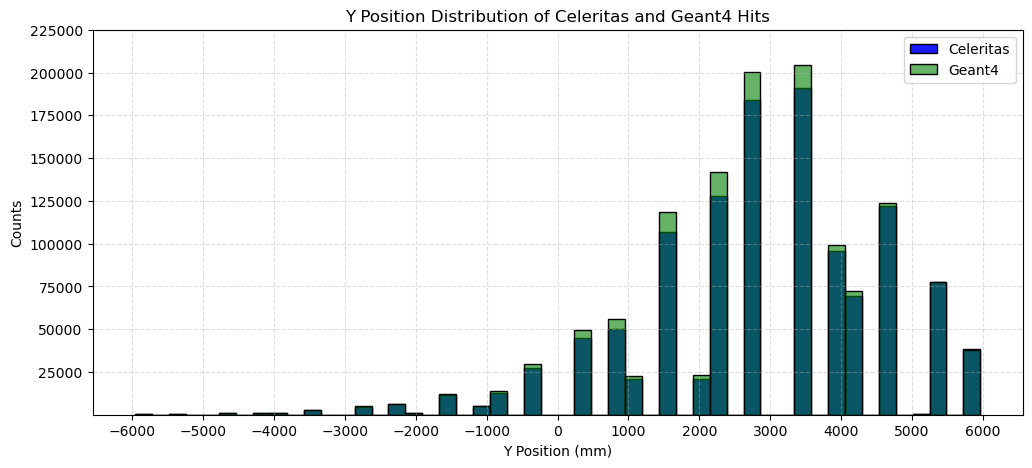

In [229]:
plt.figure(figsize=(12, 5))
sns.histplot(celeritas["y"], bins=50,  label="Celeritas", alpha=0.9, color = "blue")
sns.histplot(geant["y"], bins=50,  label="Geant4", alpha=0.6, color = "green")
plt.xlabel("Y Position (mm)")
#plt.yscale("log")
plt.ylabel("Counts")
plt.title("Y Position Distribution of Celeritas and Geant4 Hits")
plt.grid(linestyle="--", alpha=0.4, axis="both")
plt.ylim(1, 0.225e6)
plt.xticks(np.arange(-6000, 6500, 1000))
plt.legend()
plt.savefig("./y_position_distribution.png", dpi=300)

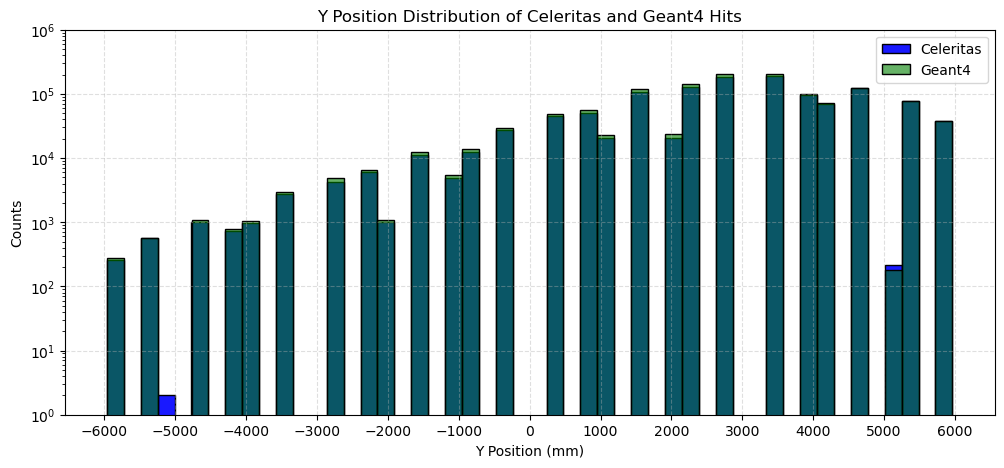

In [230]:
plt.figure(figsize=(12, 5))
sns.histplot(celeritas["y"], bins=50,  label="Celeritas", alpha=0.9, color = "blue")
sns.histplot(geant["y"], bins=50,  label="Geant4", alpha=0.6, color = "green")
plt.xlabel("Y Position (mm)")
plt.yscale("log")
plt.ylabel("Counts")
plt.title("Y Position Distribution of Celeritas and Geant4 Hits")
plt.grid(linestyle="--", alpha=0.4,  axis="both")
plt.xticks(np.arange(-6000, 6500, 1000))
plt.ylim(1, 1e6)
plt.savefig("./y_position_distribution_log.png", dpi=300)
plt.legend()

In [146]:
time_c, edge_c = np.histogram(celeritas["t"], bins=500)
time_g, edge_g = np.histogram(geant["t"], bins=500)
edge_c_centers = (edge_c[:-1] + edge_c[1:]) / 2
edge_g_centers = (edge_g[:-1] + edge_g[1:]) / 2

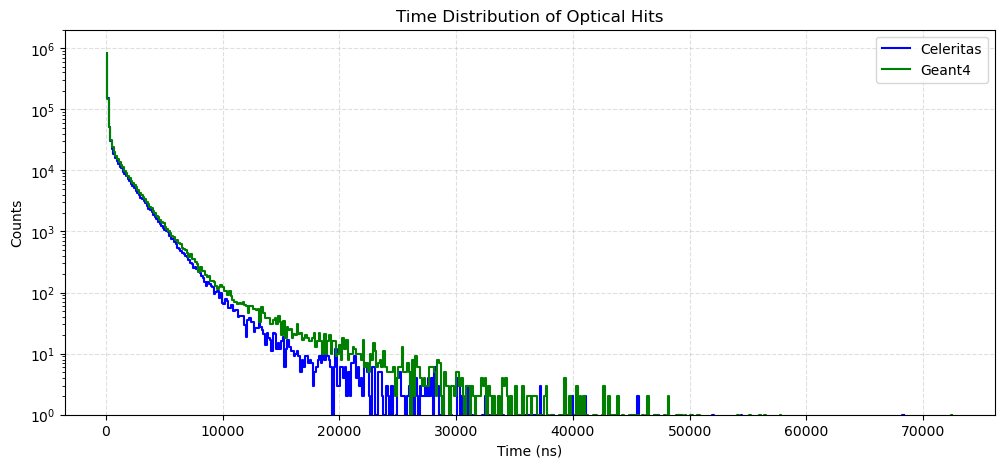

In [147]:
plt.figure(figsize=(12, 5))
plt.step(edge_c_centers, time_c, label="Celeritas", color="blue")
plt.step(edge_g_centers, time_g, label="Geant4", color="green")
plt.xlabel("Time (ns)")
plt.ylabel("Counts")
plt.title("Time Distribution of Optical Hits")
plt.grid(linestyle="--", alpha=0.4,  axis="both")
plt.yscale("log")
plt.ylim(1, 2e6)
plt.legend()
plt.show()

In [130]:
celeritas.shape[0]

1223085

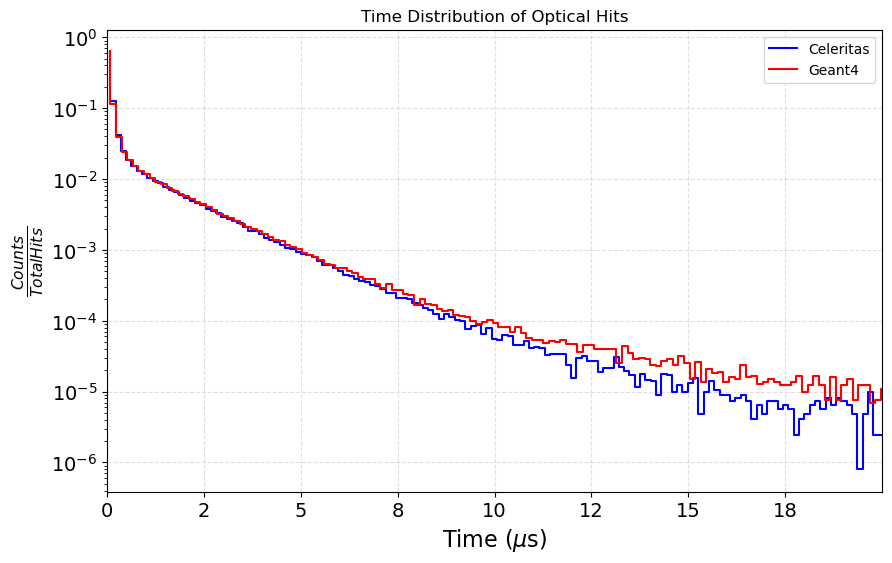

In [172]:
from matplotlib.ticker import ScalarFormatter


from matplotlib.ticker import FuncFormatter
plt.figure(figsize=(10, 6))
plt.step(edge_c_centers, time_c/celeritas.shape[0], label="Celeritas", color="blue")
plt.step(edge_g_centers, time_g/geant.shape[0], label="Geant4", color="red")

plt.yscale("log")
#plt.ylim(1, 1e5)
plt.xlim(0, 20000)
plt.yticks(fontsize=14)

ax = plt.gca()
ax.xaxis.set_major_formatter(
    FuncFormatter(lambda x, pos: f"{x/1000:.0f}")
)

plt.xticks(np.arange(0, 20000, 2500), fontsize=14)

plt.grid(linestyle="--", alpha=0.4,  axis="both")
plt.xlabel(r"Time ($\mu$s)", fontsize=16)
plt.ylabel(r"$\frac{Counts}{Total Hits}$", fontsize=16)
plt.title("Time Distribution of Optical Hits")

plt.legend()
plt.show()


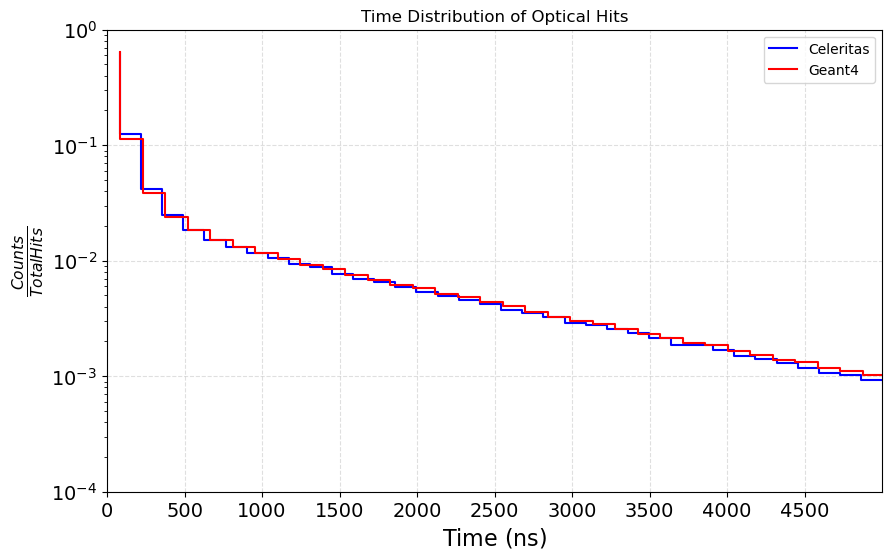

In [169]:
from matplotlib.ticker import ScalarFormatter


from matplotlib.ticker import FuncFormatter
plt.figure(figsize=(10, 6))
plt.step(edge_c_centers, time_c/celeritas.shape[0], label="Celeritas", color="blue")
plt.step(edge_g_centers, time_g/geant.shape[0], label="Geant4", color="red")

plt.yscale("log")
plt.ylim(1e-4, 1)
plt.xlim(0, 5000)
plt.yticks(fontsize=14)

#ax = plt.gca()
#ax.xaxis.set_major_formatter(
#    FuncFormatter(lambda x, pos: f"{x/100:.0f}")
#)

plt.xticks(np.arange(0, 5000, 500), fontsize=14)

plt.grid(linestyle="--", alpha=0.4,  axis="both")
plt.xlabel(r"Time ($\mathrm{ns}$)", fontsize=16)
plt.ylabel(r"$\frac{Counts}{Total Hits}$", fontsize=16)
plt.title("Time Distribution of Optical Hits")

plt.legend()
plt.show()


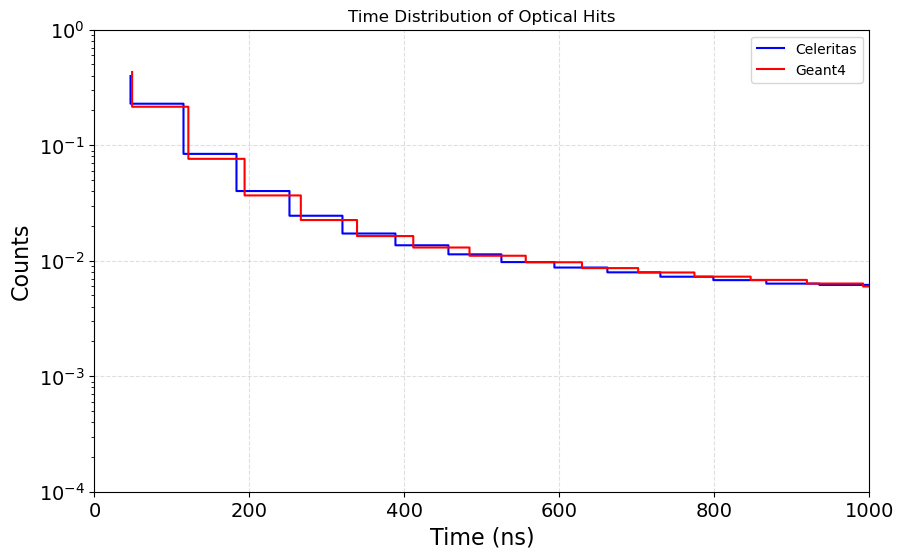

In [143]:
plt.figure(figsize=(10, 6))
plt.step(edge_c_centers, time_c/celeritas.shape[0], label="Celeritas", color="blue")
plt.step(edge_g_centers, time_g/geant.shape[0], label="Geant4", color="red")
plt.xlabel("Time (ns)")
plt.ylabel("Counts")
plt.title("Time Distribution of Optical Hits")
plt.grid(linestyle="--", alpha=0.4,  axis="both")
plt.yscale("log")
plt.ylim(1e-4, 1)
plt.xlim(0, 1000)
plt.xticks(fontsize=14)
plt.yticks(fontsize=14)
plt.ylabel("Counts", fontsize=16)
plt.xlabel("Time (ns)", fontsize=16)
#plt.xticks(np.arange(0, 30000, 100))
plt.legend()
plt.show()


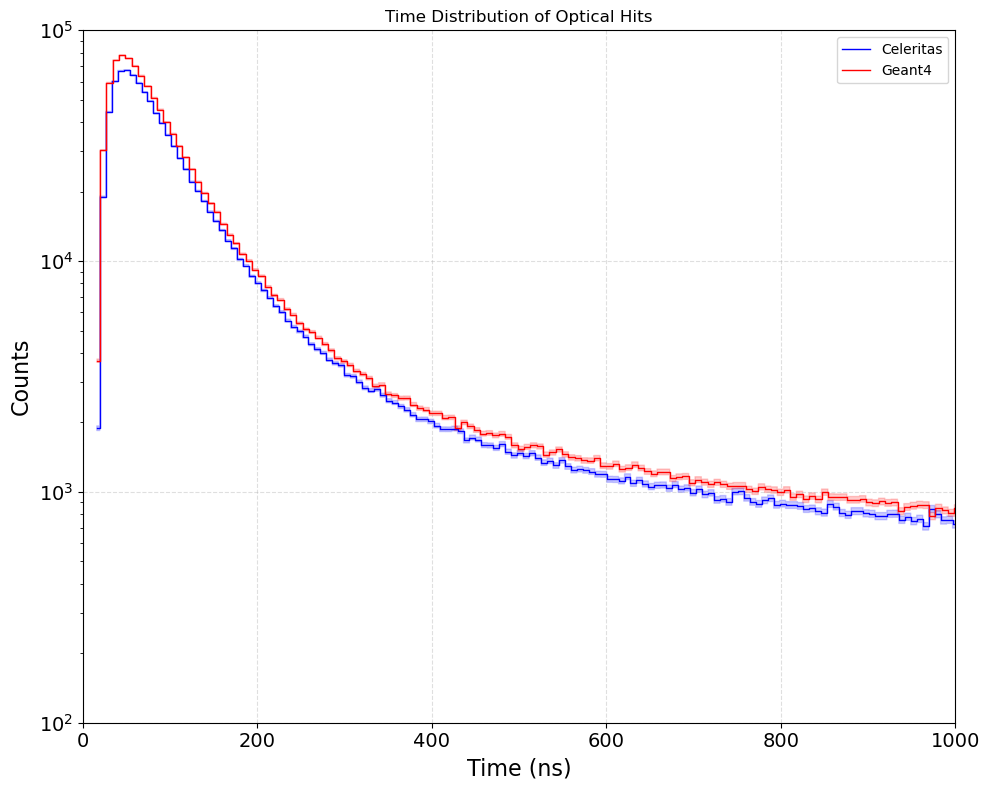

In [125]:
#add error bars to the time distribution plot by taking square root of the counts in each bin as the error
time_c_err = np.sqrt(time_c)
time_g_err = np.sqrt(time_g)
#plot the time distribution with error bars as shaded area around the step plot
plt.figure(figsize=(10, 8))
plt.step(
    edge_c_centers,
    time_c,
    where="mid",
    color="blue",
    linewidth=1,
    label="Celeritas"
)

plt.fill_between(
    edge_c_centers,
    time_c - time_c_err,  # avoid negative values on log scale
    time_c + time_c_err,
    step="mid",
    color="blue",
    alpha=0.2
)

# Geant4
plt.step(
    edge_g_centers,
    time_g,
    where="mid",
    color="red",
    linewidth=1,
    label="Geant4"
)

plt.fill_between(
    edge_g_centers,
    time_g - time_g_err,  # avoid negative values on log scale
    time_g + time_g_err,
    step="mid",
    color="red",
    alpha=0.2
)   

plt.xlabel("Time (ns)", fontsize=16)
plt.ylabel("Counts", fontsize=16)
plt.title("Time Distribution of Optical Hits")

plt.grid(linestyle="--", alpha=0.4)
plt.yscale("log")
plt.ylim(100, 1e5)
plt.xlim(0, 1000)

plt.xticks(fontsize=14)
plt.yticks(fontsize=14)
plt.legend()
plt.tight_layout()
plt.show()

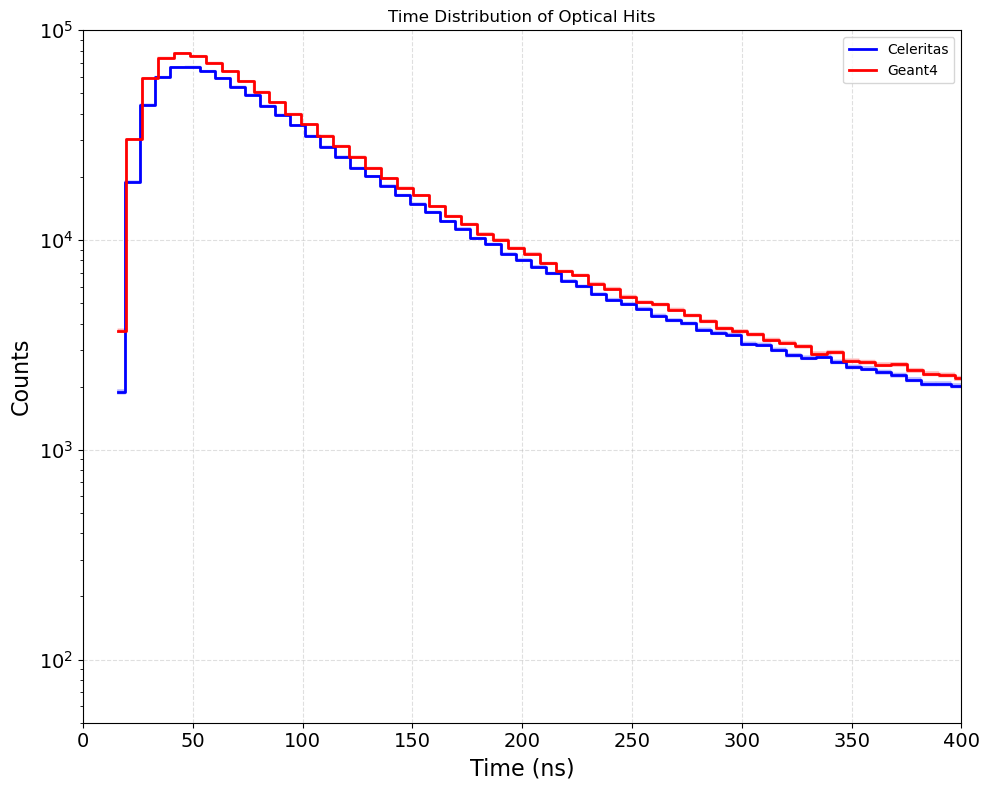

In [123]:
#add error bars to the time distribution plot by taking square root of the counts in each bin as the error
time_c_err = np.sqrt(time_c)
time_g_err = np.sqrt(time_g)
#plot the time distribution with error bars as shaded area around the step plot
plt.figure(figsize=(10, 8))
plt.step(
    edge_c_centers,
    time_c,
    where="mid",
    color="blue",
    linewidth=2,
    label="Celeritas"
)

plt.fill_between(
    edge_c_centers,
    time_c - time_c_err,  # avoid negative values on log scale
    time_c + time_c_err,
    step="mid",
    color="blue",
    alpha=0.2
)

# Geant4
plt.step(
    edge_g_centers,
    time_g,
    where="mid",
    color="red",
    linewidth=2,
    label="Geant4"
)

plt.fill_between(
    edge_g_centers,
    time_g - time_g_err,  # avoid negative values on log scale
    time_g + time_g_err,
    step="mid",
    color="red",
    alpha=0.2
)   

plt.xlabel("Time (ns)", fontsize=16)
plt.ylabel("Counts", fontsize=16)
plt.title("Time Distribution of Optical Hits")

plt.grid(linestyle="--", alpha=0.4)
plt.yscale("log")
plt.ylim(50, 1e5)
plt.xlim(0, 400)

plt.xticks(fontsize=14)
plt.yticks(fontsize=14)
plt.legend()
plt.tight_layout()
plt.show()

In [91]:
time_g

array([1098369,   77854,   45641,   28860,   18289,   11900,    7859,
          5080,    3529,    2371,    1750,    1122,     820,     621,
           497,     346,     306,     278,     227,     173,     163,
           128,     111,      95,      85,      85,      72,      57,
            65,      55,      48,      49,      38,      26,      24,
            35,      26,      20,      26,      20,      15,      18,
            12,       9,      15,       9,       9,      11,       5,
             5,       8,       4,       5,       2,       9,       5,
             6,       2,       4,       4,       3,       2,       4,
             2,       3,       1,       3,       2,       2,       3,
             1,       0,       0,       0,       1,       0,       1,
             2,       0,       1,       0,       0,       0,       0,
             0,       0,       0,       0,       0,       0,       0,
             0,       0,       0,       0,       0,       0,       0,
             0,     

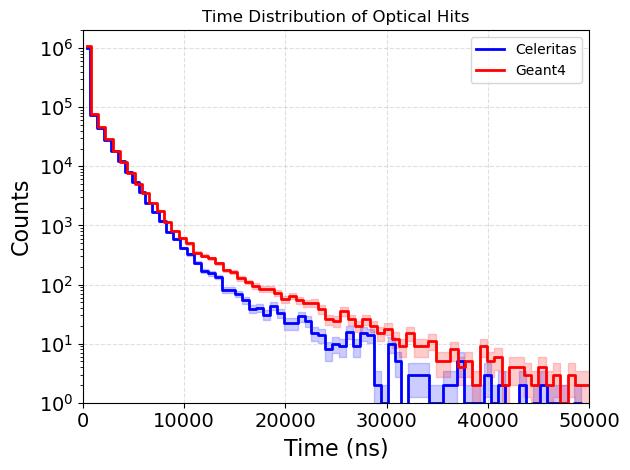

In [93]:
#add error bars to the time distribution plot by taking square root of the counts in each bin as the error
time_c_err = np.sqrt(time_c)
time_g_err = np.sqrt(time_g)
#plot the time distribution with error bars as shaded area around the step plot

plt.step(
    edge_c_centers,
    time_c,
    where="mid",
    color="blue",
    linewidth=2,
    label="Celeritas"
)

plt.fill_between(
    edge_c_centers,
    time_c - time_c_err,  # avoid negative values on log scale
    time_c + time_c_err,
    step="mid",
    color="blue",
    alpha=0.2
)

# Geant4
plt.step(
    edge_g_centers,
    time_g,
    where="mid",
    color="red",
    linewidth=2,
    label="Geant4"
)

plt.fill_between(
    edge_g_centers,
    time_g - time_g_err,  # avoid negative values on log scale
    time_g + time_g_err,
    step="mid",
    color="red",
    alpha=0.2
)

plt.xlabel("Time (ns)", fontsize=16)
plt.ylabel("Counts", fontsize=16)
plt.title("Time Distribution of Optical Hits")

plt.grid(linestyle="--", alpha=0.4)
plt.yscale("log")
plt.ylim(1, 2e6)
plt.xlim(0, 50000)

plt.xticks(fontsize=14)
plt.yticks(fontsize=14)
plt.legend()
plt.tight_layout()
plt.show()

/var/folders/5l/8wq0wlqx6mzb26dfrnrf56t80000gp/T/ipykernel_15655/1142256148.py:1: RuntimeWarning: divide by zero encountered in divide
  ratio = time_c / time_g
/var/folders/5l/8wq0wlqx6mzb26dfrnrf56t80000gp/T/ipykernel_15655/1142256148.py:1: RuntimeWarning: invalid value encountered in divide
  ratio = time_c / time_g


(array([-0.2,  0. ,  0.2,  0.4,  0.6,  0.8,  1. ,  1.2]),
 [Text(0, -0.2, '−0.2'),
  Text(0, 0.0, '0.0'),
  Text(0, 0.2, '0.2'),
  Text(0, 0.4000000000000001, '0.4'),
  Text(0, 0.6000000000000001, '0.6'),
  Text(0, 0.8, '0.8'),
  Text(0, 1.0000000000000002, '1.0'),
  Text(0, 1.2000000000000002, '1.2')])

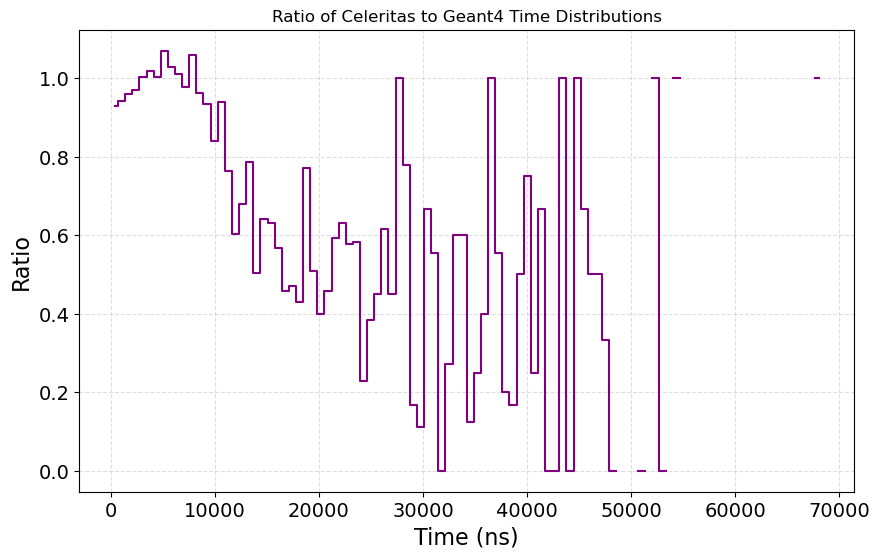

In [95]:
ratio = time_c / time_g
plt.figure(figsize=(10, 6))
plt.step(edge_c_centers, ratio, where="mid", color="purple", label="Celeritas/Geant4 Ratio")
plt.xlabel("Time (ns)", fontsize=16)
plt.ylabel("Ratio", fontsize=16)
plt.title("Ratio of Celeritas to Geant4 Time Distributions")
plt.grid(linestyle="--", alpha=0.4)
#plt.xlim(0, 50000)
plt.xticks(fontsize=14)
plt.yticks(fontsize=14)

In [ ]:
plt.err

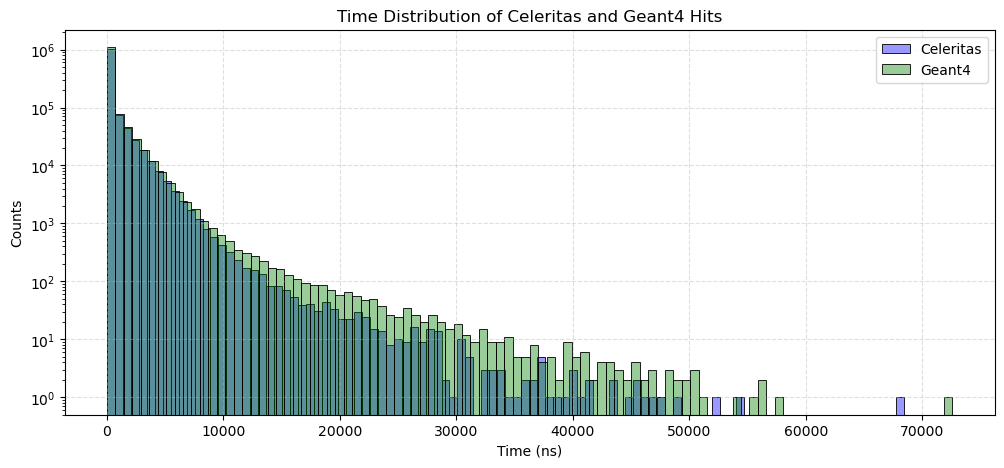

In [60]:
plt.figure(figsize=(12, 5))
sns.histplot(celeritas["t"], bins=100,  label="Celeritas", alpha=0.4, color = "blue")
sns.histplot(geant["t"], bins=100,  label="Geant4", alpha=0.4, color = "green")
plt.xlabel("Time (ns)")
plt.yscale("log")
plt.ylabel("Counts")
plt.title("Time Distribution of Celeritas and Geant4 Hits")
plt.grid(linestyle="--", alpha=0.4,  axis="both")
#plt.xticks(np.arange(0, 1500, 100))
plt.legend()
#plt.savefig("./time_distribution.png", dpi=300)

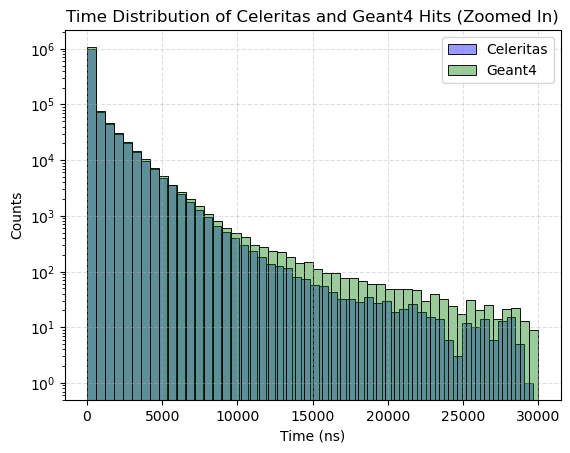

In [233]:
sns.histplot(celeritas[celeritas["t"]<30000]["t"], bins=50,  label="Celeritas", alpha=0.4, color = "blue")
sns.histplot(geant[geant["t"]<30000]["t"], bins=50,  label="Geant4", alpha=0.4, color = "green")
plt.xlabel("Time (ns)")
plt.yscale("log")
plt.ylabel("Counts")
plt.title("Time Distribution of Celeritas and Geant4 Hits (Zoomed In)")
plt.grid(linestyle="--", alpha=0.4,  axis="both")
plt.legend()
plt.savefig("./time_distribution_zoomed.png", dpi=300)

In [216]:
counts1, edges = np.histogram(celeritas["t"], bins=100)
counts2, _ = np.histogram(geant["t"], bins=100)

In [219]:
centers = 0.5 * (edges[:-1] + edges[1:])

# Residuals
residuals = (counts1 - counts2) / np.sqrt(counts2)


/var/folders/5l/8wq0wlqx6mzb26dfrnrf56t80000gp/T/ipykernel_22219/3341222430.py:4: RuntimeWarning: divide by zero encountered in divide
  residuals = (counts1 - counts2) / np.sqrt(counts2)
/var/folders/5l/8wq0wlqx6mzb26dfrnrf56t80000gp/T/ipykernel_22219/3341222430.py:4: RuntimeWarning: invalid value encountered in divide
  residuals = (counts1 - counts2) / np.sqrt(counts2)


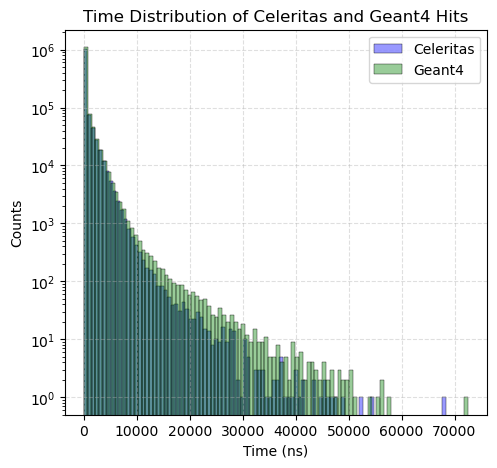

In [215]:
#plot histogram of time and then plot the residual of the two histograms to see if there is any difference in the time distribution of the hits between Celeritas and Geant4
plt.figure(figsize=(12, 5))
plt.subplot(1, 2, 1)
sns.histplot(celeritas["t"], bins=100,  label="Celeritas", alpha=0.4, color = "blue")
sns.histplot(geant["t"], bins=100,  label="Geant4", alpha=0.4, color = "green")
plt.xlabel("Time (ns)")
plt.yscale("log")
plt.ylabel("Counts")
plt.title("Time Distribution of Celeritas and Geant4 Hits")
plt.grid(linestyle="--", alpha=0.4,  axis="both")
plt.legend()

Text(0.5, 0, 'Value')

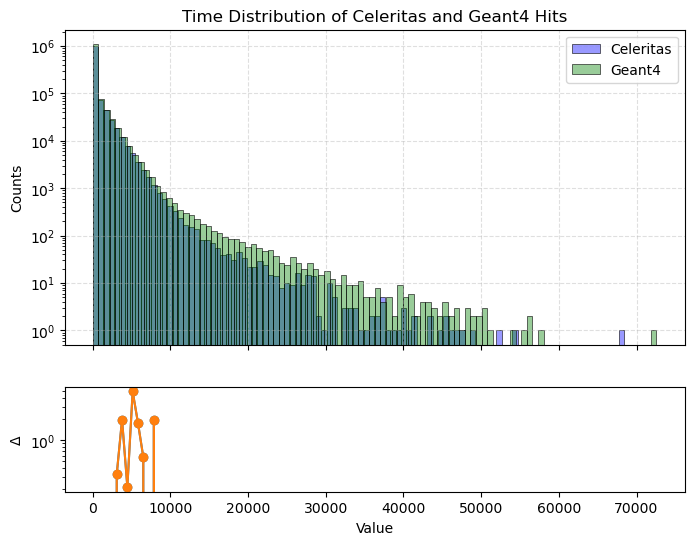

In [221]:
fig, (ax1, ax2) = plt.subplots(
    2, 1,
    figsize=(8, 6),
    sharex=True,
    gridspec_kw={"height_ratios": [3, 1]}
)
sns.histplot(celeritas["t"], bins=100,  label="Celeritas", alpha=0.4, color = "blue", ax=ax1)
sns.histplot(geant["t"], bins=100,  label="Geant4", alpha=0.4, color = "green", ax=ax1)
ax1.set_xlabel("Time (ns)")
ax1.set_yscale("log")
ax1.set_ylabel("Counts")
ax1.set_title("Time Distribution of Celeritas and Geant4 Hits")
ax1.grid(linestyle="--", alpha=0.4,  axis="both")
ax1.legend()

ax2.axhline(0, linestyle="--", linewidth=1)
ax2.plot(centers, residuals, marker="o")
ax2.set_yscale("log")
ax2.set_ylabel("Δ")
ax2.set_xlabel("Time (ns)")
ax2.axhline(0, linestyle="--", linewidth=1)
ax2.plot(centers, residuals, marker="o")
ax2.set_ylabel("Δ")
ax2.set_xlabel("Value")

In [20]:
# would like to now ray trace using these x.y.z and draw it in gdml
# Since, these points are a lot can we shorten the number of points without losing the information of the points.maybe some sort of interpolation.
def plot_3d_hits(df, title):
    fig = plt.figure(figsize=(10, 7))
    ax = fig.add_subplot(111, projection='3d')
    # keep x as same but bin or compress y and z to reduce the number of points plotted where color of the points is the number of hits in that bin and the size of the points is the average time of the hits in that bin 

    df['y_bin'] = pd.cut(df['y'], bins=100, labels=False)
    df['z_bin'] = pd.cut(df['z'], bins=100, labels=False)
    counts = df.groupby(['x_bin', 'y_bin', 'z_bin']).size().reset_index(name='counts')
    time_avg = df.groupby(['x_bin', 'y_bin', 'z_bin'])['t'].mean().reset_index(name='time_avg')
    df_binned = pd.merge(counts, time_avg, on=['x_bin', 'y_bin', 'z_bin'])
    sc = ax.scatter(df['x'], df['y_bin'], df['z_bin'], cmap='viridis', alpha=0.5)
    plt.colorbar(sc, label='Average Time (ns)')
    ax.set_xlabel('X Position (mm)')
    ax.set_ylabel('Y Bin')
    ax.set_zlabel('Z Bin')
    ax.set_title(title)
    plt.show()


/var/folders/5l/8wq0wlqx6mzb26dfrnrf56t80000gp/T/ipykernel_7428/1669567576.py:13: UserWarning: No data for colormapping provided via 'c'. Parameters 'cmap' will be ignored
  sc = ax.scatter(df['x'], df['y_bin'], df['z_bin'], cmap='viridis', alpha=0.5)


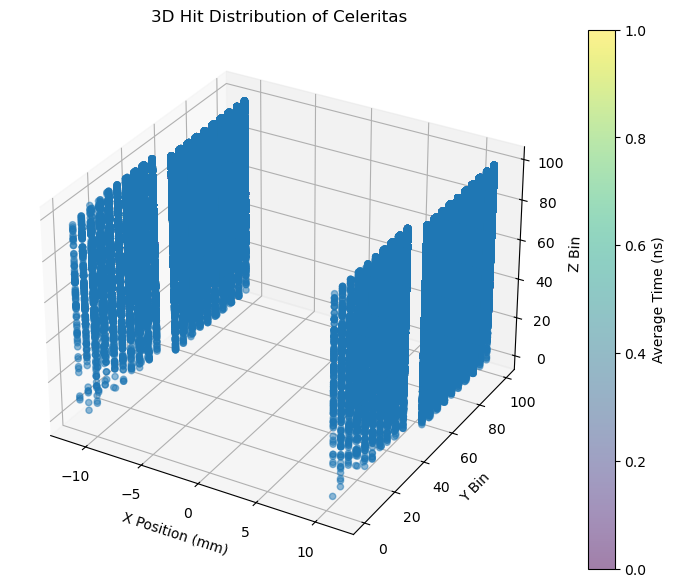

In [21]:
plot_3d_hits(celeritas, "3D Hit Distribution of Celeritas")


In [ ]:
# let us approximate y and z coordinates by binning them into 100 bins each and then plot the 3D distribution of hits with x as the x-axis, binned y as the y-axis and binned z as the z-axis. The color of the points will represent the number of hits in that bin and the size of the points will represent the average time of the hits in that bin. This way we can visualize the distribution of hits in 3D while reducing the number of points plotted.
def plot_3d_hits(df, title): 
    fig = plt.figure(figsize=(10, 7))
    ax = fig.add_subplot(111, projection='3d')
    # keep x as same but bin or compress y and z to reduce the number of points plotted where color of the points is the number of hits in that bin and the size of the points is the average time of the hits in that bin 

    df['y_bin'] = pd.cut(df['y'], bins=100, labels=False)
    df['z_bin'] = pd.cut(df['z'], bins=100, labels=False)
    counts = df.groupby(['x_bin', 'y_bin', 'z_bin']).size().reset_index(name='counts')
    time_avg = df.groupby(['x_bin', 'y_bin', 'z_bin'])['t'].mean().reset_index(name='time_avg')
    df_binned = pd.merge(counts, time_avg, on=['x_bin', 'y_bin', 'z_bin'])
    sc = ax.scatter(df['x'], df['y_bin'], df['z_bin'], cmap='viridis', alpha=0.5)
    plt.colorbar(sc, label='Average Time (ns)')
    ax.set_xlabel('X Position (mm)')
    ax.set_ylabel('Y Bin')
    ax.set_zlabel('Z Bin')
    ax.set_title(title)
    plt.show()

In [ ]:
# define new dataframe binned y and z and since x is just three values so also store the bincontent and the edges of this bin
df_binned = df.copy()
df_binned['y_bin'] = pd.cut(df['y'], bins=100, labels=False)
df_binned['z_bin'] = pd.cut(df['z'], bins=100, labels=False)
df_binned['y_bin_edges'] = pd.cut(df['y'], bins=100)
df_binned['z_bin_edges'] = pd.cut(df['z'], bins=100)

In [55]:

bin_counts_z, bin_edges_z = np.histogram(celeritas['z'], bins=12000)
bin_counts_y, bin_edges_y = np.histogram(celeritas['y'], bins=12000)

Text(0.5, 1.0, 'Binned Counts of Y and Z Positions')

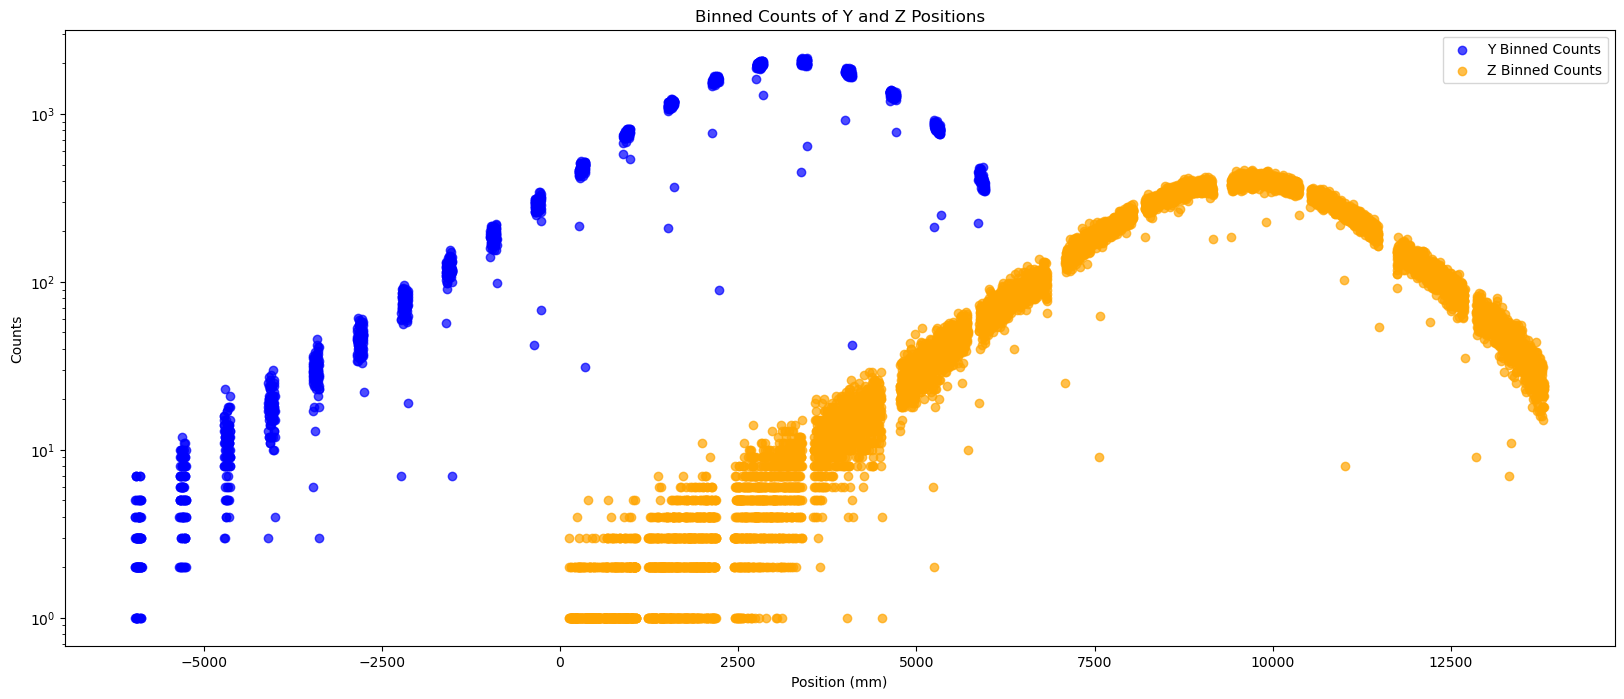

In [61]:
plt.figure(figsize=(20, 8))
plt.scatter(bin_edges_y[:-1], bin_counts_y, label="Y Binned Counts", color="blue", alpha=0.7) 
plt.scatter(bin_edges_z[:-1], bin_counts_z, label="Z Binned Counts", color="orange", alpha=0.7)
plt.legend()
plt.xlabel("Position (mm)")
plt.ylabel("Counts")
plt.yscale("log")
#plt.xlim(-6500, 6500)
#plt.xticks(np.arange(-6000, 6500, 1000), rotation=45)
plt.title("Binned Counts of Y and Z Positions")

In [64]:
# do 2d histogram of y and z such that y is on x-axis and z is on y-axis and the color of the bins is the number of hits in that bin
# get these numbers first and then plot the 2d histogram with the binned counts as the color of the bins and the edges of the bins as the x and y axis
np.histogram2d(celeritas['y'], celeritas['z'], bins=100)
content,y_edges, z_edges = np.histogram2d(celeritas['y'], celeritas['z'], bins=100)


In [14]:
celeritas['x'].unique()

array([ 1.14999998,  1.04999995, -1.04999995, -1.14999998])

In [116]:
x_values[2]

11

In [41]:
# now let us divide the y and z based on different values of x and then plot the 2d histogram of y and z for each value of x to see if there is any difference in the distribution of hits in y and z based on the x position of the hits. This way we can see if there is any correlation between the x position and the distribution of hits in y and z.
x_values = celeritas['x'].unique()
celeritas_x0 = celeritas[(celeritas['x']<1.15) & (celeritas['x']>1.05)]
celeritas_x1 = celeritas[(celeritas['x']<1.05) & (celeritas['x']>-1.04)]
celeritas_x2 = celeritas[(celeritas['x']<-1.05) & (celeritas['x']>-1.15)]
celeritas_x3 = celeritas[celeritas['x'] < -1.14]


In [43]:
count_x0,y_edges_x0, z_edges_x0 = np.histogram2d(celeritas_x0['y'], celeritas_x0['z'], bins=10000)
count_x1,y_edges_x1, z_edges_x1 = np.histogram2d(celeritas_x1['y'], celeritas_x1['z'], bins=10000)
count_x2,y_edges_x2, z_edges_x2 = np.histogram2d(celeritas_x2['y'], celeritas_x2['z'], bins=10000)
count_x3,y_edges_x3, z_edges_x3 = np.histogram2d(celeritas_x3['y'], celeritas_x3['z'], bins=10000)

In [6]:
#make the length of x[v] same as the length of y_edges and z_edges
x_values_0 = np.repeat(11.49999976, (len(y_edges_x0)-1))
x_values_1 = np.repeat(10.49999952, (len(y_edges_x1)-1))
x_values_2 = np.repeat(-10.4999995, (len(y_edges_x2)-1))
x_values_3 = np.repeat(-11.4999997, (len(y_edges_x3)-1))

In [51]:
r = pd.DataFrame({"x": x_values_0, "y": y_edges_x0[:-1], "z": z_edges_x0[:-1]})
s = pd.DataFrame({"x": x_values_1, "y": y_edges_x1[:-1], "z": z_edges_x1[:-1]})
t = pd.DataFrame({"x": x_values_2, "y": y_edges_x2[:-1], "z": z_edges_x2[:-1]})
u = pd.DataFrame({"x": x_values_3, "y": y_edges_x3[:-1], "z": z_edges_x3[:-1]})

In [52]:
final = pd.concat([r, s, t, u], ignore_index=True)
final

,x,y,z
0,11.5,26.485275,12.356644
1,11.5,26.542248,12.493492
2,11.5,26.599222,12.630341
3,11.5,26.656195,12.767189
4,11.5,26.713168,12.904038
...,...,...,...
39995,-11.5,-26.770365,1380.112976
39996,-11.5,-26.713395,1380.249804
39997,-11.5,-26.656424,1380.386633
39998,-11.5,-26.599453,1380.523462


In [53]:
final.to_json("./celeritas_coords.jsonl", orient="records", lines=True)

In [125]:
df_celeritas['x'].value_counts()

x
 11.500000    10000
 10.500000    10000
-10.499999    10000
-11.500000    10000
Name: count, dtype: int64

In [46]:
y_edges_x0

array([ 26.48527527,  26.54224846,  26.59922166, ..., 596.10327773,
       596.16025093, 596.21722412])

Text(0.5, 0, 'Z Bin')

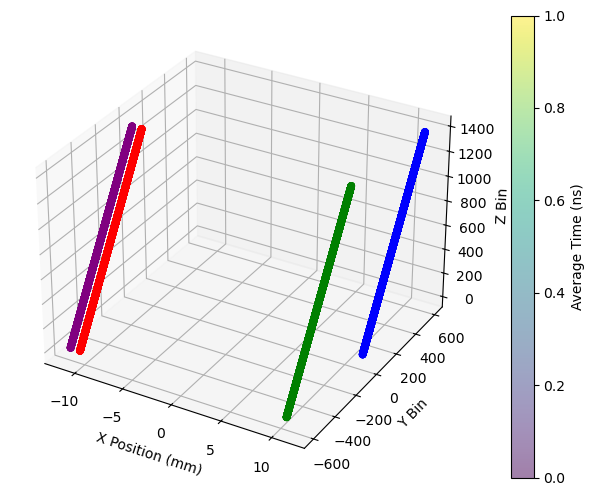

In [44]:
#plt.scatter(x_values_0, y_edges_x0[:-1],z_edges_x0[:-1], c='blue',alpha=0.5)
#plt.scatter(x_values_1, y_edges_x1[:-1],z_edges_x1[:-1], c='green',alpha=0.5)
##plt.scatter(x_values_2, z_edges_x2[:-1], c='red',alpha=0.5)
##plt.scatter(x_values_3, z_edges_x3[:-1], c='purple',alpha=0.5)
#plt.colorbar(label='Number of Hits')
#plt.xlabel("Y Position (mm)")
#plt.ylabel("Z Position (mm)")
#plt.title("2D Histogram of Y and Z Positions with Hit Counts as Color")
fig = plt.figure(figsize=(10, 6))
ax = fig.add_subplot(111, projection='3d')
    # keep x as same but bin or compress y and z to reduce the number of points plotted where color of the points is the number of hits in that bin and the size of the points is the average time of the hits in that bin 

sc = ax.scatter(x_values_0, y_edges_x0[:-1], z_edges_x0[:-1], c='blue', alpha=0.5)
sc = ax.scatter(x_values_1, y_edges_x1[:-1], z_edges_x1[:-1], c='green', alpha=0.5)
sc = ax.scatter(x_values_2, y_edges_x2[:-1], z_edges_x2[:-1], c='red', alpha=0.5)
sc = ax.scatter(x_values_3, y_edges_x3[:-1], z_edges_x3[:-1], c='purple', alpha=0.5)
plt.colorbar(sc, label='Average Time (ns)')
ax.set_xlabel('X Position (mm)')
ax.set_ylabel('Y Bin')
ax.set_zlabel('Z Bin')


Text(0.5, 1.0, '2D Histogram of Y and Z Positions with Hit Counts as Color')

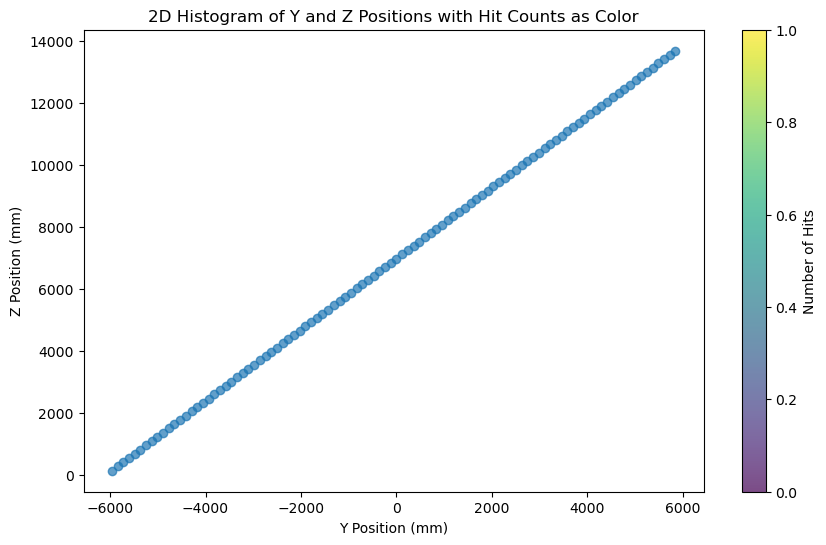

In [70]:
#draw ray tracing of the hits using the y_eges and z_edges as the coordinates of the hits and the color of points as the number of hits in that bin 
plt.figure(figsize=(10, 6))
plt.scatter(y_edges[:-1], z_edges[:-1], alpha=0.7)
plt.colorbar(label='Number of Hits')
plt.xlabel("Y Position (mm)")
plt.ylabel("Z Position (mm)")
plt.title("2D Histogram of Y and Z Positions with Hit Counts as Color")

In [67]:
z_edges

array([  123.56643677,   260.41630707,   397.26617737,   534.11604767,
         670.96591797,   807.81578827,   944.66565857,  1081.51552887,
        1218.36539917,  1355.21526947,  1492.06513977,  1628.91501007,
        1765.76488037,  1902.61475067,  2039.46462097,  2176.31449127,
        2313.16436157,  2450.01423187,  2586.86410217,  2723.71397247,
        2860.56384277,  2997.41371307,  3134.26358337,  3271.11345367,
        3407.96332397,  3544.81319427,  3681.66306458,  3818.51293488,
        3955.36280518,  4092.21267548,  4229.06254578,  4365.91241608,
        4502.76228638,  4639.61215668,  4776.46202698,  4913.31189728,
        5050.16176758,  5187.01163788,  5323.86150818,  5460.71137848,
        5597.56124878,  5734.41111908,  5871.26098938,  6008.11085968,
        6144.96072998,  6281.81060028,  6418.66047058,  6555.51034088,
        6692.36021118,  6829.21008148,  6966.05995178,  7102.90982208,
        7239.75969238,  7376.60956268,  7513.45943298,  7650.30930328,
      

In [97]:
celeritas

,x,y,z,t,wavelength,y_bin,z_bin,x_bin
0,11.5,2775.119934,9938.618774,7.134958e-08,113.627586,73,71,99
1,11.5,2201.779175,10732.492676,1.819273e-06,111.938408,68,77,99
2,11.5,3457.808228,10332.380371,2.224015e-08,126.112885,78,74,99
3,11.5,3420.751953,10913.900146,3.538051e-08,134.773605,78,78,99
4,11.5,3397.423401,8462.372437,2.291818e-08,131.880310,78,60,99


In [99]:
celeritas.

TypeError: 'int' object is not callable

### after adding step length and num steps to the ntuple
0.5 GeV electrons, 1 event

In [178]:
file_cele = uproot.open("/Users/r1i/Desktop/OpticalSims-upstream/build/dune10kt_v5_refactored_1x2x6_e_500MeV_cele.root")

TREE_NAME_cele = "CeleritasHits;1"
BRANCHES = ["x", "y","z","t","wavelength", "pathLength", "numSteps"]
celeritas = file_cele[TREE_NAME_cele].arrays(BRANCHES, library="pd")

In [181]:
celeritas["pathLength"] =celeritas["pathLength"] * 10 # convert from cm to mm

In [179]:
file_g4 = uproot.open("/Users/r1i/Desktop/OpticalSims-upstream/build/dune10kt_v5_refactored_1x2x6_e_500MeV_g4.root")

TREE_NAME_g4 = "Geant4Hits;1"
BRANCHES = ["x", "y","z","t","wavelength","stepLength","numSteps"]
geant = file_g4[TREE_NAME_g4].arrays(BRANCHES, library="pd")

In [233]:
num_steps_c, nstep_edges_c = histogram_distribution(celeritas, "numSteps", bins=100)
num_steps_g, nstep_edges_g = histogram_distribution(geant, "numSteps", bins=100)

In [228]:
step_length_c, step_edges_c = histogram_distribution(celeritas, "pathLength", bins=500)
step_length_g, step_edges_g = histogram_distribution(geant, "stepLength", bins=500)

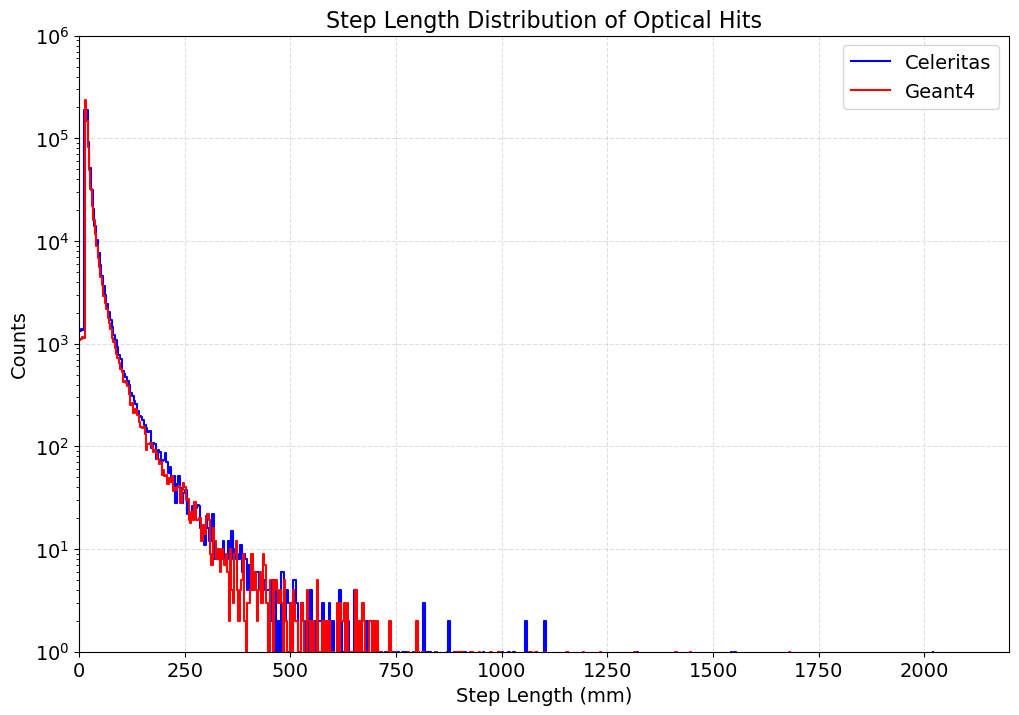

In [202]:
plt.figure(figsize=(12, 8))
plt.step(step_edges_c, step_length_c, where="mid", label="Celeritas", color="blue")
plt.step(step_edges_g, step_length_g, where="mid", label="Geant4", color="red")
plt.yscale("log")
plt.ylim(1, 1e6)
plt.xlim(0, 2200)
plt.xlabel("Step Length (mm)", fontsize=14)
plt.ylabel("Counts", fontsize=14)
plt.title("Step Length Distribution of Optical Hits", fontsize=16)
plt.grid(linestyle="--", alpha=0.4,  axis="both")
plt.xticks(fontsize=14)
plt.yticks(fontsize=14)
plt.legend(fontsize=14)
plt.show()

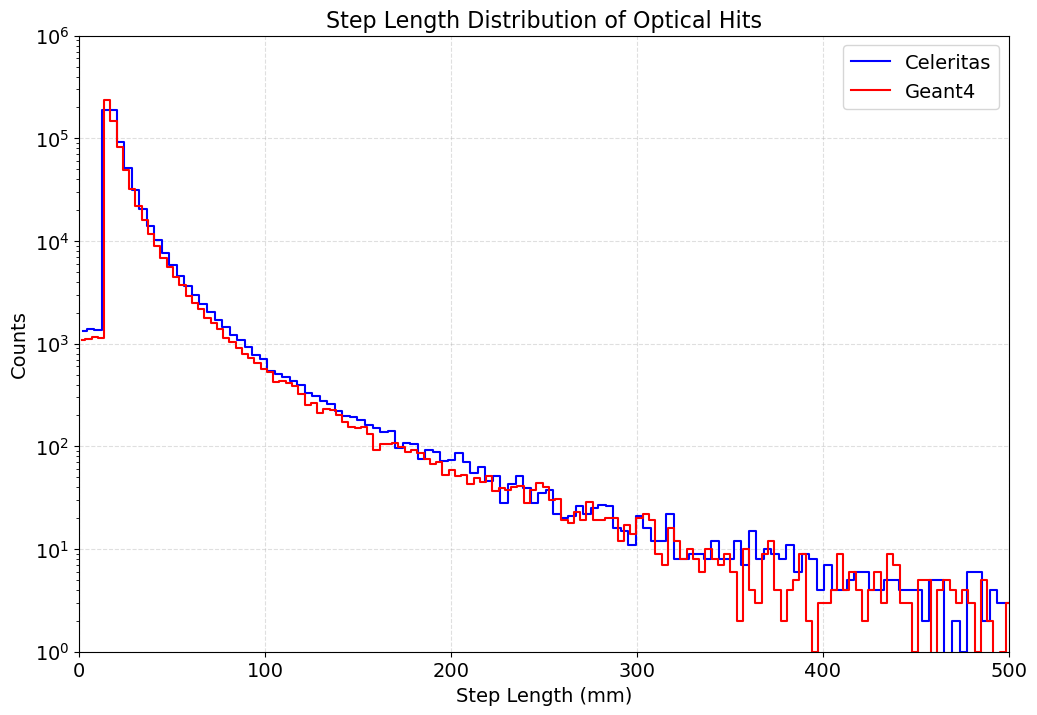

In [201]:
plt.figure(figsize=(12, 8))
plt.step(step_edges_c, step_length_c, where="mid", label="Celeritas", color="blue")
plt.step(step_edges_g, step_length_g, where="mid", label="Geant4", color="red")
plt.yscale("log")
plt.ylim(1, 1e6)
plt.xlim(0, 500)
plt.xlabel("Step Length (mm)", fontsize=14)
plt.ylabel("Counts", fontsize=14)
plt.title("Step Length Distribution of Optical Hits", fontsize=16)
plt.grid(linestyle="--", alpha=0.4,  axis="both")
plt.xticks(fontsize=14)
plt.yticks(fontsize=14)
plt.legend(fontsize=14)
plt.show()

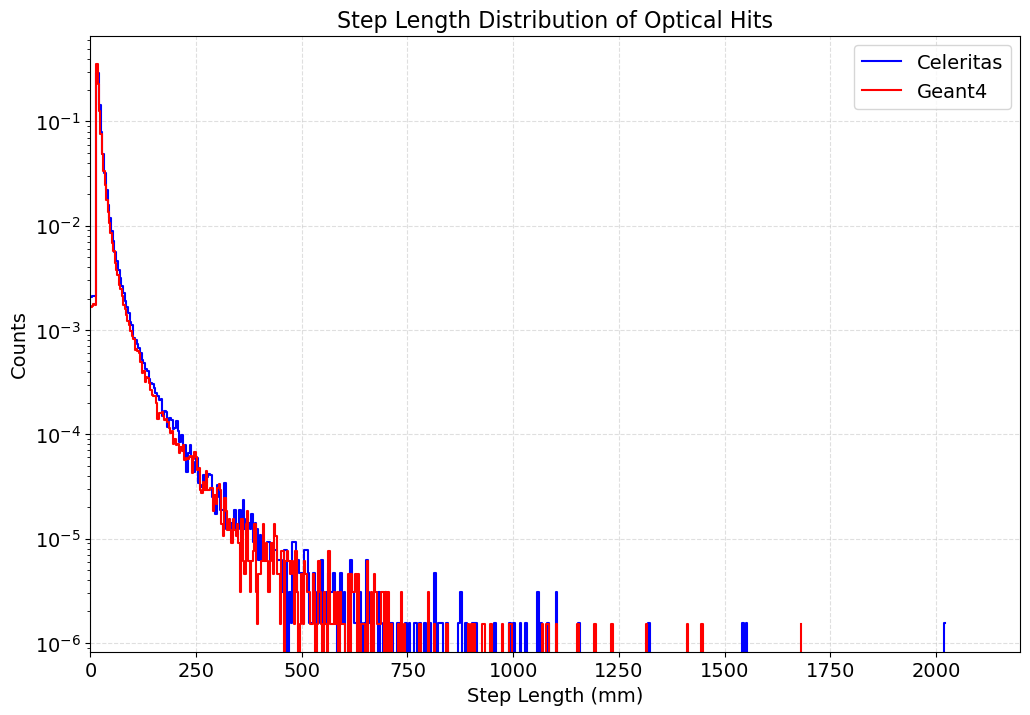

In [203]:
plt.figure(figsize=(12, 8))
plt.step(step_edges_c, step_length_c/celeritas.shape[0], where="mid", label="Celeritas", color="blue")
plt.step(step_edges_g, step_length_g/geant.shape[0], where="mid", label="Geant4", color="red")
plt.yscale("log")
#plt.ylim(1, 1e6)
plt.xlim(0, 2200)
plt.xlabel("Step Length (mm)", fontsize=14)
plt.ylabel("Counts", fontsize=14)
plt.title("Step Length Distribution of Optical Hits", fontsize=16)
plt.grid(linestyle="--", alpha=0.4,  axis="both")
plt.xticks(fontsize=14)
plt.yticks(fontsize=14)
plt.legend(fontsize=14)
plt.show()

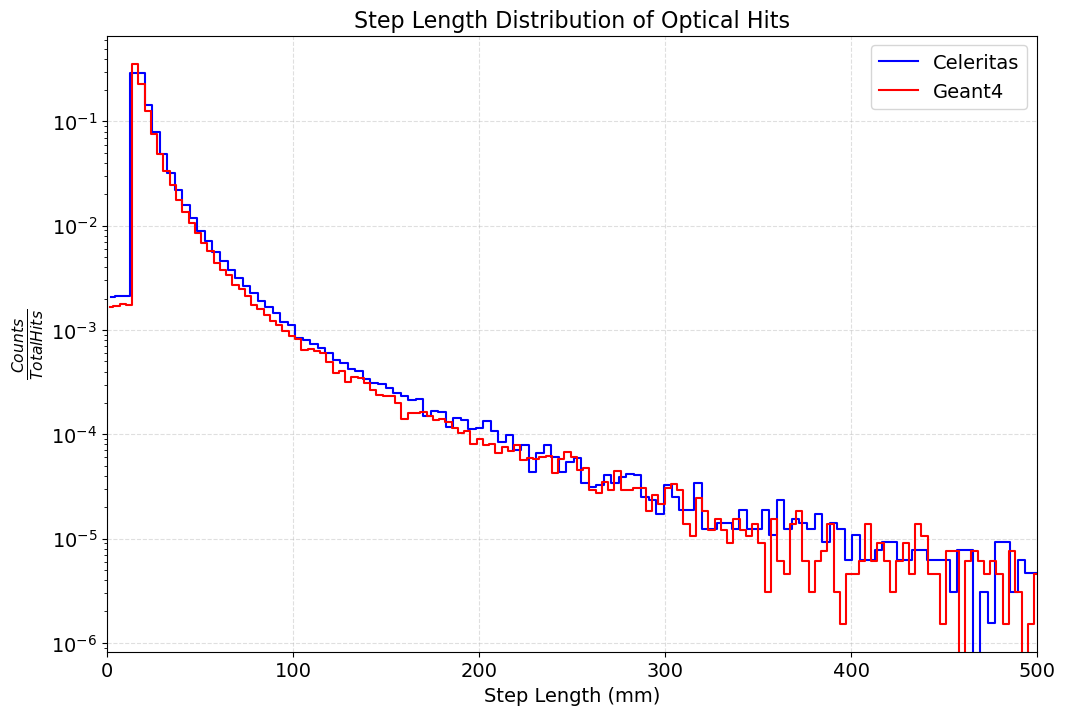

In [229]:
plt.figure(figsize=(12, 8))
plt.step(step_edges_c, step_length_c/celeritas.shape[0], where="mid", label="Celeritas", color="blue")
plt.step(step_edges_g, step_length_g/geant.shape[0], where="mid", label="Geant4", color="red")
plt.yscale("log")
#plt.ylim(1, 1e6)
plt.xlim(0, 500)
plt.xlabel("Step Length (mm)", fontsize=14)
plt.ylabel(r"$\frac{Counts}{Total Hits}$", fontsize=16)
plt.title("Step Length Distribution of Optical Hits", fontsize=16)
plt.grid(linestyle="--", alpha=0.4,  axis="both")
plt.xticks(fontsize=14)
plt.yticks(fontsize=14)
plt.legend(fontsize=14)
plt.show()

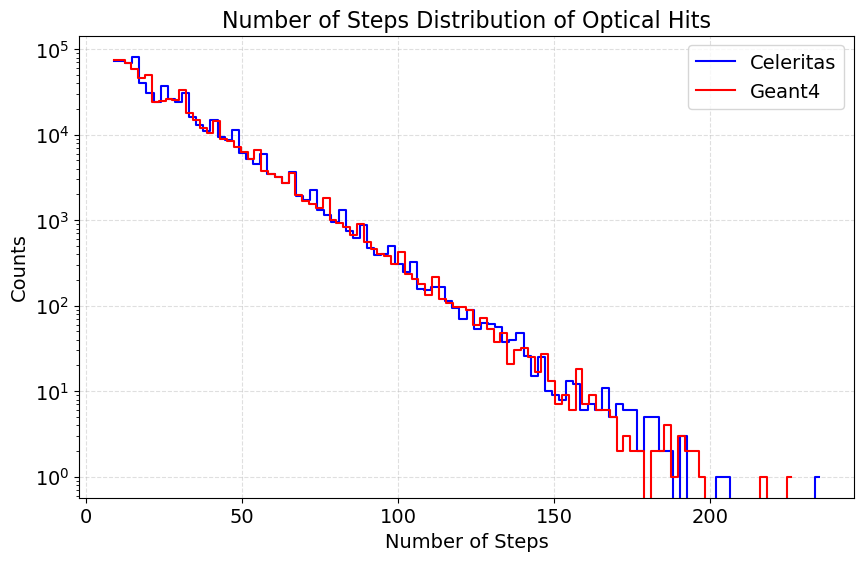

In [234]:
plt.figure(figsize=(10, 6))
plt.step(nstep_edges_c, num_steps_c, where="mid", label="Celeritas", color="blue")
plt.step(nstep_edges_g, num_steps_g, where="mid", label="Geant4", color="red")
plt.yscale("log")
plt.xlabel("Number of Steps", fontsize=14)
plt.ylabel("Counts", fontsize=14)
plt.title("Number of Steps Distribution of Optical Hits", fontsize=16)
plt.grid(linestyle="--", alpha=0.4,  axis="both")
plt.xticks(fontsize=14)
plt.yticks(fontsize=14)
plt.legend(fontsize=14)
plt.show()

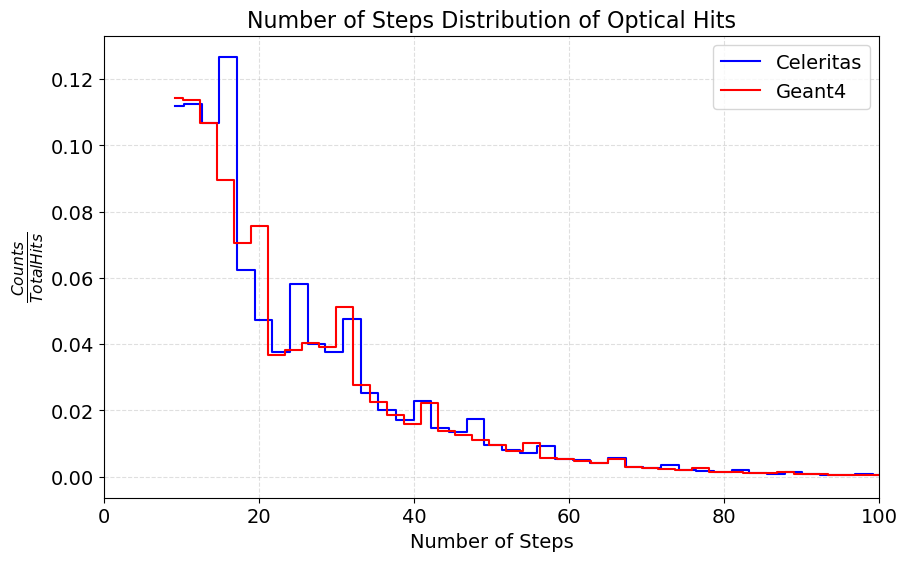

In [235]:
plt.figure(figsize=(10, 6))
plt.step(nstep_edges_c, num_steps_c/celeritas.shape[0], where="mid", label="Celeritas", color="blue")
plt.step(nstep_edges_g, num_steps_g/geant.shape[0], where="mid", label="Geant4", color="red")
#plt.yscale("log")
plt.xlim(0, 100)
plt.xlabel("Number of Steps", fontsize=14)
plt.ylabel(r"$\frac{Counts}{Total Hits}$", fontsize=16)
plt.legend(fontsize=14)
plt.title("Number of Steps Distribution of Optical Hits", fontsize=16)
plt.grid(linestyle="--", alpha=0.4,  axis="both")
plt.xticks(fontsize=14)
plt.yticks(fontsize=14)
plt.show()

### only LAr detector.

In [262]:
file_cele_LAr = uproot.open("/Users/r1i/Desktop/OpticalSims-upstream/build/dune10kt_v5_refactored_1x2x6_e_500MeV_cele.root")

TREE_NAME_cele = "CeleritasHits;1"
BRANCHES = ["x", "y","z","t","wavelength", "pathLength", "numSteps"]
celeritas = file_cele_LAr[TREE_NAME_cele].arrays(BRANCHES, library="pd")

In [ ]:
celeritas.shape

In [303]:
# dump celeritas df to jsonl file
celeritas.to_json("./celeritas_hits.jsonl", orient="records", lines=True)

In [261]:
file_g4_LAr = uproot.open("/Users/r1i/Desktop/OpticalSims-upstream/build/dune10kt_v5_refactored_1x2x6_e_500MeV_g4_remove_coulombscattering.root")

TREE_NAME_cele = "Geant4Hits;1"
BRANCHES = ["x", "y","z","t","wavelength",  "numSteps"]
geant = file_g4_LAr[TREE_NAME_cele].arrays(BRANCHES, library="pd")

In [248]:
geant["x"]

Series([], Name: x, dtype: float64)

In [263]:
celeritas["t"]=celeritas["t"] * 1e9 # convert from seconds to nanoseconds

In [290]:
time_LAr_c, time_edges_c = histogram_distribution(celeritas, "t", bins=50)
time_LAr_g, time_edges_g = histogram_distribution(geant, "t", bins=50)

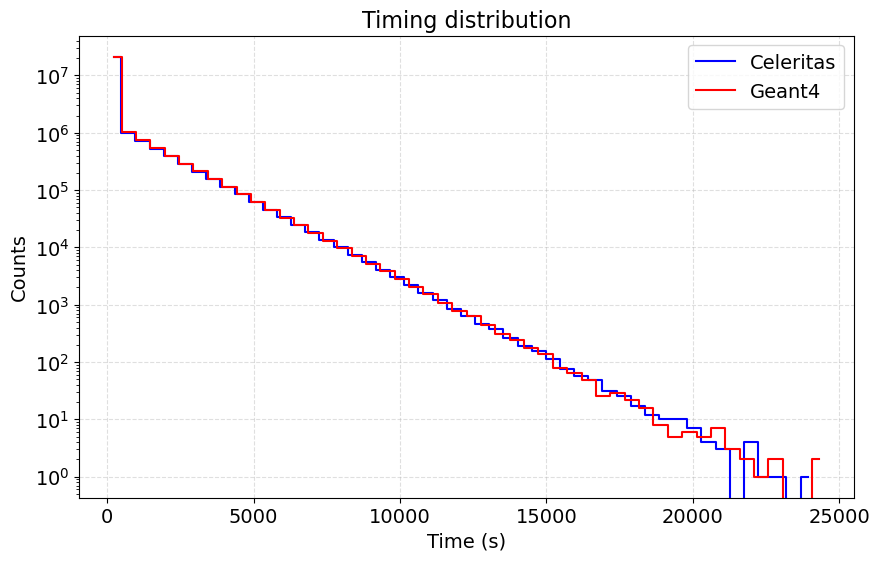

In [291]:
plt.figure(figsize=(10, 6))
plt.step(time_edges_c, time_LAr_c, where="mid", label="Celeritas", color="blue")
plt.step(time_edges_g, time_LAr_g, where="mid", label="Geant4", color="red")
plt.yscale("log")
plt.xlabel("Time (s)", fontsize=14)
plt.ylabel("Counts", fontsize=14)
plt.title("Timing distribution", fontsize=16)
plt.grid(linestyle="--", alpha=0.4,  axis="both")
plt.xticks(fontsize=14)
plt.yticks(fontsize=14)
plt.legend(fontsize=14)
plt.show()

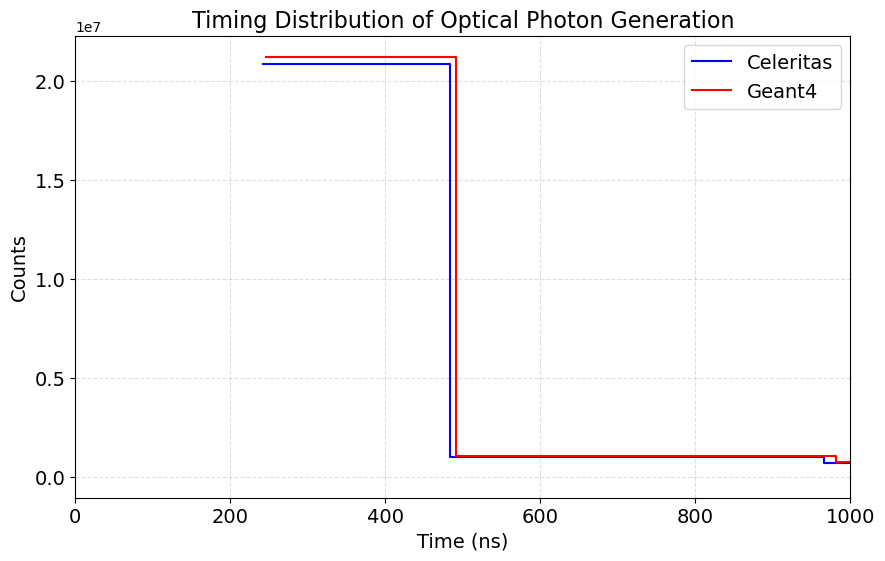

In [292]:
plt.figure(figsize=(10, 6))
plt.step(time_edges_c, time_LAr_c, where="mid", label="Celeritas", color="blue")
plt.step(time_edges_g, time_LAr_g, where="mid", label="Geant4", color="red")
#plt.yscale("log")
plt.xlim(0, 1000)
plt.xlabel("Time (ns)", fontsize=14)
plt.ylabel("Counts", fontsize=14)
plt.title("Timing Distribution of Optical Photon Generation", fontsize=16)
plt.grid(linestyle="--", alpha=0.4,  axis="both")
plt.xticks(fontsize=14)
plt.yticks(fontsize=14)
plt.legend(fontsize=14)
plt.show()

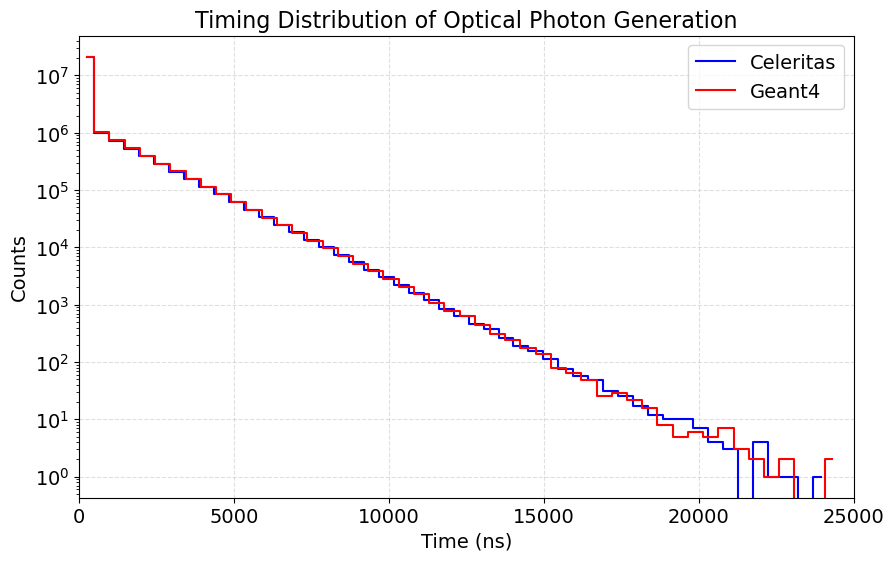

In [293]:
plt.figure(figsize=(10, 6))
plt.step(time_edges_c, time_LAr_c, where="mid", label="Celeritas", color="blue")
plt.step(time_edges_g, time_LAr_g, where="mid", label="Geant4", color="red")
plt.yscale("log")
plt.xlim(0, 25000)
plt.xlabel("Time (ns)", fontsize=14)
plt.ylabel("Counts", fontsize=14)
plt.title("Timing Distribution of Optical Photon Generation", fontsize=16)
plt.grid(linestyle="--", alpha=0.4,  axis="both")
plt.xticks(fontsize=14)
plt.yticks(fontsize=14)
plt.legend(fontsize=14)
plt.show()

In [294]:
celeritas.shape[0]

24538762

In [295]:
geant.shape[0]

25003492

In [296]:
(celeritas.shape[0]/geant.shape[0])-1

-0.018586603823178005

/var/folders/5l/8wq0wlqx6mzb26dfrnrf56t80000gp/T/ipykernel_15655/3333140951.py:30: RuntimeWarning: divide by zero encountered in divide
  ratio = (time_LAr_c / time_LAr_g) - 1
/var/folders/5l/8wq0wlqx6mzb26dfrnrf56t80000gp/T/ipykernel_15655/3333140951.py:30: RuntimeWarning: invalid value encountered in divide
  ratio = (time_LAr_c / time_LAr_g) - 1


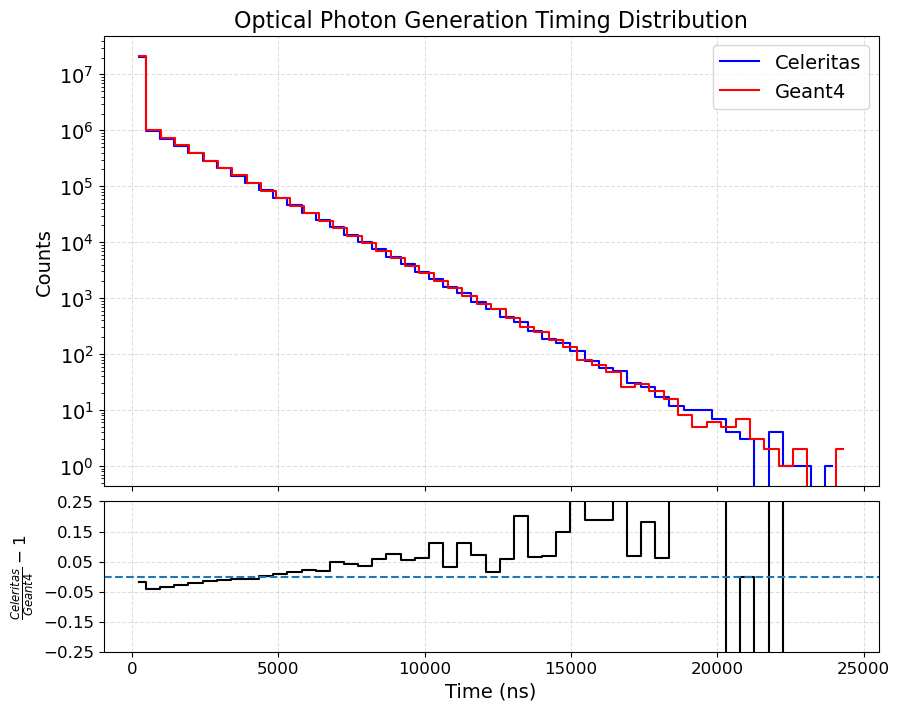

In [302]:
import numpy as np
import matplotlib.pyplot as plt

fig, (ax, ax_res) = plt.subplots(
    2, 1,
    figsize=(10, 8),
    sharex=True,
    gridspec_kw={"height_ratios": [3, 1], "hspace": 0.05},
)

# Main plot
ax.step(time_edges_c, time_LAr_c, where="mid",
        label="Celeritas", color="blue")
ax.step(time_edges_g, time_LAr_g, where="mid",
        label="Geant4", color="red")

ax.set_yscale("log")
ax.set_ylabel("Counts", fontsize=14)
ax.set_title("Optical Photon Generation Timing Distribution", fontsize=16)
ax.grid(linestyle="--", alpha=0.4)
ax.legend(fontsize=14)

# Residual: C/G - 1
#ratio = np.divide(``
#    time_LAr_c,
#    time_LAr_g,
#    out=np.full_like(time_LAr_c, np.nan, dtype=float),
#    where=np.asarray(time_LAr_g) > 0,
#) - 1
ratio = (time_LAr_c / time_LAr_g) - 1
ax_res.step(time_edges_c, ratio, where="mid", color="black")
ax_res.axhline(0, linestyle="--")

ax_res.set_xlabel("Time (ns)", fontsize=14)
ax_res.set_ylabel(r"$\frac{Celeritas}{Geant4} - 1$", fontsize=12)
ax_res.grid(linestyle="--", alpha=0.4)
ax_res.set_ylim(-0.25, 0.25)  # ±25%
ax_res.set_yticks(np.arange(-0.25, 0.3, 0.1))
ax.tick_params(labelsize=14)
ax_res.tick_params(labelsize=12)

plt.show()

/var/folders/5l/8wq0wlqx6mzb26dfrnrf56t80000gp/T/ipykernel_15655/3829651132.py:30: RuntimeWarning: divide by zero encountered in divide
  ratio = (time_LAr_c / celeritas.shape[0]) / (time_LAr_g / geant.shape[0]) - 1
/var/folders/5l/8wq0wlqx6mzb26dfrnrf56t80000gp/T/ipykernel_15655/3829651132.py:30: RuntimeWarning: invalid value encountered in divide
  ratio = (time_LAr_c / celeritas.shape[0]) / (time_LAr_g / geant.shape[0]) - 1


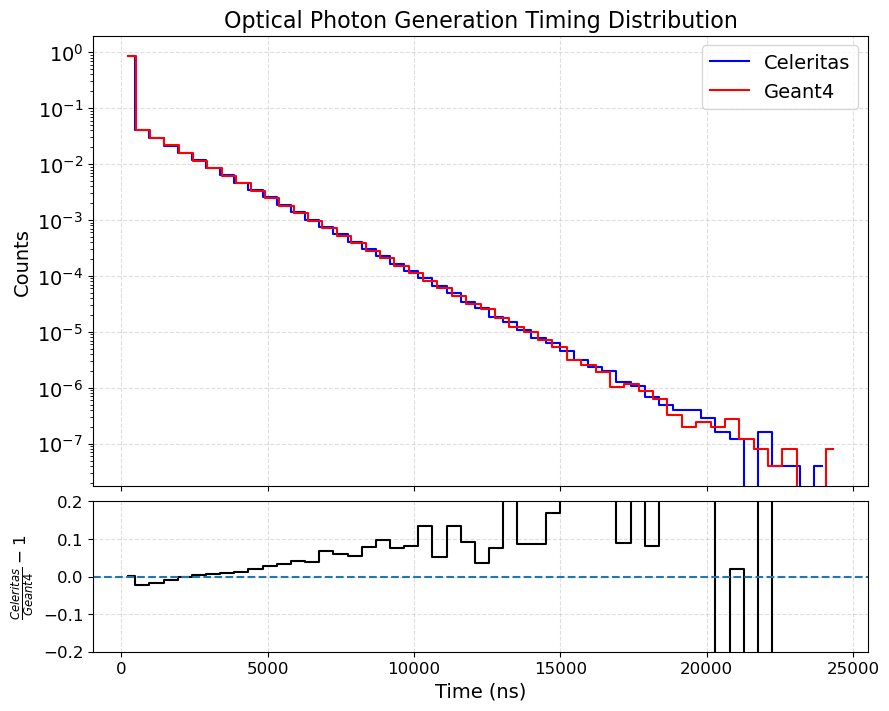

In [298]:
import numpy as np
import matplotlib.pyplot as plt

fig, (ax, ax_res) = plt.subplots(
    2, 1,
    figsize=(10, 8),
    sharex=True,
    gridspec_kw={"height_ratios": [3, 1], "hspace": 0.05},
)

# Main plot
ax.step(time_edges_c, time_LAr_c/celeritas.shape[0], where="mid",
        label="Celeritas", color="blue")
ax.step(time_edges_g, time_LAr_g/geant.shape[0], where="mid",
        label="Geant4", color="red")

ax.set_yscale("log")
ax.set_ylabel("Counts", fontsize=14)
ax.set_title("Optical Photon Generation Timing Distribution", fontsize=16)
ax.grid(linestyle="--", alpha=0.4)
ax.legend(fontsize=14)

# Residual: C/G - 1
#ratio = np.divide(
#    time_LAr_c,
#    time_LAr_g,
#    out=np.full_like(time_LAr_c, np.nan, dtype=float),
#    where=np.asarray(time_LAr_g) > 0,
#) - 1
ratio = (time_LAr_c / celeritas.shape[0]) / (time_LAr_g / geant.shape[0]) - 1
ax_res.step(time_edges_c, ratio, where="mid", color="black")
ax_res.axhline(0, linestyle="--")

ax_res.set_xlabel("Time (ns)", fontsize=14)
ax_res.set_ylabel(r"$\frac{Celeritas}{Geant4} - 1$", fontsize=12)
ax_res.grid(linestyle="--", alpha=0.4)
ax_res.set_ylim(-0.20, 0.20)  # ±10%
ax.tick_params(labelsize=14)
ax_res.tick_params(labelsize=12)

plt.show()

### All volumes are sensitive and coulomb scattering is removed. 

In [317]:
file_cele_all_vol = uproot.open("/Users/r1i/Desktop/OpticalSims-upstream/cele-root-files/dune10kt_v5_refactored_1x2x6_e_500MeV_cele_remove_coulombscattering.root")

TREE_NAME_cele = "CeleritasHits;1"
BRANCHES = ["x", "y","z","t","wavelength", "pathLength", "numSteps"]
celeritas_all_vol = file_cele_all_vol[TREE_NAME_cele].arrays(BRANCHES, library="pd")
celeritas_all_vol["t"] = celeritas_all_vol["t"] * 1e9 # convert from seconds to nanoseconds
file_g4_all_vol = uproot.open("/Users/r1i/Desktop/OpticalSims-upstream/build/dune10kt_v5_refactored_1x2x6_e_500MeV_g4_remove_coulombscattering.root")

TREE_NAME_g4 = "Geant4Hits;1"
BRANCHES = ["x", "y","z","t","wavelength",  "numSteps"]
geant_all_vol = file_g4_all_vol[TREE_NAME_g4].arrays(BRANCHES, library="pd")

In [318]:
counts_time_c_all, time_edges_c_all = histogram_distribution(celeritas_all_vol, "t", bins=250)
counts_time_g_all, time_edges_g_all = histogram_distribution(geant_all_vol, "t", bins=250)

/var/folders/5l/8wq0wlqx6mzb26dfrnrf56t80000gp/T/ipykernel_15655/1508632268.py:30: RuntimeWarning: divide by zero encountered in divide
  ratio = (counts_time_c_all  / counts_time_g_all ) - 1
/var/folders/5l/8wq0wlqx6mzb26dfrnrf56t80000gp/T/ipykernel_15655/1508632268.py:30: RuntimeWarning: invalid value encountered in divide
  ratio = (counts_time_c_all  / counts_time_g_all ) - 1


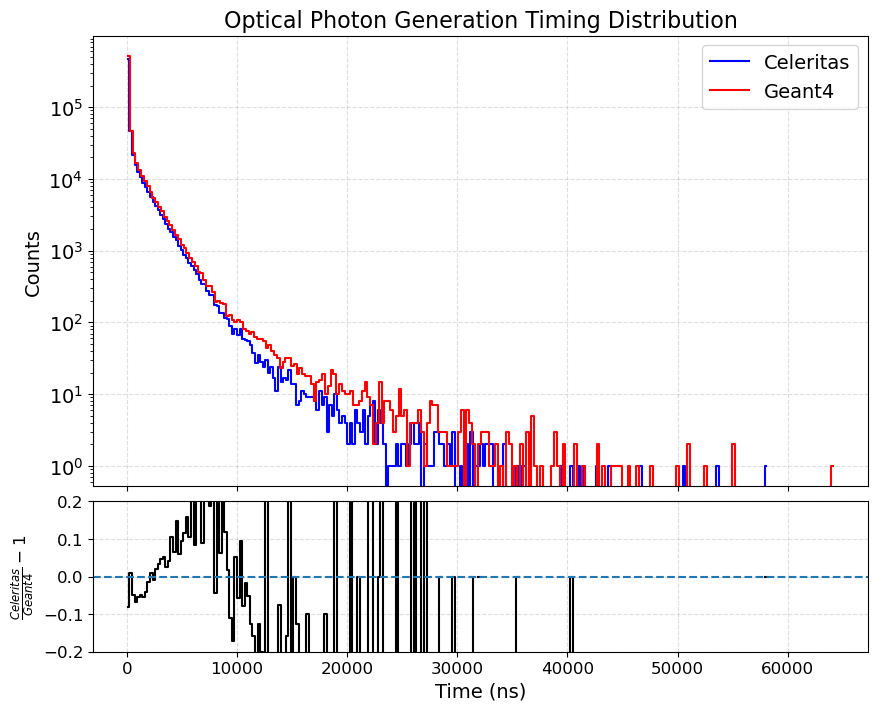

In [319]:
import numpy as np
import matplotlib.pyplot as plt

fig, (ax, ax_res) = plt.subplots(
    2, 1,
    figsize=(10, 8),
    sharex=True,
    gridspec_kw={"height_ratios": [3, 1], "hspace": 0.05},
)

# Main plot
ax.step(time_edges_c_all, counts_time_c_all, where="mid",
        label="Celeritas", color="blue")
ax.step(time_edges_g_all, counts_time_g_all, where="mid",
        label="Geant4", color="red")

ax.set_yscale("log")
ax.set_ylabel("Counts", fontsize=14)
ax.set_title("Optical Photon Generation Timing Distribution", fontsize=16)
ax.grid(linestyle="--", alpha=0.4)
ax.legend(fontsize=14)

# Residual: C/G - 1
#ratio = np.divide(
#    time_LAr_c,
#    time_LAr_g,
#    out=np.full_like(time_LAr_c, np.nan, dtype=float),
#    where=np.asarray(time_LAr_g) > 0,
#) - 1
ratio = (counts_time_c_all  / counts_time_g_all ) - 1
ax_res.step(time_edges_c_all, ratio, where="mid", color="black")
ax_res.axhline(0, linestyle="--")

ax_res.set_xlabel("Time (ns)", fontsize=14)
ax_res.set_ylabel(r"$\frac{Celeritas}{Geant4} - 1$", fontsize=12)
ax_res.grid(linestyle="--", alpha=0.4)
ax_res.set_ylim(-0.20, 0.20)  # ±10%
ax.tick_params(labelsize=14)
ax_res.tick_params(labelsize=12)

plt.show()

### optical track offloading to celeritas
June 19

In [4]:
file_cele_opt_track_off = uproot.open("/Users/r1i/Desktop/OpticalSims-upstream/build/dune10kt_v5_refactored_1x2x6_e_500MeV_cele_optical_track_offload.root")

TREE_NAME_cele = "CeleritasHits;1"
BRANCHES = ["x", "y","z","t","wavelength", "pathLength", "numSteps"]
celeritas_opt_track_off = file_cele_opt_track_off[TREE_NAME_cele].arrays(BRANCHES, library="pd")
celeritas_opt_track_off["t"] = celeritas_opt_track_off["t"] * 1e9 # convert from seconds to nanoseconds

file_g4 = uproot.open("/Users/r1i/Desktop/OpticalSims-upstream/build/dune10kt_v5_refactored_1x2x6_e_500MeV_g4.root")

TREE_NAME_g4 = "Geant4Hits;1"
BRANCHES = ["x", "y","z","t","wavelength",  "numSteps"]
geant = file_g4[TREE_NAME_g4].arrays(BRANCHES, library="pd")

In [6]:
counts_time_c_opt_track, time_edges_c_opt_track = histogram_distribution(celeritas_opt_track_off, "t", bins=250)
counts_time_g_opt_track, time_edges_g_opt_track = histogram_distribution(geant, "t", bins=250)

In [10]:
num_steps_c_opt_track, nstep_edges_c_opt_track = histogram_distribution(celeritas_opt_track_off, "numSteps", bins=100)
num_steps_g_opt_track, nstep_edges_g_opt_track = histogram_distribution(geant, "numSteps", bins=100)

/var/folders/5l/8wq0wlqx6mzb26dfrnrf56t80000gp/T/ipykernel_13278/1374384034.py:30: RuntimeWarning: divide by zero encountered in divide
  ratio = (counts_time_c_opt_track  / counts_time_g_opt_track ) - 1
/var/folders/5l/8wq0wlqx6mzb26dfrnrf56t80000gp/T/ipykernel_13278/1374384034.py:30: RuntimeWarning: invalid value encountered in divide
  ratio = (counts_time_c_opt_track  / counts_time_g_opt_track ) - 1


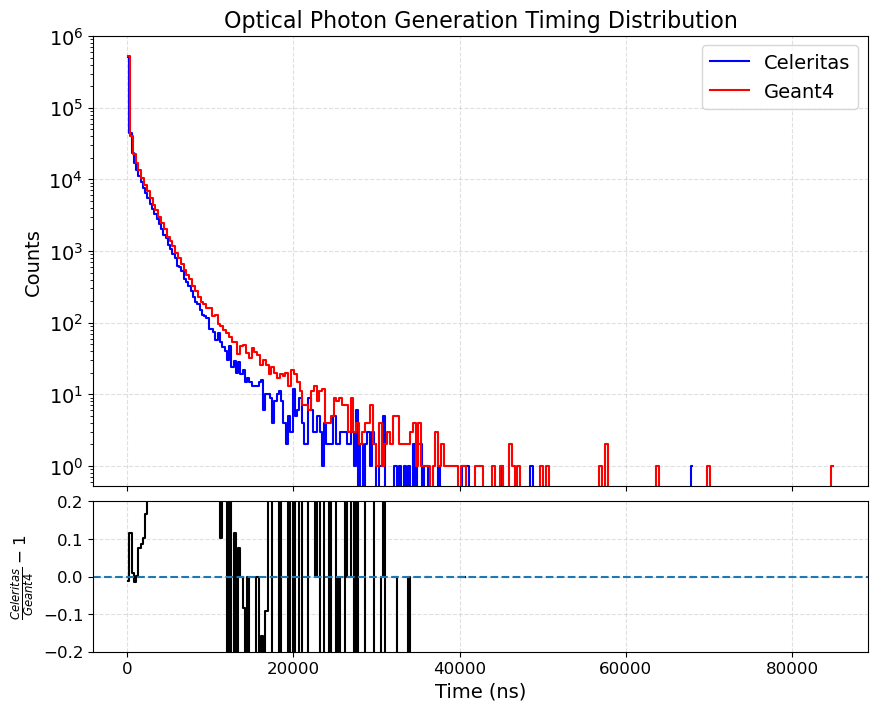

In [7]:
import numpy as np
import matplotlib.pyplot as plt

fig, (ax, ax_res) = plt.subplots(
    2, 1,
    figsize=(10, 8),
    sharex=True,
    gridspec_kw={"height_ratios": [3, 1], "hspace": 0.05},
)

# Main plot
ax.step(time_edges_c_opt_track, counts_time_c_opt_track, where="mid",
        label="Celeritas", color="blue")
ax.step(time_edges_g_opt_track, counts_time_g_opt_track, where="mid",
        label="Geant4", color="red")

ax.set_yscale("log")
ax.set_ylabel("Counts", fontsize=14)
ax.set_title("Optical Photon Generation Timing Distribution", fontsize=16)
ax.grid(linestyle="--", alpha=0.4)
ax.legend(fontsize=14)

# Residual: C/G - 1
#ratio = np.divide(
#    time_LAr_c,
#    time_LAr_g,
#    out=np.full_like(time_LAr_c, np.nan, dtype=float),
#    where=np.asarray(time_LAr_g) > 0,
#) - 1
ratio = (counts_time_c_opt_track  / counts_time_g_opt_track ) - 1
ax_res.step(time_edges_c_opt_track, ratio, where="mid", color="black")
ax_res.axhline(0, linestyle="--")

ax_res.set_xlabel("Time (ns)", fontsize=14)
ax_res.set_ylabel(r"$\frac{Celeritas}{Geant4} - 1$", fontsize=12)
ax_res.grid(linestyle="--", alpha=0.4)
ax_res.set_ylim(-0.20, 0.20)  # ±10%
ax.tick_params(labelsize=14)
ax_res.tick_params(labelsize=12)

plt.show()

Let us look at timing information for nstep =1 


In [14]:
celeritas_opt_track_off.numSteps.value_counts()

numSteps
11     40021
12     39696
13     38085
10     36923
14     34947
       ...  
178        1
183        1
168        1
179        1
195        1
Name: count, Length: 181, dtype: int64

In [15]:
celeritas_opt_track_off[celeritas_opt_track_off["numSteps"]==1]

,x,y,z,t,wavelength,pathLength,numSteps


/var/folders/5l/8wq0wlqx6mzb26dfrnrf56t80000gp/T/ipykernel_13278/2909574533.py:23: RuntimeWarning: divide by zero encountered in divide
  ratio = (num_steps_c_opt_track  / num_steps_g_opt_track ) - 1
/var/folders/5l/8wq0wlqx6mzb26dfrnrf56t80000gp/T/ipykernel_13278/2909574533.py:23: RuntimeWarning: invalid value encountered in divide
  ratio = (num_steps_c_opt_track  / num_steps_g_opt_track ) - 1


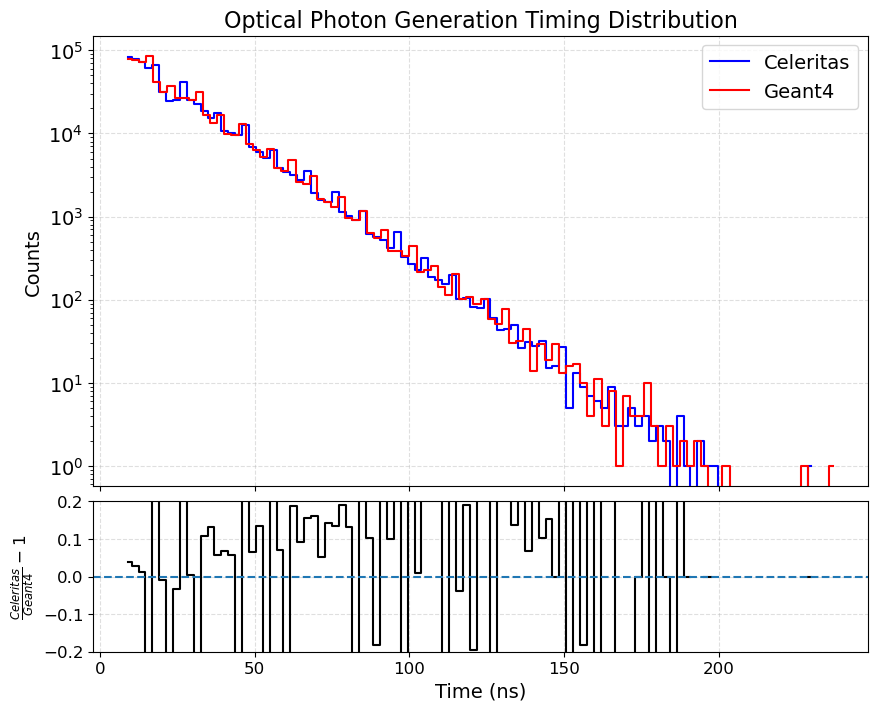

In [12]:
import numpy as np
import matplotlib.pyplot as plt

fig, (ax, ax_res) = plt.subplots(
    2, 1,
    figsize=(10, 8),
    sharex=True,
    gridspec_kw={"height_ratios": [3, 1], "hspace": 0.05},
)

# Main plot
ax.step(nstep_edges_c_opt_track, num_steps_c_opt_track, where="mid",
        label="Celeritas", color="blue")
ax.step(nstep_edges_g_opt_track, num_steps_g_opt_track, where="mid",
        label="Geant4", color="red")

ax.set_yscale("log")
ax.set_ylabel("Counts", fontsize=14)
ax.set_title("Optical Photon Generation Timing Distribution", fontsize=16)
ax.grid(linestyle="--", alpha=0.4)
ax.legend(fontsize=14)

ratio = (num_steps_c_opt_track  / num_steps_g_opt_track ) - 1
ax_res.step(nstep_edges_c_opt_track, ratio, where="mid", color="black")
ax_res.axhline(0, linestyle="--")

ax_res.set_xlabel("Time (ns)", fontsize=14)
ax_res.set_ylabel(r"$\frac{Celeritas}{Geant4} - 1$", fontsize=12)
ax_res.grid(linestyle="--", alpha=0.4)
ax_res.set_ylim(-0.20, 0.20)  # ±10%
ax.tick_params(labelsize=14)
ax_res.tick_params(labelsize=12)

plt.show()

Number of steps and the timing distribution does not make sense. Perhaps how the sensitive detector is set up might be creating issue.
Check if reflection ever gets triggered.
```
offload optical_track
Set LAr as SD
Set the Arapauca Hits only for


In [5]:
file_cele_LAr = uproot.open("/Users/r1i/Desktop/OpticalSims-upstream/build/dune10kt_v5_refactored_1x2x6_e_500MeV_cele_optical_offload_LAr_only.root")

TREE_NAME_cele = "CeleritasHits;1"
BRANCHES = ["x", "y","z","t","wavelength", "pathLength", "numSteps"]
celeritas_LAr = file_cele_LAr[TREE_NAME_cele].arrays(BRANCHES, library="pd")
celeritas_LAr["t"] = celeritas_LAr["t"] * 1e9 # convert from seconds to nanoseconds
celeritas_LAr["pathLength"] =celeritas_LAr["pathLength"] * 10 # convert from cm to mm
file_g4_LAr = uproot.open("/Users/r1i/Desktop/OpticalSims-upstream/build/dune10kt_v5_refactored_1x2x6_e_500MeV_g4_optical_offload_LAr_only.root")

TREE_NAME_g4 = "Geant4Hits;1"
BRANCHES = ["x", "y","z","t","wavelength","stepLength", "numSteps"]
geant_LAr = file_g4_LAr[TREE_NAME_g4].arrays(BRANCHES, library="pd")

In [8]:
time_LAr_c, time_edges_c = histogram_distribution(celeritas_LAr, "t", bins=100)
time_LAr_g, time_edges_g = histogram_distribution(geant_LAr, "t", bins=100)

/var/folders/5l/8wq0wlqx6mzb26dfrnrf56t80000gp/T/ipykernel_48690/2361439087.py:24: RuntimeWarning: divide by zero encountered in divide
  ratio = (time_LAr_c  / time_LAr_g ) - 1
/var/folders/5l/8wq0wlqx6mzb26dfrnrf56t80000gp/T/ipykernel_48690/2361439087.py:24: RuntimeWarning: invalid value encountered in divide
  ratio = (time_LAr_c  / time_LAr_g ) - 1


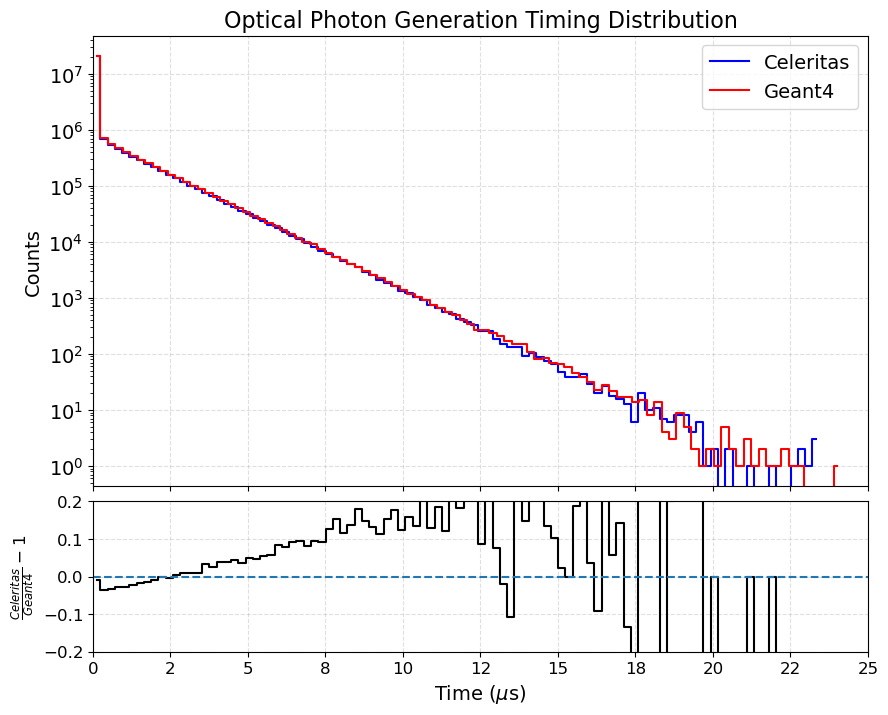

In [9]:
import numpy as np
import matplotlib.pyplot as plt

from matplotlib.ticker import FuncFormatter
fig, (ax, ax_res) = plt.subplots(
    2, 1,
    figsize=(10, 8),
    sharex=True,
    gridspec_kw={"height_ratios": [3, 1], "hspace": 0.05},
)

# Main plot
ax.step(time_edges_c, time_LAr_c, where="mid",
        label="Celeritas", color="blue")
ax.step(time_edges_g, time_LAr_g, where="mid",
        label="Geant4", color="red")

ax.set_yscale("log")
ax.set_ylabel("Counts", fontsize=14)
ax.set_title("Optical Photon Generation Timing Distribution", fontsize=16)
ax.grid(linestyle="--", alpha=0.4)
ax.legend(fontsize=14)
ax.set_xlim(0, 25000)
ratio = (time_LAr_c  / time_LAr_g ) - 1
ax_res.step(time_edges_c, ratio, where="mid", color="black")
ax_res.axhline(0, linestyle="--")

ax_res.set_xlabel(r"Time ($\mu$s)", fontsize=14)
ax_res.set_ylabel(r"$\frac{Celeritas}{Geant4} - 1$", fontsize=12)
ax_res.grid(linestyle="--", alpha=0.4)
ax_res.set_ylim(-0.20, 0.20)  # ±10%
ax.tick_params(labelsize=14)
ax_res.tick_params(labelsize=12)
ax.xaxis.set_major_formatter(
    FuncFormatter(lambda x, pos: f"{x/1000:.0f}"))
ax.set_xticks(np.arange(0, 25001, 2500))
plt.show()

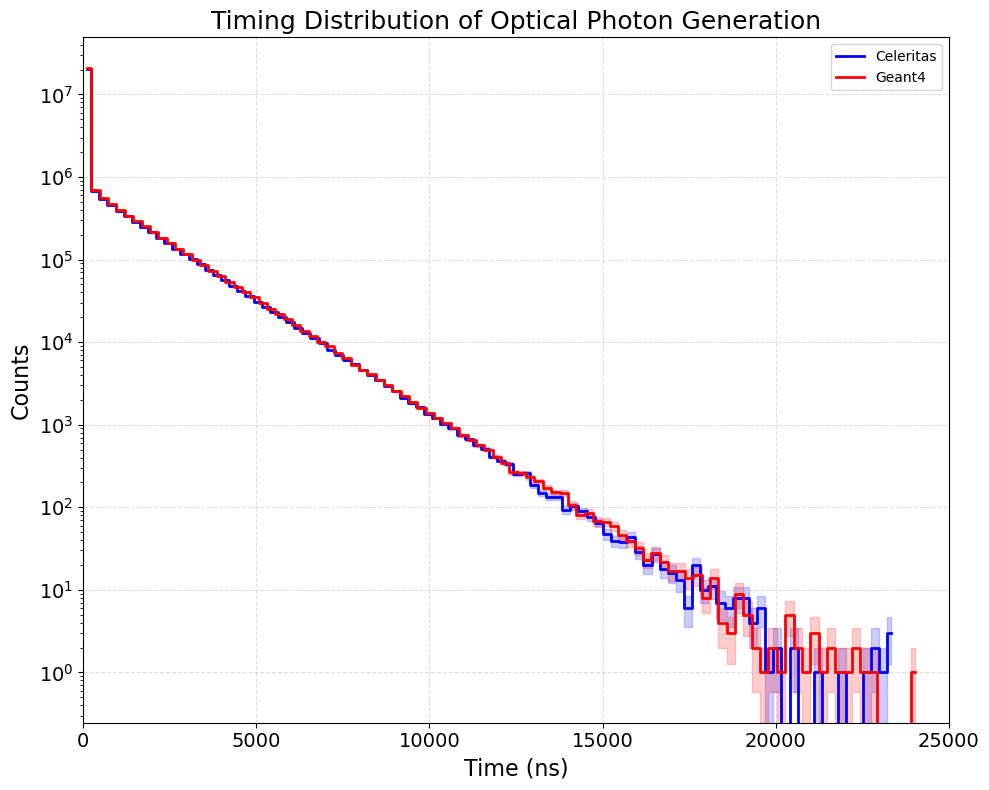

In [11]:
#add error bars to the time distribution plot by taking square root of the counts in each bin as the error
time_c_err = np.sqrt(time_LAr_c)
time_g_err = np.sqrt(time_LAr_g)
#plot the time distribution with error bars as shaded area around the step plot
plt.figure(figsize=(10, 8))
plt.step(
    time_edges_c,
    time_LAr_c,
    where="mid",
    color="blue",
    linewidth=2,
    label="Celeritas"
)

plt.fill_between(
    time_edges_c,
    time_LAr_c - time_c_err,  # avoid negative values on log scale
    time_LAr_c + time_c_err,
    step="mid",
    color="blue",
    alpha=0.2
)

# Geant4
plt.step(
    time_edges_g,
    time_LAr_g,
    where="mid",
    color="red",
    linewidth=2,
    label="Geant4"
)

plt.fill_between(
    time_edges_g,
    time_LAr_g - time_g_err,  # avoid negative values on log scale
    time_LAr_g + time_g_err,
    step="mid",
    color="red",
    alpha=0.2
)   

plt.xlabel("Time (ns)", fontsize=16)
plt.ylabel("Counts", fontsize=16)
plt.title("Timing Distribution of Optical Photon Generation", fontsize=18)

plt.grid(linestyle="--", alpha=0.4)
plt.yscale("log")
plt.xlim(0, 25000)
plt.xticks(fontsize=14)
plt.yticks(fontsize=14)
plt.legend()
plt.tight_layout()
plt.show()

In [12]:
stepslength_c, length_edges_c = histogram_distribution(celeritas_LAr, "pathLength", bins=100)
stepslength_g, length_edges_g = histogram_distribution(geant_LAr, "stepLength", bins=100)

/var/folders/5l/8wq0wlqx6mzb26dfrnrf56t80000gp/T/ipykernel_48690/1585253354.py:23: RuntimeWarning: divide by zero encountered in divide
  ratio = (stepslength_c  / stepslength_g ) - 1


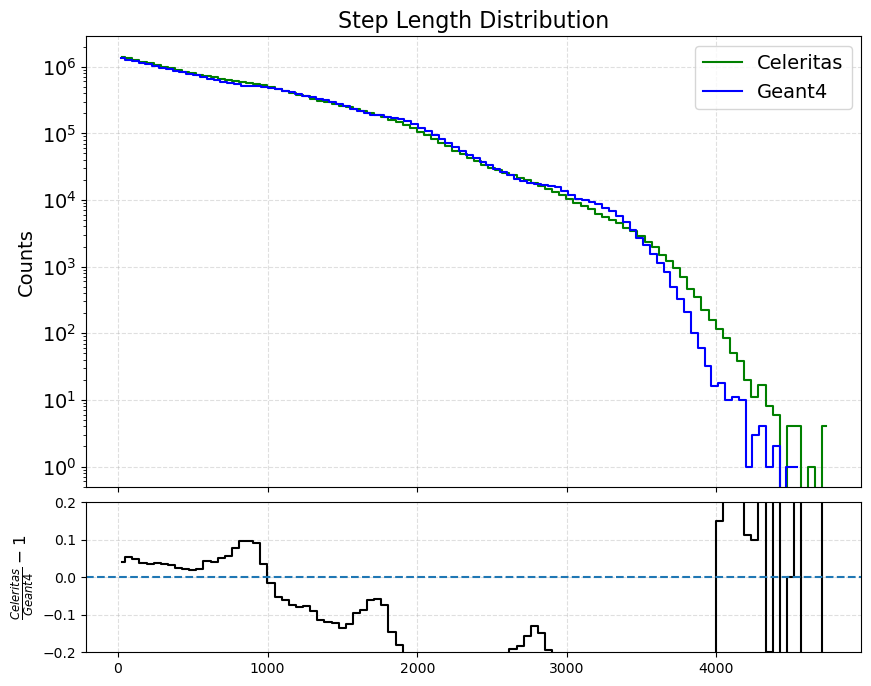

In [13]:
import numpy as np
import matplotlib.pyplot as plt

from matplotlib.ticker import FuncFormatter
fig, (ax, ax_res) = plt.subplots(
    2, 1,
    figsize=(10, 8),
    sharex=True,
    gridspec_kw={"height_ratios": [3, 1], "hspace": 0.05},
)

# Main plot
ax.step(length_edges_c, stepslength_c, where="mid",
        label="Celeritas", color="green")
ax.step(length_edges_g, stepslength_g, where="mid",
        label="Geant4", color="blue")

ax.set_yscale("log")
ax.set_ylabel("Counts", fontsize=14)
ax.set_title("Step Length Distribution", fontsize=16)
ax.grid(linestyle="--", alpha=0.4)
ax.legend(fontsize=14)
ratio = (stepslength_c  / stepslength_g ) - 1
ax_res.step(length_edges_c, ratio, where="mid", color="black")
ax_res.axhline(0, linestyle="--")

ax_res.set_ylabel(r"$\frac{Celeritas}{Geant4} - 1$", fontsize=12)
ax_res.grid(linestyle="--", alpha=0.4)
ax_res.set_ylim(-0.20, 0.20)  # ±10%
ax.tick_params(labelsize=14)
plt.show()

In [15]:
num_steps_c, nstep_edges_c = histogram_distribution(celeritas_LAr, "numSteps", bins=100)
num_steps_g, nstep_edges_g = histogram_distribution(geant_LAr, "numSteps", bins=100)

/var/folders/5l/8wq0wlqx6mzb26dfrnrf56t80000gp/T/ipykernel_48690/2108882334.py:23: RuntimeWarning: invalid value encountered in divide
  ratio = (num_steps_c  / num_steps_g ) - 1


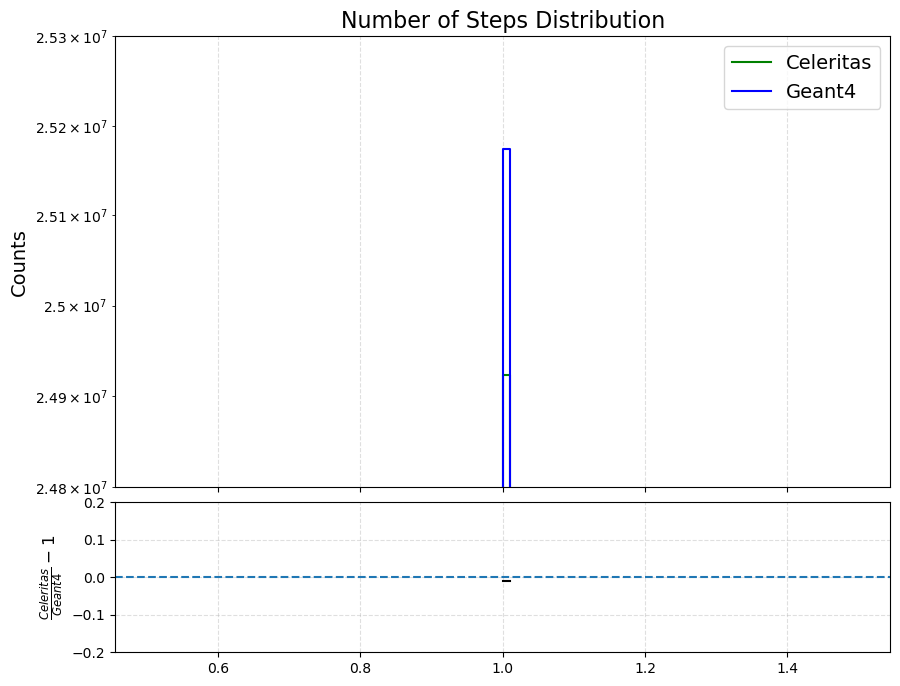

In [18]:
import numpy as np
import matplotlib.pyplot as plt

from matplotlib. ticker import FuncFormatter
fig, (ax, ax_res) = plt.subplots(
    2, 1,
    figsize=(10, 8),
    sharex=True,
    gridspec_kw={"height_ratios": [3, 1], "hspace": 0.05},
)

# Main plot
ax.step(nstep_edges_c, num_steps_c, where="mid",
        label="Celeritas", color="green")
ax.step(nstep_edges_g, num_steps_g, where="mid",
        label="Geant4", color="blue")
ax.set_ylim(2.48e7, 2.53e7)
ax.set_yscale("log")
ax.set_ylabel("Counts", fontsize=14)
ax.set_title("Number of Steps Distribution", fontsize=16)
ax.grid(linestyle="--", alpha=0.4)
ax.legend(fontsize=14)
ratio = (num_steps_c  / num_steps_g ) - 1
ax_res.step(nstep_edges_c, ratio, where="mid", color="black")
ax_res.axhline(0, linestyle="--")

ax_res.set_ylabel(r"$\frac{Celeritas}{Geant4} - 1$", fontsize=12)
ax_res.grid(linestyle="--", alpha=0.4)
ax_res.set_ylim(-0.20, 0.20)  # ±10%
ax.tick_params(labelsize=14)
plt.show()

In [21]:
(2.51-2.49)/2.49

0.008032128514056052

In [21]:
#Load uproot files for celeritas and geant4 and compare the timing distribution of optical hits in the LAr volume only

file_cele_opt_track_off_RINDEX = uproot.open("/Users/r1i/Desktop/OpticalSims-upstream/build/dune10kt_v5_refactored_1x2x6_e_10MeV_cele_optical_offload_LAr_constRIndex.root")

TREE_NAME_cele = "CeleritasHits;1"
BRANCHES = ["x", "y","z","t","wavelength", "pathLength", "numSteps"]
celeritas_opt_track_off_kRINDEX = file_cele_opt_track_off_RINDEX[TREE_NAME_cele].arrays(BRANCHES, library="pd")

celeritas_opt_track_off_kRINDEX["t"] = celeritas_opt_track_off_kRINDEX["t"] * 1e9 # convert from seconds to nanoseconds
celeritas_opt_track_off_kRINDEX["pathLength"] =celeritas_opt_track_off_kRINDEX["pathLength"] * 10 # convert from cm to mm
file_g4_opt_track_off_RINDEX = uproot.open("/Users/r1i/Desktop/OpticalSims-upstream/build/dune10kt_v5_refactored_1x2x6_e_10MeV_g4_optical_offload_LAr_constRIndex.root")

TREE_NAME_g4 = "Geant4Hits;1"
BRANCHES = ["x", "y","z","t","wavelength", "stepLength", "numSteps"]
geant_opt_track_off_RINDEX = file_g4_opt_track_off_RINDEX[TREE_NAME_g4].arrays(BRANCHES, library="pd")

In [22]:
t_count_RINDEX_c, t_edges_RINDEX_c = histogram_distribution(celeritas_opt_track_off_kRINDEX, "t", bins=100)
t_count_RINDEX_g, t_edges_RINDEX_g = histogram_distribution(geant_opt_track_off_RINDEX, "t", bins=100)

In [23]:
t_step_length_RINDEX_c, t_length_edges_RINDEX_c = histogram_distribution(celeritas_opt_track_off_kRINDEX, "pathLength", bins=100)
t_step_length_RINDEX_g, t_length_edges_RINDEX_g = histogram_distribution(geant_opt_track_off_RINDEX, "stepLength", bins=100)

/var/folders/5l/8wq0wlqx6mzb26dfrnrf56t80000gp/T/ipykernel_3532/2267428986.py:27: RuntimeWarning: divide by zero encountered in divide
  ratio = (counts_c / counts_g) - 1
/var/folders/5l/8wq0wlqx6mzb26dfrnrf56t80000gp/T/ipykernel_3532/2267428986.py:27: RuntimeWarning: invalid value encountered in divide
  ratio = (counts_c / counts_g) - 1


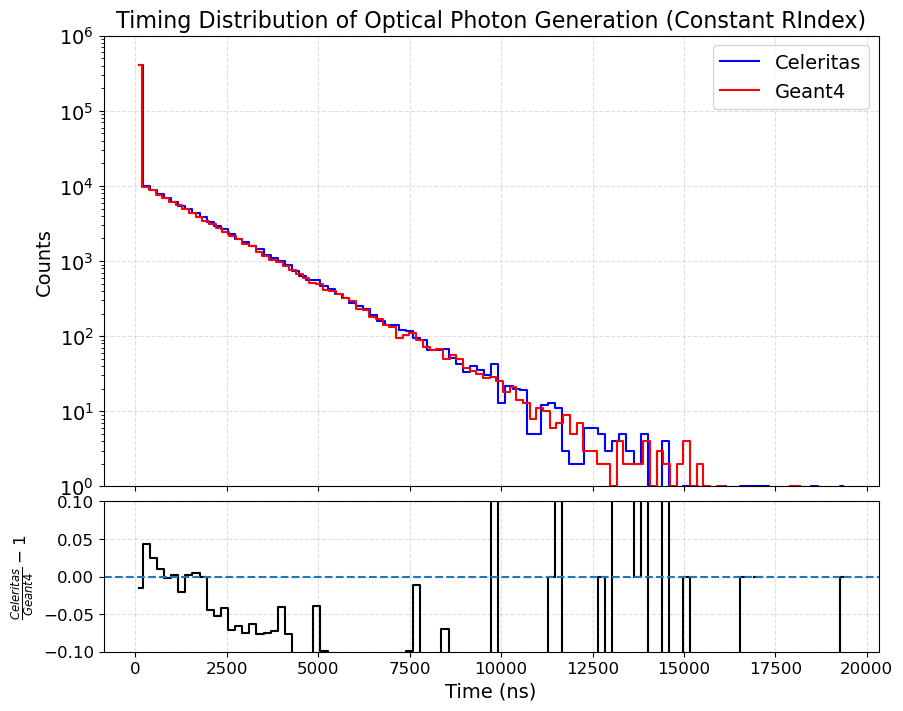

In [25]:
plot_histogram_with_residual(
    t_edges_RINDEX_c,
    t_edges_RINDEX_g,
    t_count_RINDEX_c,
    t_count_RINDEX_g,
    xlabel="Time (ns)",
    ylabel="Counts",
    title="Timing Distribution of Optical Photon Generation (Constant RIndex)",
    ylim_min=1,
    ylim_max=1e6,
    xlim=(0, 25000)
)

/var/folders/5l/8wq0wlqx6mzb26dfrnrf56t80000gp/T/ipykernel_3532/2267428986.py:27: RuntimeWarning: divide by zero encountered in divide
  ratio = (counts_c / counts_g) - 1


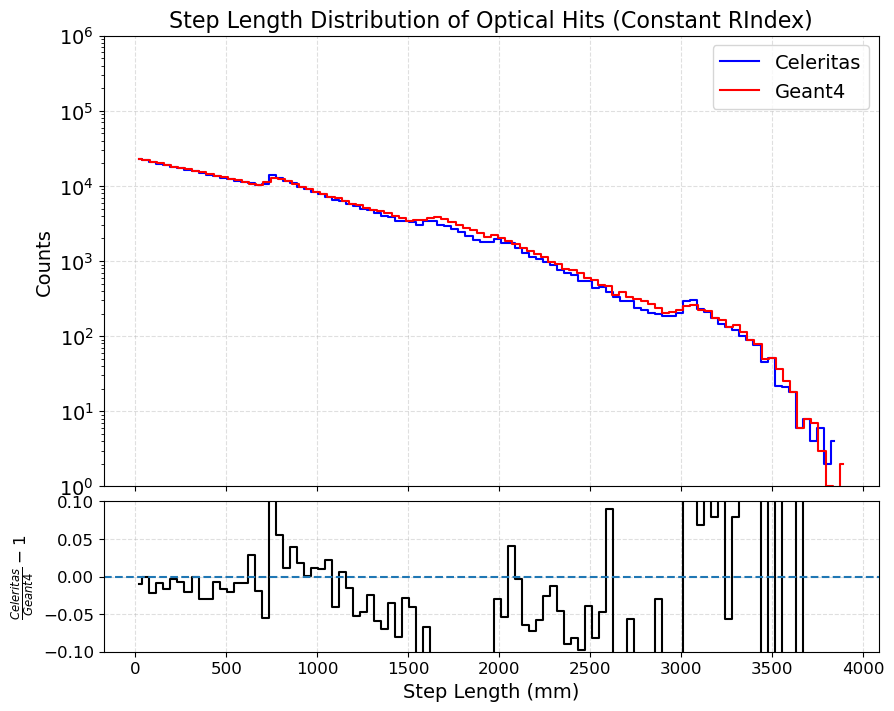

In [26]:
plot_histogram_with_residual(
    t_length_edges_RINDEX_c,
    t_length_edges_RINDEX_g,
    t_step_length_RINDEX_c,
    t_step_length_RINDEX_g,
    xlabel="Step Length (mm)",  
    ylabel="Counts",
    title="Step Length Distribution of Optical Hits (Constant RIndex)",
    ylim_min=1,
    ylim_max=1e6,
    xlim=(0, 2200)
)
    

In [27]:
# bin in logartihmic scale for the step length distribution and time and plot the histogram with residuals
def histogram_log_bins(data, column, num_bins):
    import numpy as np
    import matplotlib.pyplot as plt

    # Create logarithmically spaced bins
    log_bins = np.logspace(np.log10(data[column].min()), np.log10(data[column].max()), num_bins)

    # Compute histogram
    counts, edges = np.histogram(data[column], bins=log_bins)

    return counts, edges

### Optical track offloading and disable all optical physics process.
Except absorption and boundary.

In [47]:
celeritas_opt_track_phys_process = load_celeritas("/Users/r1i/Desktop/OpticalSims-upstream/build/dune10kt_v5_refactored_1x2x6_e_100MeV_cele_optical_offload_LAr_constRIndex_processOff.root")
geant_opt_track_phys_process = load_geant("/Users/r1i/Desktop/OpticalSims-upstream/build/dune10kt_v5_refactored_1x2x6_e_100MeV_g4_optical_offload_LAr_constRIndex_processOff.root")

In [51]:
counts_t_c, edges_t_c =histogram_distribution(celeritas_opt_track_phys_process, "t", bins=50)
counts_t_g, edges_t_g =histogram_distribution(geant_opt_track_phys_process, "t", bins=50)

In [53]:
counts_step_c, edges_step_c =histogram_distribution(celeritas_opt_track_phys_process, "pathLength", bins=50)
counts_step_g, edges_step_g =histogram_distribution(geant_opt_track_phys_process, "stepLength", bins=50)

In [24]:
plot_histogram_with_residual(edges_t_c, edges_t_g, counts_t_c, counts_t_g, xlabel="Time (ns)", ylabel="Counts", title="Timing Distribution of Optical Photon Generation (Constant RIndex, Process Off)", ylim_min=1, ylim_max=1e7, xlim=(0, 25000))

NameError: name 'edges_t_c' is not defined

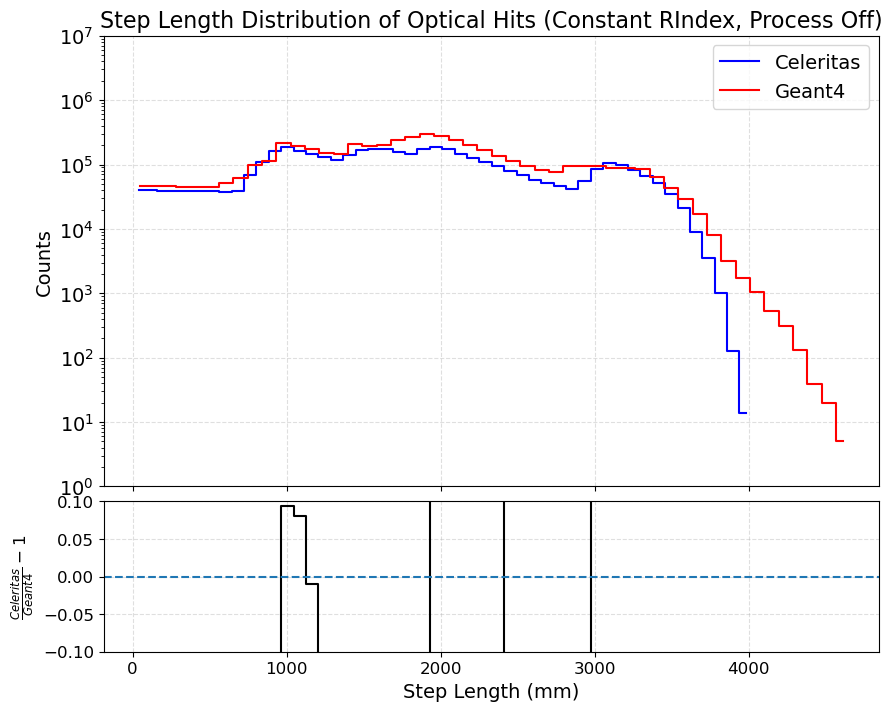

In [55]:
plot_histogram_with_residual(edges_step_c, edges_step_g, counts_step_c, counts_step_g, xlabel="Step Length (mm)", ylabel="Counts", title="Step Length Distribution of Optical Hits (Constant RIndex, Process Off)", ylim_min=1, ylim_max=1e7, xlim=(0, 4000))

using LAr-sphere.gdml and optical photon as primary generator
```sh
/gps/particle opticalphoton
/gps/energy 9.69 eV
/gps/position 0 0 0 mm
/gps/direction 0 0 1
/gps/polarization 1 0 0
/run/beamOn 10
```

In [6]:
celeritas_opt_track_phys_process = load_celeritas("/Users/r1i/Desktop/OpticalSims-upstream/build/dune10kt_v5_refactored_1x2x6_photon_cele.root")
geant_opt_track_phys_process = load_geant("/Users/r1i/Desktop/OpticalSims-upstream/build/dune10kt_v5_refactored_1x2x6_photon_g4.root")

In [17]:
geant_opt_track_phys_process.columns

Index(['x', 'y', 'z', 't', 'wavelength', 'stepLength', 'numSteps'], dtype='object')

In [31]:
t_count_c_opt_track_photon, t_edges_c_opt_track_photon = histogram_distribution(celeritas_opt_track_phys_process, "t", bins=50)
t_count_g_opt_track_photon, t_edges_g_opt_track_photon = histogram_distribution(geant_opt_track_phys_process, "t", bins=50)

In [32]:
step_count_c_opt_track_photon, step_edges_c_opt_track_photon = histogram_distribution(celeritas_opt_track_phys_process, "pathLength", bins=100)
step_count_g_opt_track_photon, step_edges_g_opt_track_photon = histogram_distribution(geant_opt_track_phys_process, "stepLength", bins=100)

In [97]:
# speed of light in mm/ns
c_light = 299.792458 # mm/ns

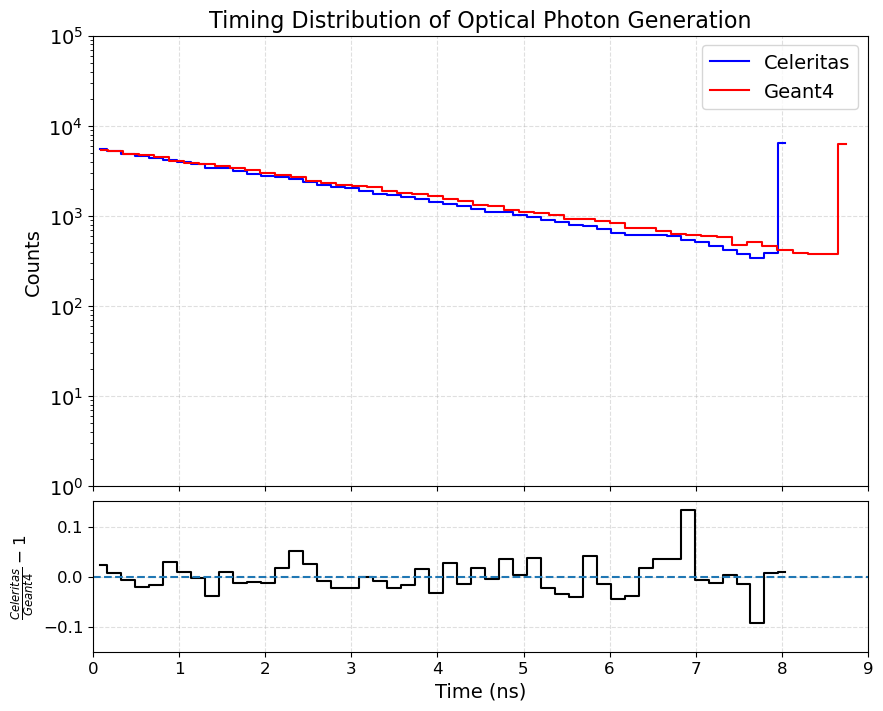

In [40]:
plot_histogram_with_residual(
    t_edges_c_opt_track_photon,
    t_edges_g_opt_track_photon,
    t_count_c_opt_track_photon,
    t_count_g_opt_track_photon,
    xlabel="Time (ns)",
    ylabel="Counts",
    title="Timing Distribution of Optical Photon Generation",
    ylim_min=1,
    ylim_max=1e5,
    xlim=(0, 9)
)

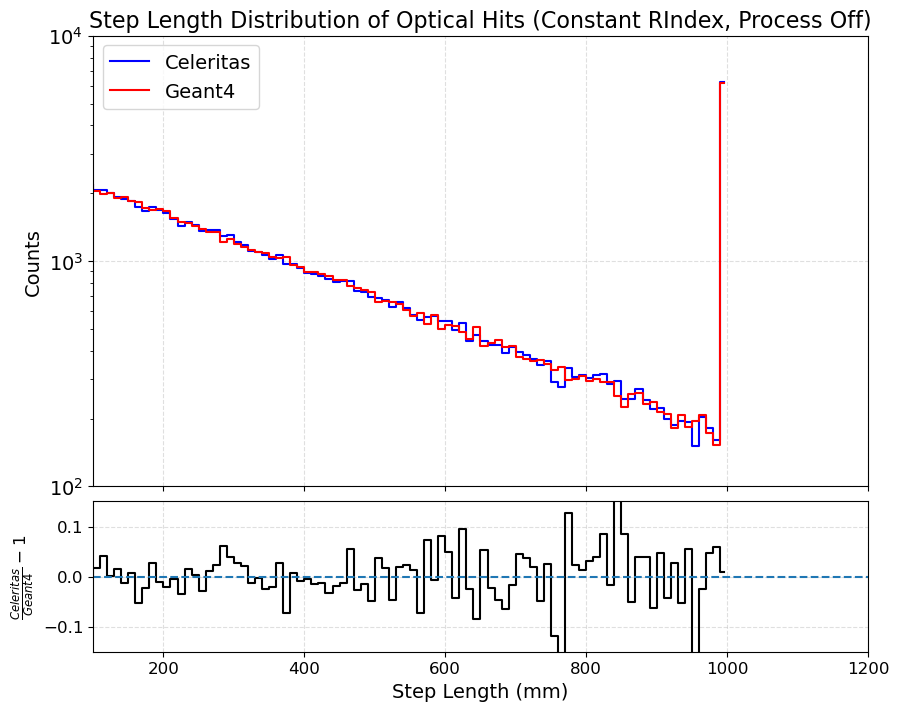

In [30]:
plot_histogram_with_residual(step_edges_c_opt_track_photon, step_edges_g_opt_track_photon, step_count_c_opt_track_photon, step_count_g_opt_track_photon, xlabel="Step Length (mm)", ylabel="Counts", title="Step Length Distribution of Optical Hits (Constant RIndex, Process Off)", ylim_min=100, ylim_max=1e4, xlim=(100, 1200))

In [38]:
n = 1.41 # for 9.69 eV 
c = 299792458 # m/s
v = np.divide(c, n)


In [39]:
l = 1 
t = np.divide(l, v)
t

4.703253742293944e-09

https://github.com/Geant4/geant4/blob/master/source/track/src/G4Track.cc#L166 

In [41]:
l = 1 #1000 mm =1m
v_g = 0.410644*299792458 # v_g/c = 0.410644 for 9.69 eV
t_g = np.divide(l, v_g)
print(t_g*1e9) # in ns

8.122950662816262


In [42]:
v_g_geant = 0.377731*299792458 # v_g/c = 0.377731 for 9.69 eV
t_g_geant = np.divide(l, v_g_geant)
print(t_g_geant*1e9) # in ns

8.830731266381422


This is the RINDEX table
```

 i=98 E_MeV=9.49745e-06 vg/c=0.417598 n=1.39828 1/n=0.715166 denom=2.39465
 i=99 E_MeV=9.9114e-06 vg/c=0.33189 n=1.45313 1/n=0.688169 denom=3.01305
 i=100 E_MeV=1.0597e-05 vg/c=0.223171 n=1.61675 1/n=0.618524 denom=4.48087
```

In [ ]:
import numpy as np

# Geant4 GROUPVEL table points in steep region
E_table = np.array([8.14335e-06, 8.4429e-06, 8.76855e-06, 9.12005e-06, 9.49745e-06, 9.9114e-06, 1.0597e-05]) # MeV
vg_table = np.array([0.609539,0.577214 , 0.536096, 0.483901, 0.417598, 0.33189, 0.223171])  # from your table
# fill from i=97..100

# Your photon energy
E_phot = 9.69e-6

# Geant4 linear interp
vg_G4 = np.interp(E_phot, E_table, vg_table)
print(f"Geant4 linear interp: vg/c = {vg_G4:.4f}")

# RINDEX table from GDML — compute true group velocity analytically
E_rindex = np.array([8.14335e-06, 8.4429e-06, 8.76855e-06, 9.12005e-06, 9.49745e-06, 9.9114e-06, 1.0597e-05])  # last 4 points
n_rindex = np.array([1.30833, 1.32177,1.33954, 1.36372, 1.39828, 1.45313, 1.61675])

# dn/d(logE) via log-space finite diff at E_phot
# bracket E_phot between E_rindex[0] and E_rindex[1]
E0, E1 = 9.49745e-6, 9.69e-6
n0, n1 = 1.39828, 1.41848 #n1 = refractive index G4 estimates at E_phot = 9.69e-6
dn_dlogE = (n1 - n0) / np.log(E1 / E0)
n_mid    = 0.5 * (n0 + n1)
vg_true  = 1.0 / (n_mid + dn_dlogE)   # in units of c
print(f"True vg/c from RINDEX = {vg_true:.4f}")

# Celeritas: E*dn/dE at exact point
dn_dE    = (n1 - n0) / (E1 - E0)
n_at_E   = n0 + dn_dE * (E_phot - E0)
vg_celer = 1.0 / (n_at_E + E_phot * dn_dE)
print(f"Celeritas E*dn/dE:     vg/c = {vg_celer:.4f}")

Geant4 linear interp: vg/c = 0.3777
True vg/c from RINDEX = 0.4141
Celeritas E*dn/dE:     vg/c = 0.4107


In [54]:
0.4107*c_light

123.12476250060001

so, now need to show that the group velocity table that is created by G4 and celeritas is completely differet. 
One idea is to comapre the table that is outputted by celeritas and then the one that geant4 prints for its on the fly calculation
    - created new gdml hough celeritas. Imp point - if you set the potical generator the gdml does not get created.
    - now compare if these group velocity tables are same as G4 and the one that the celeritas creates during the calculator in `GroupVelocityCalculator.hh` file.
    - Identify the units = v_g*c (c_light = 299.792458 mm/ns)
    ```xml
    <matrix coldim="2" name="GROUPVEL0x92b124e00" values="1.8785e-06 243.4 1.88625e-06 243.392 1.90205e-06 243.408 1.9181e-06 243.406 1.93425e-06 243.413 1.9507e-06 243.416 1.9676e-06 243.414 1.98475e-06 243.401 2.00205e-06 243.405 2.01985e-06 243.391 2.03795e-06 243.38 2.0562e-06 243.364 2.07495e-06 243.349 2.09405e-06 243.33 2.1133e-06 243.305 2.1329e-06 243.286 2.1531e-06 243.265 2.1737e-06 243.237 2.19445e-06 243.2 2.2158e-06 243.177 2.2376e-06 243.142 2.25965e-06 243.113 2.28235e-06 243.07 2.30545e-06 243.027 2.3288e-06 242.988 2.3527e-06 242.954 2.3773e-06 242.895 2.4024e-06 242.857 2.4278e-06 242.796 2.45395e-06 242.747 2.48075e-06 242.7 2.50785e-06 242.628 2.5358e-06 242.579 2.5644e-06 242.507 2.59335e-06 242.444 2.623e-06 242.377 2.6536e-06 242.299 2.6849e-06 242.226 2.71665e-06 242.143 2.7495e-06 242.068 2.78315e-06 241.973 2.8173e-06 241.888 2.85265e-06 241.79 2.88885e-06 241.687 2.92565e-06 241.589 2.9634e-06 241.475 3.0025e-06 241.365 3.0427e-06 241.25 3.0836e-06 241.119 3.12595e-06 240.985 3.1695e-06 240.853 3.21385e-06 240.699 3.2599e-06 240.556 3.3073e-06 240.388 3.35565e-06 240.228 3.40545e-06 240.046 3.4572e-06 239.857 3.51055e-06 239.661 3.56505e-06 239.447 3.6218e-06 239.23 3.6804e-06 238.994 3.74035e-06 238.744 3.8029e-06 238.485 3.86755e-06 238.197 3.9338e-06 237.904 4.0024e-06 237.59 4.0741e-06 237.245 4.14835e-06 236.879 4.2247e-06 236.502 4.30465e-06 236.071 4.38765e-06 235.633 4.47315e-06 235.146 4.5629e-06 234.63 4.6563e-06 234.06 4.7527e-06 233.457 4.85315e-06 232.789 4.95895e-06 232.072 5.06945e-06 231.276 5.18395e-06 230.422 5.3049e-06 229.458 5.43155e-06 228.407 5.56315e-06 227.238 5.70265e-06 225.947 5.8493e-06 224.485 6.0022e-06 222.854 6.16335e-06 221.038 6.3351e-06 218.927 6.51655e-06 216.52 6.7069e-06 213.767 6.9107e-06 210.553 7.1272e-06 206.783 7.3556e-06 202.36 7.60155e-06 197.026 7.86435e-06 190.57 8.14335e-06 182.735 8.4429e-06 173.045 8.76855e-06 160.718 9.12005e-06 145.07 9.49745e-06 125.193 9.9114e-06 99.4981 1.0597e-05 66.9049"/>
    ```

In [55]:
# Geant4
E_g4 = [
    1.8785e-06, 1.88625e-06, 1.90205e-06, 1.9181e-06, 1.93425e-06,
    1.9507e-06, 1.9676e-06, 1.98475e-06, 2.00205e-06, 2.01985e-06,
    2.03795e-06, 2.0562e-06, 2.07495e-06, 2.09405e-06, 2.1133e-06,
    2.1329e-06, 2.1531e-06, 2.1737e-06, 2.19445e-06, 2.2158e-06,
    2.2376e-06, 2.25965e-06, 2.28235e-06, 2.30545e-06, 2.3288e-06,
    2.3527e-06, 2.3773e-06, 2.4024e-06, 2.4278e-06, 2.45395e-06,
    2.48075e-06, 2.50785e-06, 2.5358e-06, 2.5644e-06, 2.59335e-06,
    2.623e-06, 2.6536e-06, 2.6849e-06, 2.71665e-06, 2.7495e-06,
    2.78315e-06, 2.8173e-06, 2.85265e-06, 2.88885e-06, 2.92565e-06,
    2.9634e-06, 3.0025e-06, 3.0427e-06, 3.0836e-06, 3.12595e-06,
    3.1695e-06, 3.21385e-06, 3.2599e-06, 3.3073e-06, 3.35565e-06,
    3.40545e-06, 3.4572e-06, 3.51055e-06, 3.56505e-06, 3.6218e-06,
    3.6804e-06, 3.74035e-06, 3.8029e-06, 3.86755e-06, 3.9338e-06,
    4.0024e-06, 4.0741e-06, 4.14835e-06, 4.2247e-06, 4.30465e-06,
    4.38765e-06, 4.47315e-06, 4.5629e-06, 4.6563e-06, 4.7527e-06,
    4.85315e-06, 4.95895e-06, 5.06945e-06, 5.18395e-06, 5.3049e-06,
    5.43155e-06, 5.56315e-06, 5.70265e-06, 5.8493e-06, 6.0022e-06,
    6.16335e-06, 6.3351e-06, 6.51655e-06, 6.7069e-06, 6.9107e-06,
    7.1272e-06, 7.3556e-06, 7.60155e-06, 7.86435e-06, 8.14335e-06,
    8.4429e-06, 8.76855e-06, 9.12005e-06, 9.49745e-06, 9.9114e-06,
    1.0597e-05
]

vg_over_c_g4 = [
    0.811894, 0.811868, 0.811921, 0.811915, 0.811939,
    0.811950, 0.811943, 0.811899, 0.811910, 0.811865,
    0.8118293179, 0.811774, 0.8117243195, 0.8116623204, 0.811578,
    0.811514, 0.811446, 0.811352, 0.811229327, 0.811152,
    0.811034, 0.8109373314, 0.81079336, 0.81065158, 0.810521,
    0.810406, 0.810210, 0.810083, 0.809880, 0.80971835,
    0.809560, 0.8093193561, 0.809157, 0.808915, 0.8087073654,
    0.808483, 0.808222, 0.807977, 0.8077023808, 0.807451,
    0.8071353895, 0.806851, 0.80652689, 0.8061814042, 0.8058534092,
    0.805475, 0.805107, 0.804724, 0.804286, 0.8038384403,
    0.803399, 0.8028854551, 0.802410, 0.801849, 0.80131395,
    0.800706489, 0.800076, 0.79942409, 0.7987095202, 0.797985,
    0.797198, 0.7963645571, 0.795501, 0.7945395859, 0.793561,
    0.792514, 0.791363, 0.790143559, 0.788885, 0.7874476993,
    0.7859877228, 0.7843617492, 0.782643, 0.780740, 0.778729,
    0.7765028783, 0.7741099181, 0.7714549625, 0.7686070106, 0.765390,
    0.76188354, 0.7579841929, 0.7536782683, 0.748802, 0.743361,
    0.737302563, 0.730262, 0.7222348459, 0.713050, 0.702330,
    0.689753, 0.675002, 0.6572082159, 0.6356737314, 0.6095394058,
    0.577214, 0.5360966534, 0.4839016654, 0.4175989465, 0.331890,
    0.2231718087
]

In [56]:
# Celeritas (values from the exported GROUPVEL table are in mm/ns)

E_cel = E_g4.copy()

groupvel_mm_ns = [
    243.4, 243.392, 243.408, 243.406, 243.413,
    243.416, 243.414, 243.401, 243.405, 243.391,
    243.38, 243.364, 243.349, 243.33, 243.305,
    243.286, 243.265, 243.237, 243.2, 243.177,
    243.142, 243.113, 243.07, 243.027, 242.988,
    242.954, 242.895, 242.857, 242.796, 242.747,
    242.7, 242.628, 242.579, 242.507, 242.444,
    242.377, 242.299, 242.226, 242.143, 242.068,
    241.973, 241.888, 241.79, 241.687, 241.589,
    241.475, 241.365, 241.25, 241.119, 240.985,
    240.853, 240.699, 240.556, 240.388, 240.228,
    240.046, 239.857, 239.661, 239.447, 239.23,
    238.994, 238.744, 238.485, 238.197, 237.904,
    237.59, 237.245, 236.879, 236.502, 236.071,
    235.633, 235.146, 234.63, 234.06, 233.457,
    232.789, 232.072, 231.276, 230.422, 229.458,
    228.407, 227.238, 225.947, 224.485, 222.854,
    221.038, 218.927, 216.52, 213.767, 210.553,
    206.783, 202.36, 197.026, 190.57, 182.735,
    173.045, 160.718, 145.07, 125.193, 99.4981,
    66.9049
]

# Convert to v_g/c
c_mm_ns = 299.792458
vg_over_c_cel = [v / c_mm_ns for v in groupvel_mm_ns]

In [61]:
vg_over_c_cel

[0.811895007712302,
 0.8118683225846862,
 0.8119216928399179,
 0.811915021558014,
 0.8119383710446778,
 0.8119483779675337,
 0.8119417066856297,
 0.8118983433532541,
 0.811911685917062,
 0.8118649869437342,
 0.8118282948932625,
 0.8117749246380307,
 0.8117248900237509,
 0.8116615128456633,
 0.8115781218218638,
 0.8115147446437762,
 0.8114446961837846,
 0.811351298237129,
 0.8112278795219057,
 0.8111511597800102,
 0.8110344123466908,
 0.8109376787590834,
 0.8107942461981481,
 0.8106508136372129,
 0.8105207236400856,
 0.8104073118477183,
 0.8102105090315515,
 0.8100837546753761,
 0.8098802805773052,
 0.8097168341706582,
 0.809560059045915,
 0.8093198928973723,
 0.8091564464907253,
 0.8089162803421825,
 0.8087061349622077,
 0.808482647018425,
 0.8082224670241704,
 0.8079789652346757,
 0.8077021070356613,
 0.8074519339642627,
 0.8071350480738245,
 0.806851518592906,
 0.8065246257796118,
 0.8061810547615578,
 0.8058541619482635,
 0.8054738988797376,
 0.8051069783750197,
 0.8047233796655417,

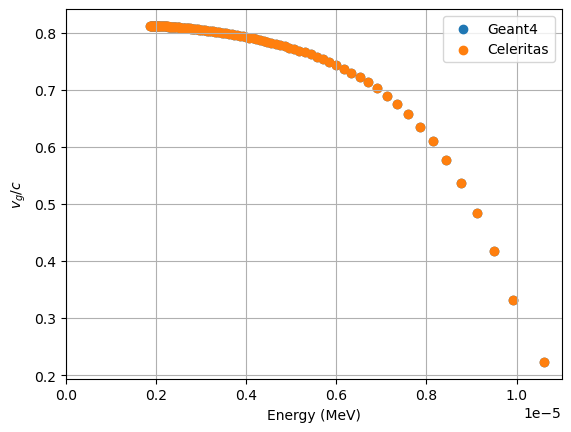

In [62]:
plt.scatter(E_g4, vg_over_c_g4, label="Geant4")
plt.scatter(E_cel, vg_over_c_cel, label="Celeritas")
plt.legend()
plt.xlabel("Energy (MeV)")
plt.xlim(0, 1.1e-5)
plt.ylabel(r"$v_g/c$")
plt.grid(True)

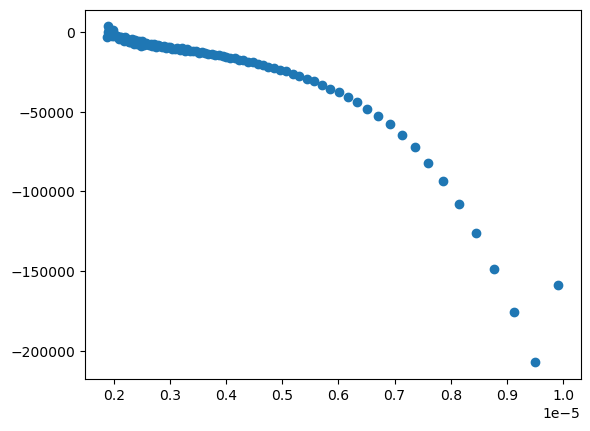

In [64]:
plt.scatter(E_cel[:-1], np.diff(vg_over_c_cel)/np.diff(E_cel), label="Celeritas derivative")

# Changes in Group Velocity calculator

In [165]:
import pandas as pd
import matplotlib.pyplot as plt

# ----------------------------
# Load JSONL files
# ----------------------------

g4 = pd.read_json(
    "/Users/r1i/Desktop/OpticalSims-upstream/build/group-vel-g4-steppingaction.jsonl",
    lines=True
)

cel_zero = pd.read_json(
    "/Users/r1i/Desktop/OpticalSims-upstream/cele-root-files/vg_comparison/group_velocity_eval_der_0.jsonl",
    lines=True
)

cel_backward = pd.read_json(
    "/Users/r1i/Desktop/OpticalSims-upstream/cele-root-files/vg_comparison/group_velocity_eval_derivative_changed.jsonl",
    lines=True
)

gdml_val_cele = pd.read_json(
    "/Users/r1i/Desktop/OpticalSims-upstream/cele-root-files/vg_comparison/gdml-group-vel-g4-cele.jsonl",
    lines=True
)
gdml_val_g4 = pd.read_json(
    "/Users/r1i/Desktop/OpticalSims-upstream/cele-root-files/vg_comparison/gdml-group-vel-g4.jsonl",
    lines=True
)

# ----------------------------
# Quick inspection
# ----------------------------


In [35]:
print(g4.columns)
print(cel_zero.columns)
print(cel_backward.columns)
print(gdml_val_g4.columns)

Index(['E_MeV', 'n', 'vg_gdml_over_c', 'vg_track_over_c', 'vphase_over_c'], dtype='object')
Index(['dnde', 'energy_mev', 'rindex', 'vg', 'vg_over_c'], dtype='object')
Index(['dnde', 'energy_mev', 'rindex', 'vg', 'vg_over_c'], dtype='object')
Index(['E_MeV', 'i', 'n', 'vg_over_c', 'vphase_over_c'], dtype='object')


In [29]:
#using the formaula v_g = c / (n + E * dn/dE) to compute the group velocity from the refractive index and its derivative, and compare it with the values from Geant4 and Celeritas.
import numpy as np
def compute_group_velocity(df,energy_col, n, dn_dE):
    c = 299792458 # m/s
    E = df[energy_col].values 
    n = df[n].values
    if dn_dE is None:
        # Compute dn/dE using finite differences
        dn_dE = np.gradient(n, E)
    else:
        dn_dE = df[dn_dE].values
    v_g = c / (n + E * dn_dE)
    return v_g

In [30]:
g4["vg_theory"] = compute_group_velocity(g4, "E_MeV", "n", None)
cel_zero["vg_theory"] = compute_group_velocity(cel_zero, "energy_mev", "rindex", "dnde")
cel_backward["vg_theory"] = compute_group_velocity(cel_backward, "energy_mev", "rindex", "dnde")
gdml_val_g4["vg_theory"] = compute_group_velocity(gdml_val_g4, "E_MeV", "n", None)

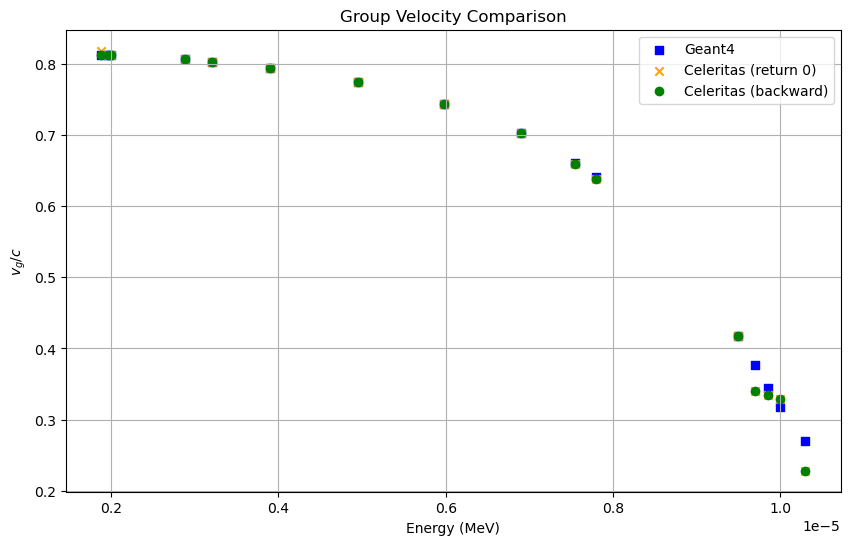

In [41]:
plt.figure(figsize=(10, 6))
plt.scatter(g4["E_MeV"], g4["vg_track_over_c"], label="Geant4", c= "blue", marker = "s")
plt.scatter(cel_zero["energy_mev"], cel_zero["vg_over_c"], label="Celeritas (return 0)", c= "orange", marker = "x")
plt.scatter(cel_backward["energy_mev"], cel_backward["vg_over_c"], label="Celeritas (backward)", c= "green", marker = "o")
#plt.scatter(gdml_val_g4["E_MeV"], gdml_val_g4["vg_over_c"], label="GDML Geant4", c= "red")
plt.legend()
plt.xlabel("Energy (MeV)")
plt.ylabel(r"$v_g/c$")
plt.title("Group Velocity Comparison")
plt.grid(True)  
plt.show()


In [42]:
gdml_val_finer = pd.read_json(
    "/Users/r1i/Desktop/OpticalSims-upstream/build/gdml-group-vel-g4.jsonl",
    lines=True
)

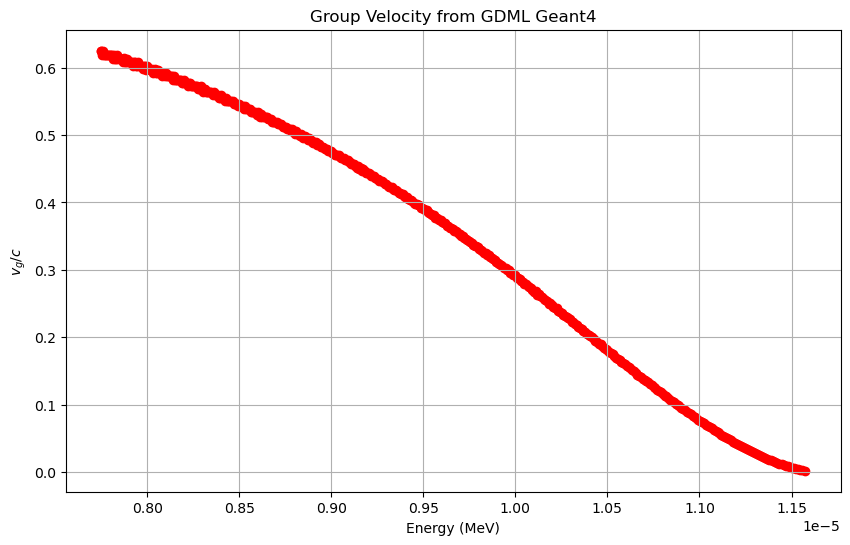

In [44]:
plt.figure(figsize=(10, 6))

plt.scatter(gdml_val_finer["E_MeV"], gdml_val_finer["vg_over_c"], label="GDML Geant4", c= "red")
plt.title("Group Velocity from GDML Geant4")
plt.xlabel("Energy (MeV)")
plt.ylabel(r"$v_g/c$")
plt.grid(True)
plt.show()

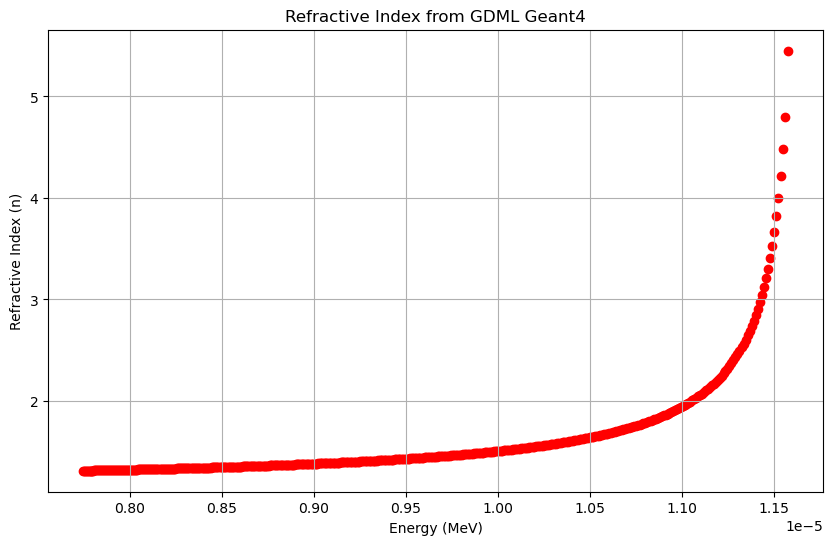

In [46]:
plt.figure(figsize=(10, 6))

plt.scatter(gdml_val_finer["E_MeV"], gdml_val_finer["n"], label="GDML Geant4", c= "red")
plt.title("Refractive Index from GDML Geant4")
plt.xlabel("Energy (MeV)")
plt.ylabel("Refractive Index (n)")
plt.grid(True)
plt.show()

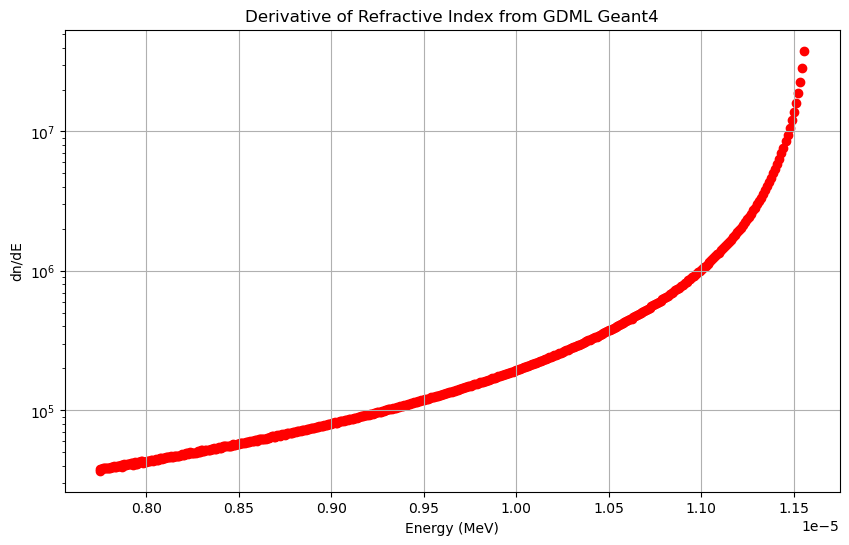

In [50]:
#plot dn/dE from the GDML Geant4 data
plt.figure(figsize=(10, 6))
plt.scatter(gdml_val_finer["E_MeV"][:-1], np.diff(gdml_val_finer["n"]) / np.diff(gdml_val_finer["E_MeV"]), label="GDML Geant4", c= "red")
plt.title("Derivative of Refractive Index from GDML Geant4")
plt.yscale("log")
plt.xlabel("Energy (MeV)")
plt.ylabel("dn/dE")
plt.grid(True)
plt.show()

In [24]:

import pandas as pd
import matplotlib.pyplot as plt

g4 = pd.read_json(
    "/Users/r1i/Desktop/OpticalSims-upstream/build/group-vel-g4-steppingaction.jsonl",
    lines=True
)

cel_backward = pd.read_json(
    "/Users/r1i/Desktop/OpticalSims-upstream/build/group_velocity_eval_changed.jsonl",
    lines=True
)


In [25]:
cel_backward.columns

Index(['dnde', 'energy_mev', 'rindex', 'vg', 'vg_over_c'], dtype='object')

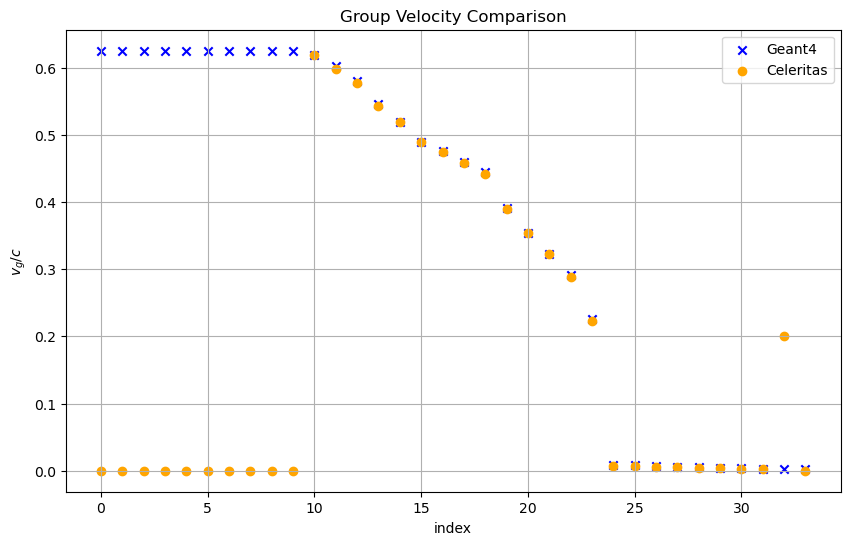

In [26]:
plt.figure(figsize=(10, 6))
plt.scatter(g4.index, g4["vg_track_over_c"], label="Geant4", c= "blue", marker = "x")
plt.scatter(cel_backward.index, cel_backward["vg_over_c"], label="Celeritas", c= "orange", marker = "o")

#plt.xlim(0.65e-5, 1.25e-5)
plt.legend()
plt.xlabel("index")
plt.ylabel(r"$v_g/c$")
plt.title("Group Velocity Comparison")
plt.grid(True)  
plt.show()


In [27]:
celeritas_opt_track_phys_process_der = load_celeritas("/Users/r1i/Desktop/OpticalSims-upstream/build/dune10kt_v5_refactored_1x2x6_photon_cele.root")
geant_opt_track_phys_process_der = load_geant("/Users/r1i/Desktop/OpticalSims-upstream/build/dune10kt_v5_refactored_1x2x6_photon_g4.root")

In [28]:
celeritas_opt_track_phys_process_der =velocity(celeritas_opt_track_phys_process_der, "pathLength")
geant_opt_track_phys_process_der =velocity(geant_opt_track_phys_process_der, "stepLength")

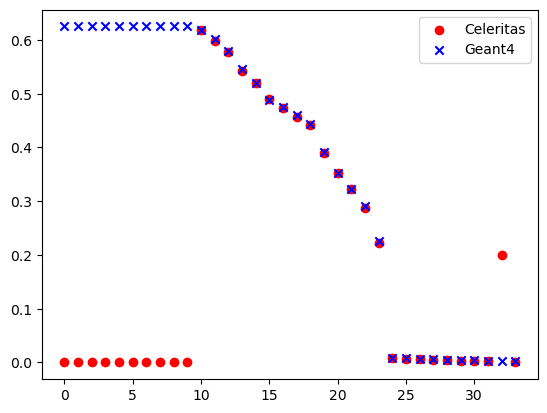

In [29]:
plt.scatter(x = celeritas_opt_track_phys_process_der.index, y = celeritas_opt_track_phys_process_der["rough_velocity"], label = "Celeritas", c= "red", marker = "o")
plt.scatter(x = geant_opt_track_phys_process_der.index, y = geant_opt_track_phys_process_der["rough_velocity"], label = "Geant4", c= "blue", marker = "x")
plt.legend()

<Figure size 1000x600 with 0 Axes>

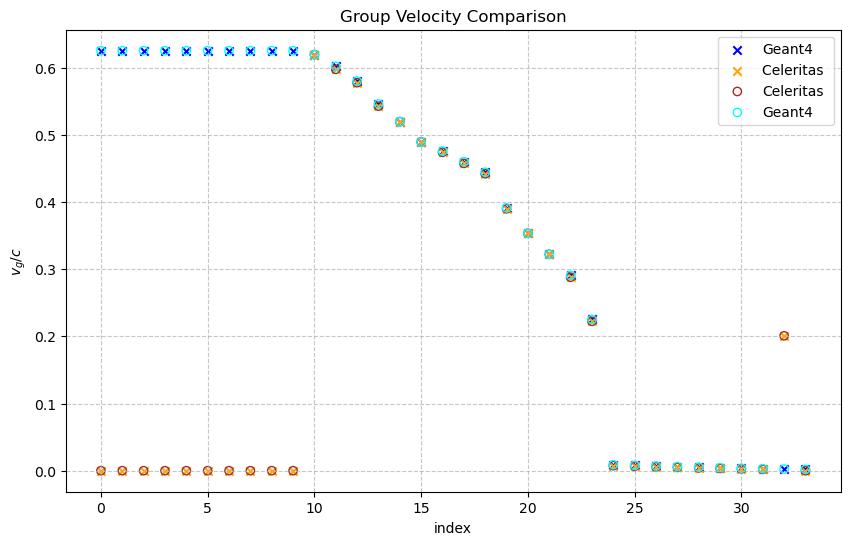

In [30]:
plt.figure(figsize=(10, 6))
plt.figure(figsize=(10, 6))
plt.scatter(g4.index, g4["vg_track_over_c"], label="Geant4", c= "blue", marker = "x")
plt.scatter(cel_backward.index, cel_backward["vg_over_c"], label="Celeritas ", c= "orange", marker = "x")
plt.scatter(x = celeritas_opt_track_phys_process_der.index, y = celeritas_opt_track_phys_process_der["rough_velocity"], label = "Celeritas",  marker='o', facecolors='none', edgecolors='brown')
plt.scatter(x = geant_opt_track_phys_process_der.index, y = geant_opt_track_phys_process_der["rough_velocity"], label = "Geant4",  marker='o', facecolors='none', edgecolors='cyan')
#plt.xlim(23, 30)
#plt.ylim(0.0025, 0.01)
plt.legend()
plt.legend()
plt.xlabel("index")
plt.ylabel(r"$v_g/c$")
plt.title("Group Velocity Comparison")
plt.grid(linestyle='--', alpha=0.7)  
plt.show()

<Figure size 1000x600 with 0 Axes>

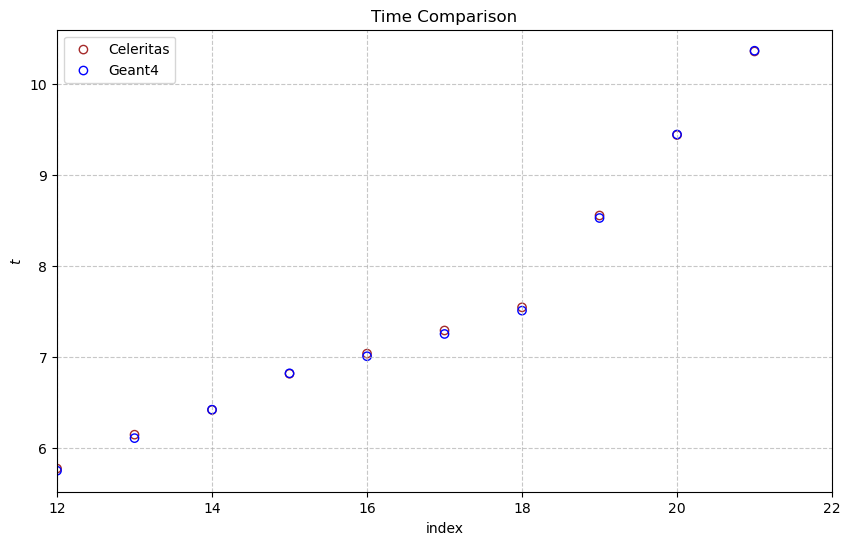

In [33]:
plt.figure(figsize=(10, 6))
plt.figure(figsize=(10, 6))

plt.scatter(x = celeritas_opt_track_phys_process_der.index[12:22], y = celeritas_opt_track_phys_process_der["t"][12:22], label = "Celeritas",  marker='o', facecolors='none', edgecolors='brown')
plt.scatter(x = geant_opt_track_phys_process_der.index[12:22], y = geant_opt_track_phys_process_der["t"][12:22], label = "Geant4",  marker='o', facecolors='none', edgecolors='blue')
plt.xlim(12, 22)
#plt.ylim(0, 1e6)
plt.legend()
plt.legend()
plt.xlabel("index")
plt.ylabel(r"$t$")
plt.title("Time Comparison")
plt.grid(linestyle='--', alpha=0.7)  
plt.show()

<Figure size 1000x600 with 0 Axes>

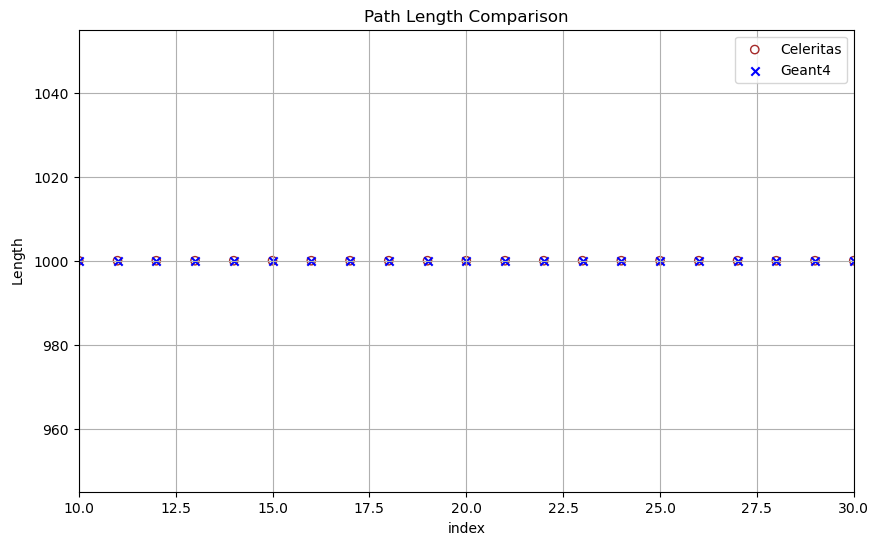

In [34]:
plt.figure(figsize=(10, 6))
plt.figure(figsize=(10, 6))

plt.scatter(x = celeritas_opt_track_phys_process_der.index, y = celeritas_opt_track_phys_process_der["pathLength"], label = "Celeritas",  marker='o', facecolors='none', edgecolors='brown')
plt.scatter(x = geant_opt_track_phys_process_der.index, y = geant_opt_track_phys_process_der["stepLength"], label = "Geant4",  marker='x',  color='blue')
plt.xlim(10, 30)
#plt.ylim(0, 250)
plt.legend()
plt.legend()
plt.xlabel("index")
plt.ylabel(r"$\mathrm{Length}$")
plt.title("Path Length Comparison")
plt.grid(True)  
plt.show()

We see step length and the time are different but, the group velocity coming from the groupvelocity calculator and the steppeing action matches the steplength/time but celeritas and geant step length does not match with time. more so for higher indexes. Also, $v_g$ is different. for index after 23 by 0.001

Changing the absorption values to very large numbers in order to turn off absorption in the simulation.
```
-    <matrix name="ABS" coldim="2" values="1.3778e-06 864.473 1.55e-05 0.00296154"/>
+    <matrix name="ABS" coldim="2" values="1.3778e-06 1.0e9 1.55e-05 1.0e9"/>
```

With the new change in the derivative calculator we start seeing that g4 and celeritas values starts matching with geant4. Secondl, let us see what happens when we bring back the abslength. we have been using `lar-sphere-diff-vals'

Different comparison
- using the `lar-sphere-diffs.gdml` 34 events and `abslength` set to infinity

### Different strategies


0. - nothing changed;
1. - changes the endpoint derivative
2. change the v_g definition to the d(n)/d(lnE)
3. Take mean of the slopes => For this show the maths.= 1+0
4. Changed the mean of the derivative grid calculator and then ran 100 MeV electron offloading the optical photon to celeritas otpical track for dune geometry; compared g4 and celeritas files for it. 
5. Changed the mean and clamp the group velocity so that it does not interpolate any more (includes 3 + v_g change) and use `dune geomatry` same as 4.
6. changing absorption length to 100 in dune10-kt - did not help either
7. Going back to the lar-celer-vals varied gdml and then ; electron is the particle gun and the optical phton tracks are offloaded to celeritas. 

In [153]:

import pandas as pd
import matplotlib.pyplot as plt
g4 = pd.read_json(
    "/Users/r1i/Desktop/OpticalSims-upstream/cele-root-files/vg_comparison/0/group-vel-g4-steppingaction.jsonl",
    lines=True
)

cel_0 = pd.read_json(
    "/Users/r1i/Desktop/OpticalSims-upstream/cele-root-files/vg_comparison/0/group_velocity_eval.jsonl",
    lines=True
)
cel_1 = pd.read_json(
    "/Users/r1i/Desktop/OpticalSims-upstream/cele-root-files/vg_comparison/1/group_velocity_eval_endpoint.jsonl",
    lines=True
)
cel_2 = pd.read_json(
    "/Users/r1i/Desktop/OpticalSims-upstream/cele-root-files/vg_comparison/2/group_velocity_eval_ln.jsonl",
    lines=True
)
cel_3 = pd.read_json("/Users/r1i/Desktop/OpticalSims-upstream/cele-root-files/vg_comparison/3/group_velocity_eval_slope-mean.jsonl",
    lines=True
)


In [154]:
gdml_g4 = pd.read_json("/Users/r1i/Desktop/OpticalSims-upstream/cele-root-files/vg_comparison/0/gdml-group-vel-g4.jsonl", lines=True)

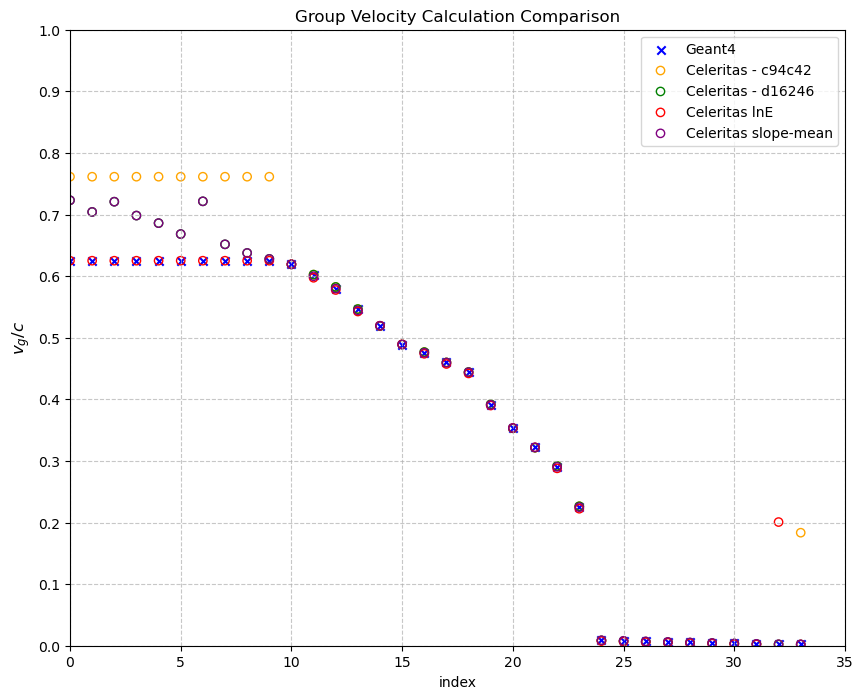

In [155]:
plt.figure(figsize=(10, 8))
plt.scatter(g4.index, g4["vg_track_over_c"], label="Geant4", c= "blue", marker = "x")
plt.scatter(cel_0.index, cel_0["vg_over_c"], label="Celeritas - c94c42", marker='o', facecolors='none', edgecolors=  "orange")
plt.scatter(cel_1.index, cel_1["vg_over_c"], label="Celeritas - d16246", marker='o', facecolors='none', edgecolors=  "green")
plt.scatter(cel_2.index, cel_2["vg_over_c"], label="Celeritas lnE", marker='o', facecolors='none', edgecolors=  "red")
plt.scatter(cel_3.index, cel_3["vg_over_c"], label="Celeritas slope-mean", marker='o', facecolors='none', edgecolors=  "purple")
plt.xlim(0, 35)
plt.ylim(0,1)
plt.yticks(np.linspace(0, 1, 11))
plt.legend()
plt.xlabel("index")
plt.ylabel(r"$v_g/c$", fontsize=12)
plt.title("Group Velocity Calculation Comparison")
plt.grid(linestyle='--', alpha=0.7)  
plt.show()


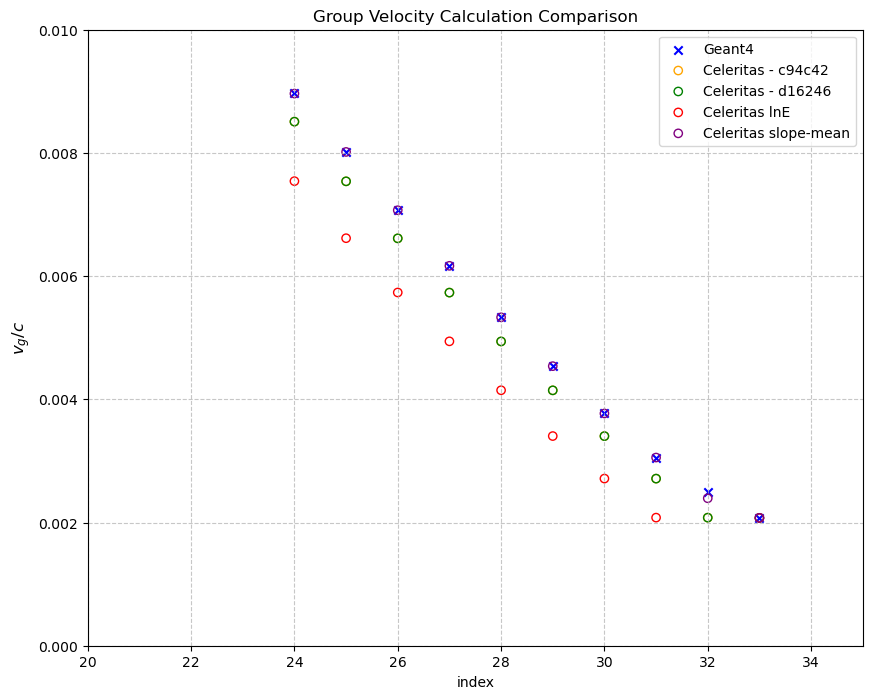

In [156]:
plt.figure(figsize=(10, 8))
plt.scatter(g4.index, g4["vg_track_over_c"], label="Geant4", c= "blue", marker = "x")
plt.scatter(cel_0.index, cel_0["vg_over_c"], label="Celeritas - c94c42", marker='o', facecolors='none', edgecolors=  "orange")
plt.scatter(cel_1.index, cel_1["vg_over_c"], label="Celeritas - d16246", marker='o', facecolors='none', edgecolors=  "green")
plt.scatter(cel_2.index, cel_2["vg_over_c"], label="Celeritas lnE", marker='o', facecolors='none', edgecolors=  "red")
plt.scatter(cel_3.index, cel_3["vg_over_c"], label="Celeritas slope-mean", marker='o', facecolors='none', edgecolors=  "purple")
plt.xlim(20, 35)
plt.ylim(0,0.01)

plt.legend()
plt.xlabel("index")
plt.ylabel(r"$v_g/c$", fontsize=12)
plt.title("Group Velocity Calculation Comparison")
plt.grid(linestyle='--', alpha=0.7)  
plt.show()


In [157]:
g4.columns

Index(['E_MeV', 'n', 'vg_gdml_over_c', 'vg_track_over_c', 'vphase_over_c'], dtype='object')

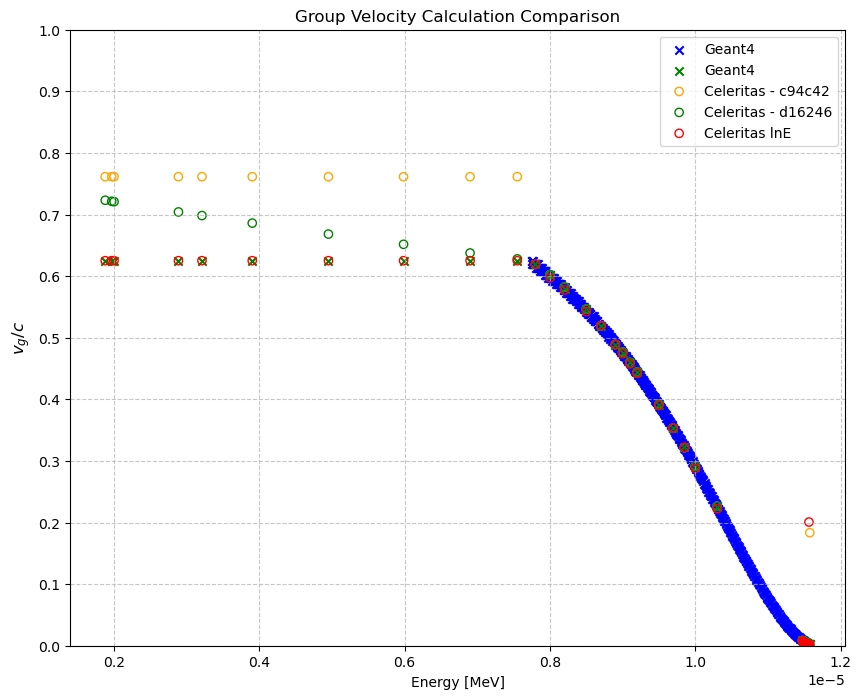

In [158]:
plt.figure(figsize=(10, 8))
plt.scatter(gdml_g4.E_MeV, gdml_g4["vg_over_c"], label="Geant4", c= "blue", marker = "x")
plt.scatter(g4.E_MeV, g4["vg_track_over_c"], label="Geant4", c= "green", marker = "x")
plt.scatter(cel_0.energy_mev, cel_0["vg_over_c"], label="Celeritas - c94c42", marker='o', facecolors='none', edgecolors=  "orange")
plt.scatter(cel_1.energy_mev, cel_1["vg_over_c"], label="Celeritas - d16246", marker='o', facecolors='none', edgecolors=  "green")
plt.scatter(cel_2.energy_mev, cel_2["vg_over_c"], label="Celeritas lnE", marker='o', facecolors='none', edgecolors=  "red")

plt.ylim(0,1)
plt.yticks(np.linspace(0, 1, 11))
plt.legend()
plt.xlabel("Energy [MeV]")
plt.ylabel(r"$v_g/c$", fontsize=12)
plt.title("Group Velocity Calculation Comparison")
plt.grid(linestyle='--', alpha=0.7)  
plt.show()


In [159]:
gdml_g4.columns

Index(['E_MeV', 'i', 'n', 'vg_over_c', 'vphase_over_c'], dtype='object')

In [160]:
derivative = gdml_g4["n"].diff() / gdml_g4.E_MeV.diff()

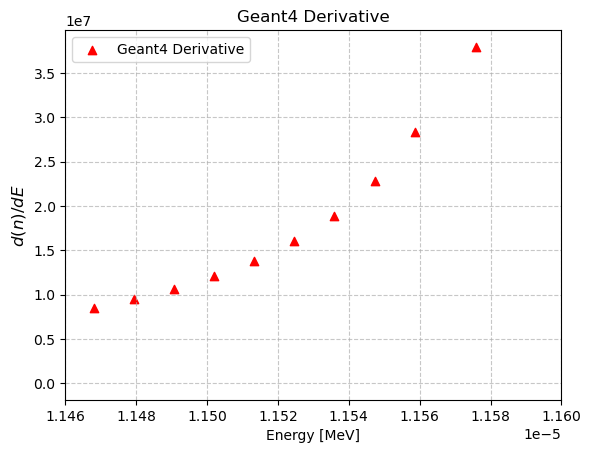

In [161]:
plt.scatter(gdml_g4.E_MeV, derivative, label="Geant4 Derivative", c= "red", marker = "^")
plt.xlim(1.146e-5, 1.16e-5)
plt.xlabel("Energy [MeV]")
plt.ylabel(r"$d(n)/dE$", fontsize=12)
plt.title("Geant4 Derivative")
plt.legend()
plt.grid(linestyle='--', alpha=0.7)  
plt.show()

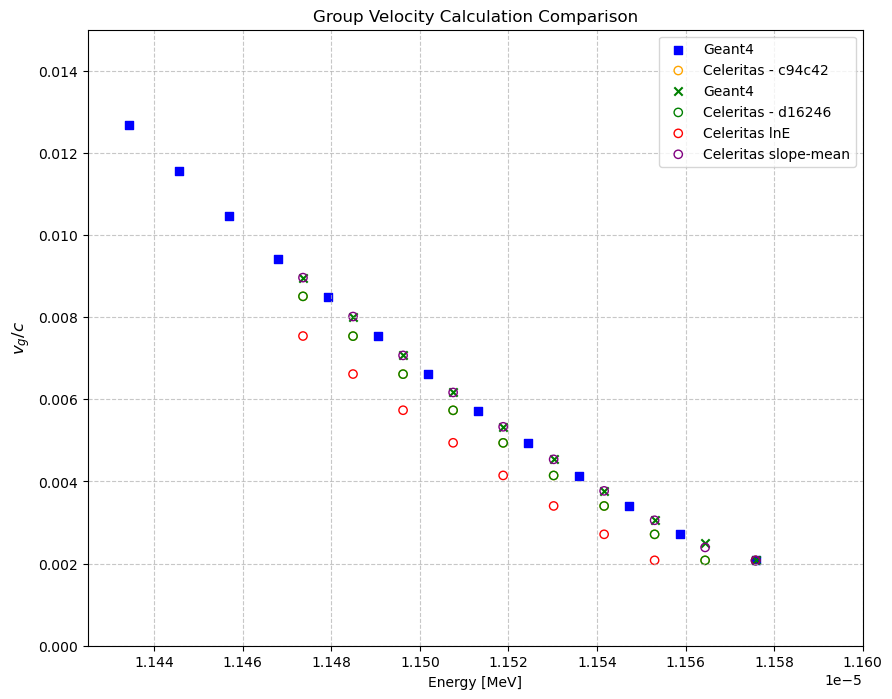

In [163]:
plt.figure(figsize=(10, 8))
plt.scatter(gdml_g4.E_MeV, gdml_g4["vg_over_c"], label="Geant4", c= "blue", marker = "s")
plt.scatter(cel_0.energy_mev, cel_0["vg_over_c"], label="Celeritas - c94c42", marker='o', facecolors='none', edgecolors=  "orange")
plt.scatter(g4.E_MeV, g4["vg_track_over_c"], label="Geant4", c= "green", marker = "x")
plt.scatter(cel_1.energy_mev, cel_1["vg_over_c"], label="Celeritas - d16246", marker='o', facecolors='none', edgecolors=  "green")
plt.scatter(cel_2.energy_mev, cel_2["vg_over_c"], label="Celeritas lnE", marker='o', facecolors='none', edgecolors=  "red")
plt.scatter(cel_3.energy_mev, cel_3["vg_over_c"], label="Celeritas slope-mean", marker='o', facecolors='none', edgecolors=  "purple")
plt.xlim(1.1425e-5,1.16e-5)
plt.ylim(0,0.015)
plt.legend()
plt.xlabel("Energy [MeV]")
plt.ylabel(r"$v_g/c$", fontsize=12)
plt.title("Group Velocity Calculation Comparison")
plt.grid(linestyle='--', alpha=0.7)  
plt.show()


In [122]:
celeritas_0 = load_celeritas("/Users/r1i/Desktop/OpticalSims-upstream/cele-root-files/vg_comparison/0/dune10kt_v5_refactored_1x2x6_photon_cele_og.root")
celeritas_1 = load_celeritas("/Users/r1i/Desktop/OpticalSims-upstream/cele-root-files/vg_comparison/1/dune10kt_v5_refactored_1x2x6_photon_cele_endpoint.root")
celeritas_2 = load_celeritas("/Users/r1i/Desktop/OpticalSims-upstream/cele-root-files/vg_comparison/2/dune10kt_v5_refactored_1x2x6_photon_cele_lne.root")
celeritas_3 = load_celeritas("/Users/r1i/Desktop/OpticalSims-upstream/cele-root-files/vg_comparison/3/dune10kt_v5_refactored_1x2x6_photon_cele-mean.root")
g4 = load_geant("/Users/r1i/Desktop/OpticalSims-upstream/cele-root-files/vg_comparison/0/dune10kt_v5_refactored_1x2x6_photon_g4_og.root")

In [123]:
celeritas_0 = velocity(celeritas_0, "pathLength")
celeritas_1 = velocity(celeritas_1, "pathLength")
celeritas_2 = velocity(celeritas_2, "pathLength")
celeritas_3 = velocity(celeritas_3, "pathLength")
g4 = velocity(g4, "stepLength")

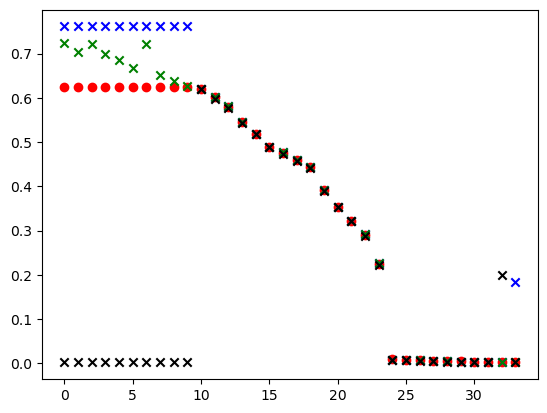

In [124]:
plt.scatter(x = g4.index, y = g4["rough_velocity"], label = "Geant4", c= "red", marker = "o")
plt.scatter(x = celeritas_0.index, y = celeritas_0["rough_velocity"], label = "Celeritas 0 ", c= "blue", marker = "x")
plt.scatter(x = celeritas_1.index, y = celeritas_1["rough_velocity"], label = "Celeritas 1", c= "green", marker = "x")
plt.scatter(x = celeritas_2.index, y = celeritas_2["rough_velocity"], label = "Celeritas 2", c= "black", marker = "x")


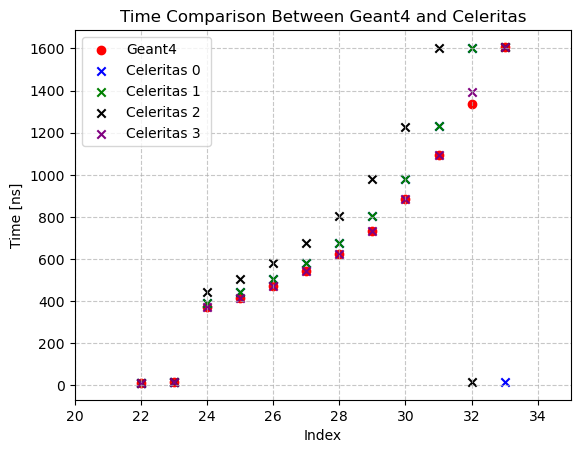

In [125]:
plt.scatter(x = g4.index[22:35], y = g4["t"][22:35], label = "Geant4", c= "red", marker = "o")
plt.scatter(x = celeritas_0.index[22:35], y = celeritas_0["t"][22:35], label = "Celeritas 0 ", c= "blue", marker = "x")
plt.scatter(x = celeritas_1.index[22:35], y = celeritas_1["t"][22:35], label = "Celeritas 1", c= "green", marker = "x")
plt.scatter(x = celeritas_2.index[22:35], y = celeritas_2["t"][22:35], label = "Celeritas 2", c= "black", marker = "x")
plt.scatter(x = celeritas_3.index[22:35], y = celeritas_3["t"][22:35], label = "Celeritas 3", c= "purple", marker = "x")
plt.legend()
plt.xlim(20,35)
plt.title("Time Comparison Between Geant4 and Celeritas")
plt.xlabel("Index")
plt.ylabel("Time [ns]")
plt.grid(linestyle='--', alpha=0.7)  
plt.show()

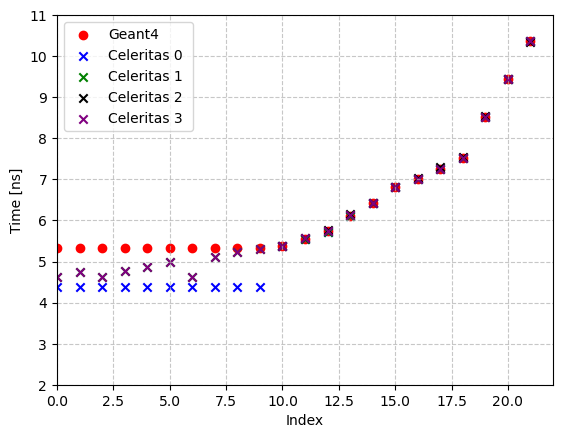

In [128]:
plt.scatter(x = g4.index[0:22], y = g4["t"][0:22], label = "Geant4", c= "red", marker = "o")
plt.scatter(x = celeritas_0.index[0:22], y = celeritas_0["t"][0:22], label = "Celeritas 0 ", c= "blue", marker = "x")
plt.scatter(x = celeritas_1.index[0:22], y = celeritas_1["t"][0:22], label = "Celeritas 1", c= "green", marker = "x")
plt.scatter(x = celeritas_2.index[0:22], y = celeritas_2["t"][0:22], label = "Celeritas 2", c= "black", marker = "x")
plt.scatter(x = celeritas_3.index[0:22], y = celeritas_3["t"][0:22], label = "Celeritas 3", c= "purple", marker = "x")
plt.legend()
plt.xlabel("Index")
plt.ylabel("Time [ns]")
plt.grid(linestyle='--', alpha=0.7)  
plt.xlim(0,22)
plt.ylim(2, 11)
plt.show()

compare ther derivative grid point for two different methods while calcilative the ferivatove calculator for group velocit.


In [132]:
derivative_mean = pd.read_json("//Users/r1i/Desktop/OpticalSims-upstream/build/derivative-mean.jsonl", lines = True)
derivative_grid = pd.read_json("//Users/r1i/Desktop/OpticalSims-upstream/build/derivative-initial.jsonl", lines = True)

In [133]:
derivative_mean.columns

Index(['Grid_index', 'derivative', 'derivative_left', 'derivative_right'], dtype='object')

In [134]:
derivative_grid.columns

Index(['Energy', 'Grid_index', 'derivative_left', 'derivative_right'], dtype='object')

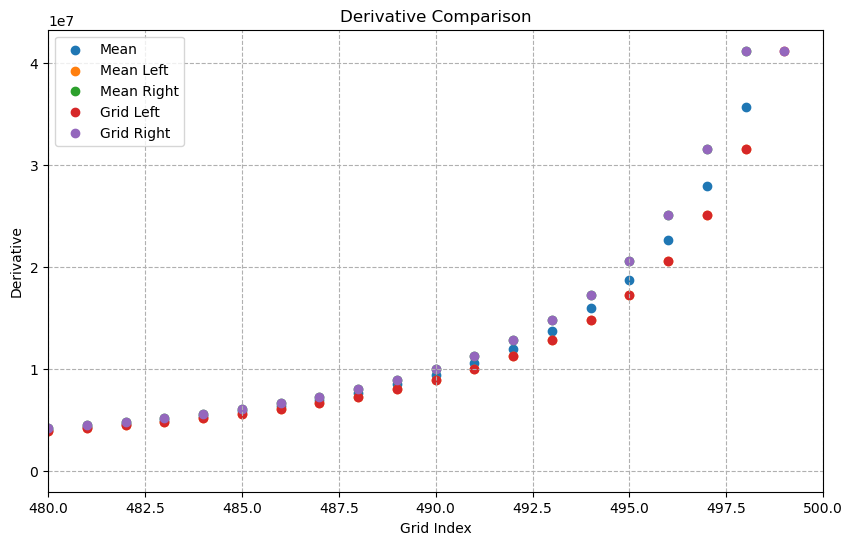

In [146]:
plt.figure(figsize = (10, 6))
plt.scatter(derivative_mean.Grid_index, derivative_mean.derivative, label = "Mean")
plt.scatter(derivative_mean.Grid_index, derivative_mean.derivative_left, label = "Mean Left")
plt.scatter(derivative_mean.Grid_index, derivative_mean.derivative_right, label = "Mean Right")
plt.scatter(derivative_grid.Grid_index, derivative_grid.derivative_left, label = "Grid Left")
plt.scatter(derivative_grid.Grid_index, derivative_grid.derivative_right, label = "Grid Right")
plt.legend()
plt.title("Derivative Comparison")
plt.grid(linestyle = "--")
plt.xlim(480, 500)
plt.xlabel("Grid Index")
plt.ylabel("Derivative")
plt.show()

In [147]:
derivative_mean.iloc[487:-1]

,Grid_index,derivative,derivative_left,derivative_right
487,488,7.655973e+06,7.292857e+06,8.057143e+06
488,489,8.485741e+06,8.057143e+06,8.962500e+06
489,490,9.431463e+06,8.962500e+06,9.952212e+06
490,491,1.056041e+07,9.952212e+06,1.124779e+07
491,492,1.199158e+07,1.124779e+07,1.284071e+07
492,493,1.376579e+07,1.284071e+07,1.483451e+07
493,494,1.594533e+07,1.483451e+07,1.723596e+07
494,495,1.875349e+07,1.723596e+07,2.056404e+07
495,496,2.260175e+07,2.056404e+07,2.508772e+07
496,497,2.793400e+07,2.508772e+07,3.150877e+07


Now, try to run the `dune-gdml` offloading optical photon tracks only.

In [10]:
celeritas_lar = load_celeritas("../build/dune10kt_v5_refactored_1x2x6_e_100MeV_cele.root")
geant4_lar = load_geant("../build/dune10kt_v5_refactored_1x2x6_e_100MeV_g4.root") 

In [22]:
geant4_lar.columns

Index(['x', 'y', 'z', 't', 'wavelength', 'stepLength', 'numSteps'], dtype='object')

In [23]:
step_c, bins_step_c = histogram_distribution(celeritas_lar, "pathLength", bins=50)
step_g, bins_step_g = histogram_distribution(geant4_lar, "stepLength", bins=50)

In [30]:
n_c, bins_c = histogram_distribution(celeritas_lar, "t", bins=50)
n_g, bins_g = histogram_distribution(geant4_lar, "t", bins=50)

/var/folders/5l/8wq0wlqx6mzb26dfrnrf56t80000gp/T/ipykernel_1901/3438911272.py:24: UserWarning: Attempt to set non-positive ylim on a log-scaled axis will be ignored.
  ax.set_ylim(ylim_min, ylim_max)
/var/folders/5l/8wq0wlqx6mzb26dfrnrf56t80000gp/T/ipykernel_1901/3438911272.py:27: RuntimeWarning: divide by zero encountered in divide
  ratio = (counts_c / counts_g) - 1


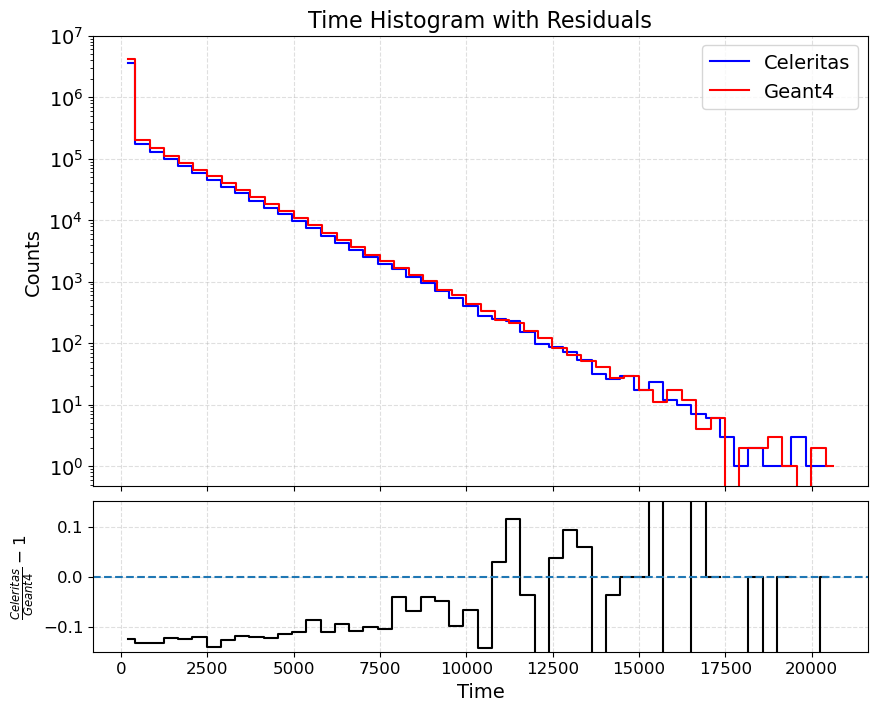

In [18]:
plot_histogram_with_residual(bins_c,bins_g, n_c, n_g, "Time", "Counts", title ="Time Histogram with Residuals",ylim_min = 0, ylim_max = 1e7)

/var/folders/5l/8wq0wlqx6mzb26dfrnrf56t80000gp/T/ipykernel_1901/3438911272.py:24: UserWarning: Attempt to set non-positive ylim on a log-scaled axis will be ignored.
  ax.set_ylim(ylim_min, ylim_max)


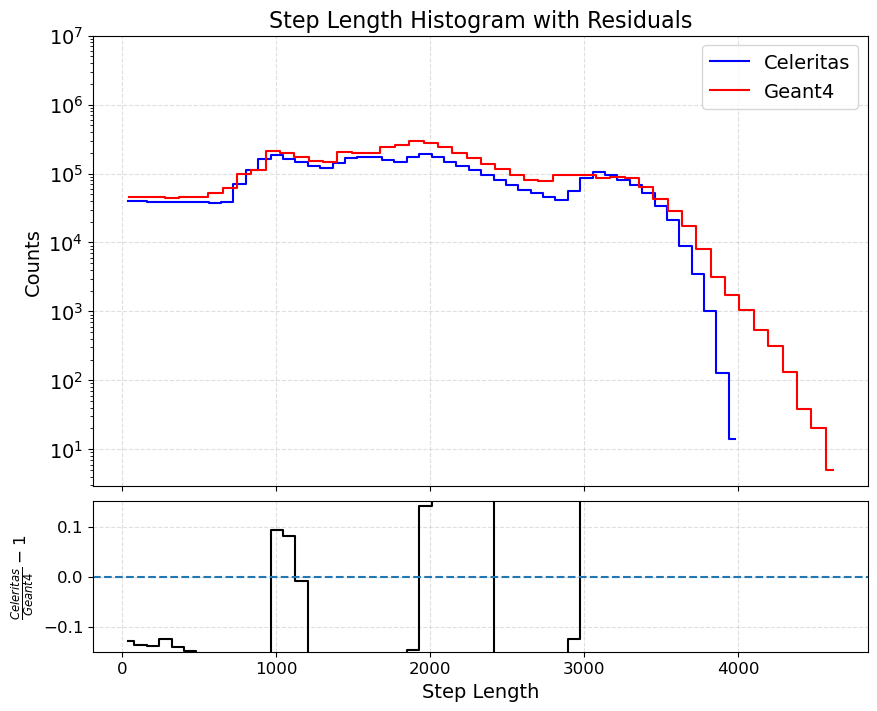

In [24]:
plot_histogram_with_residual(bins_step_c,bins_step_g, step_c, step_g, "Step Length", "Counts", title ="Step Length Histogram with Residuals",ylim_min = 0, ylim_max = 1e7)

In [26]:
celeritas_5 = load_celeritas("../build/dune10kt_v5_refactored_1x2x6_e_100MeV_cele_vg_clamp.root")
geant4_5 = load_geant("../build/dune10kt_v5_refactored_1x2x6_photon_g4.root") 

In [35]:
n_c_5, bins_c_5 = histogram_distribution(celeritas_5, "t", bins=100)
n_g_5, bins_g_5 = histogram_distribution(geant4_5, "t", bins=100)

/var/folders/5l/8wq0wlqx6mzb26dfrnrf56t80000gp/T/ipykernel_1901/3638508963.py:24: UserWarning: Attempt to set non-positive ylim on a log-scaled axis will be ignored.
  ax.set_ylim(ylim_min, ylim_max)
/var/folders/5l/8wq0wlqx6mzb26dfrnrf56t80000gp/T/ipykernel_1901/3638508963.py:27: RuntimeWarning: divide by zero encountered in divide
  ratio = (counts_c / counts_g) - 1
/var/folders/5l/8wq0wlqx6mzb26dfrnrf56t80000gp/T/ipykernel_1901/3638508963.py:27: RuntimeWarning: invalid value encountered in divide
  ratio = (counts_c / counts_g) - 1


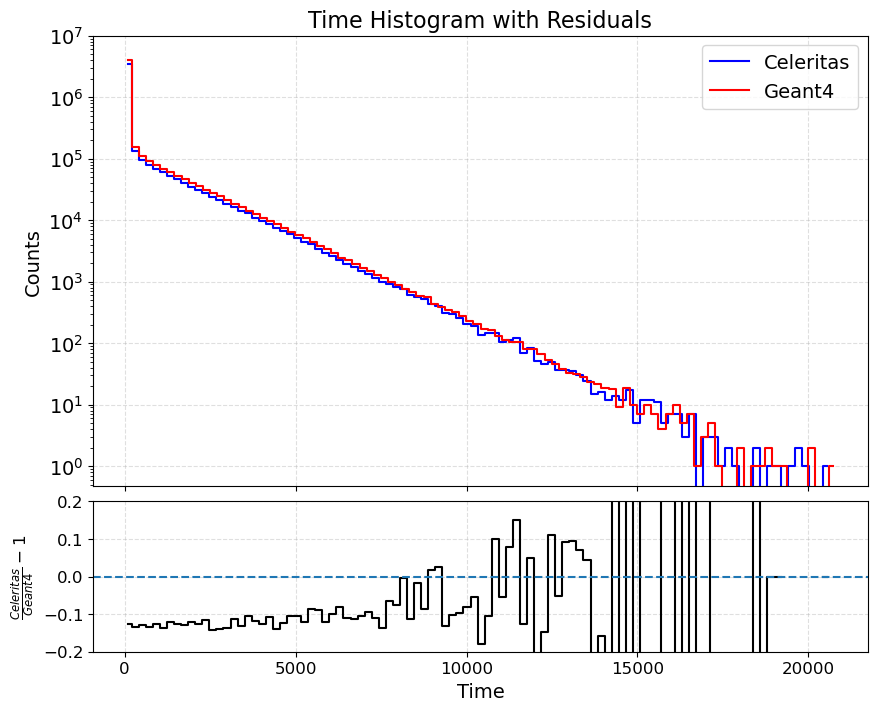

In [36]:
plot_histogram_with_residual(bins_c_5,bins_g_5, n_c_5, n_g_5, "Time", "Counts", title ="Time Histogram with Residuals",ylim_min = 0, ylim_max = 1e7)

/var/folders/5l/8wq0wlqx6mzb26dfrnrf56t80000gp/T/ipykernel_1901/3638508963.py:24: UserWarning: Attempt to set non-positive ylim on a log-scaled axis will be ignored.
  ax.set_ylim(ylim_min, ylim_max)
/var/folders/5l/8wq0wlqx6mzb26dfrnrf56t80000gp/T/ipykernel_1901/3638508963.py:27: RuntimeWarning: divide by zero encountered in divide
  ratio = (counts_c / counts_g) - 1
/var/folders/5l/8wq0wlqx6mzb26dfrnrf56t80000gp/T/ipykernel_1901/3638508963.py:27: RuntimeWarning: invalid value encountered in divide
  ratio = (counts_c / counts_g) - 1


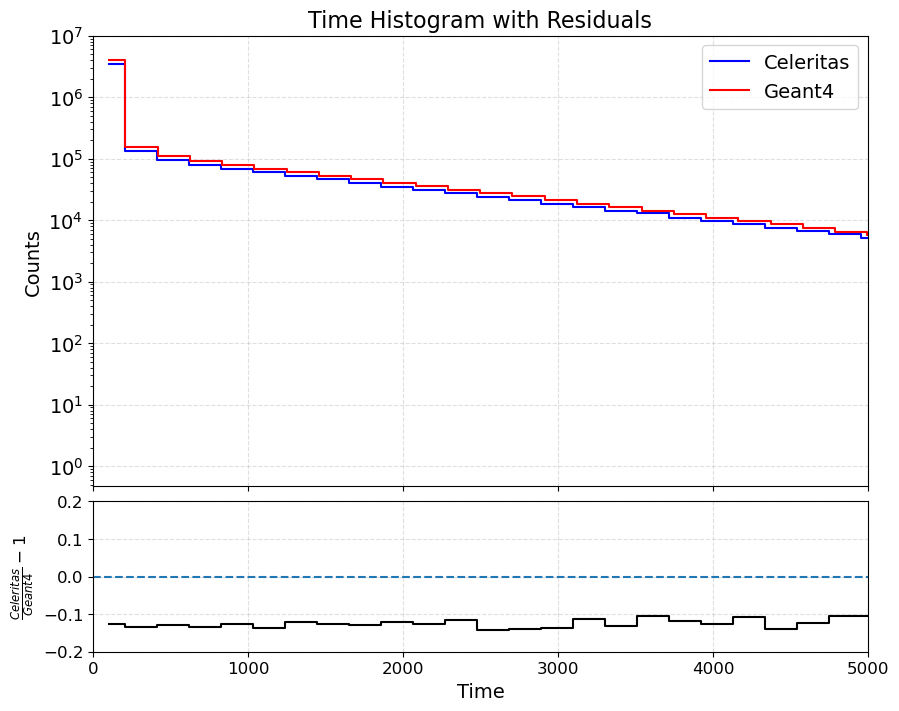

In [38]:
plot_histogram_with_residual(bins_c_5,bins_g_5, n_c_5, n_g_5, "Time", "Counts", title ="Time Histogram with Residuals",ylim_min = 0, ylim_max = 1e7, xlim = (0, 5000))

In [39]:
celeritas_lar_abslength = load_celeritas("../build/dune10kt_v5_refactored_1x2x6_photon_cele.root")
geant4_lar_abslength = load_geant("../build/dune10kt_v5_refactored_1x2x6_photon_g4.root") 

In [42]:
n_c_6, bins_c_6 = histogram_distribution(celeritas_lar_abslength, "t", bins=50)
n_g_6, bins_g_6 = histogram_distribution(geant4_lar_abslength, "t", bins=50)

/var/folders/5l/8wq0wlqx6mzb26dfrnrf56t80000gp/T/ipykernel_1901/3638508963.py:24: UserWarning: Attempt to set non-positive ylim on a log-scaled axis will be ignored.
  ax.set_ylim(ylim_min, ylim_max)
/var/folders/5l/8wq0wlqx6mzb26dfrnrf56t80000gp/T/ipykernel_1901/3638508963.py:27: RuntimeWarning: divide by zero encountered in divide
  ratio = (counts_c / counts_g) - 1


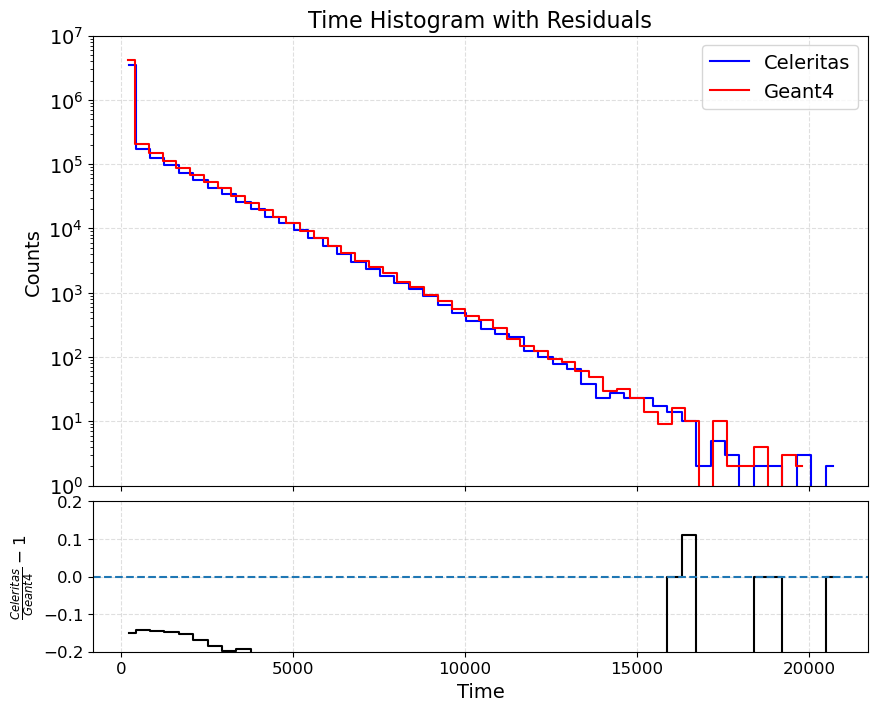

In [43]:
plot_histogram_with_residual(bins_c_6,bins_g_6, n_c_6, n_g_6, "Time", "Counts", title ="Time Histogram with Residuals",ylim_min = 0, ylim_max = 1e7)

In [ ]:
#This is in directory 10 in vg_comparison with commit f08ed9a6172c0141f13cd900035b472b5fa03736 + bee79b53b4162ae344152721ace9fd54e95ac8f6
celeritas_7 = load_celeritas("../build/dune10kt_v5_refactored_1x2x6_photon_cele.root")
geant4_7 = load_geant("../build/dune10kt_v5_refactored_1x2x6_photon_g4.root") 

In [57]:
celeritas_7.columns

Index(['x', 'y', 'z', 't', 'wavelength', 'pathLength', 'numSteps'], dtype='object')

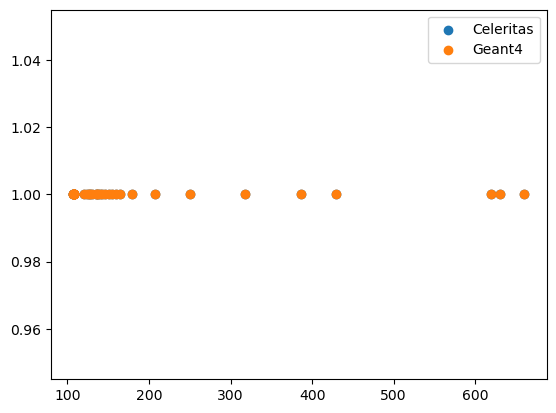

In [66]:
plt.scatter(celeritas_7["wavelength"], celeritas_7["numSteps"])
plt.scatter(geant4_7["wavelength"], geant4_7["numSteps"])
plt.legend(["Celeritas", "Geant4"])
plt.show()

In [55]:
celeritas_7.t

Series([], Name: t, dtype: float64)

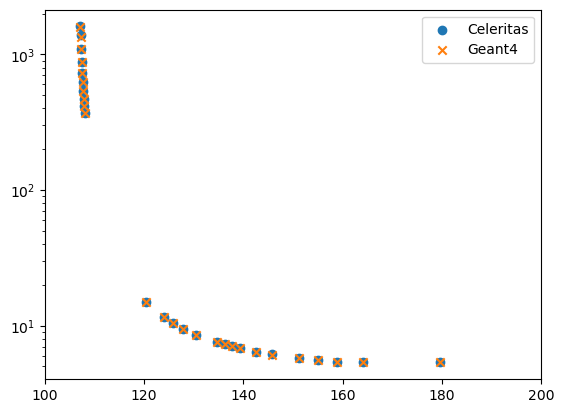

In [106]:
plt.scatter(celeritas_7["wavelength"], celeritas_7["t"])
plt.scatter(geant4_7["wavelength"], geant4_7["t"], marker = 'x')
plt.legend(["Celeritas", "Geant4"])
plt.yscale("log")
plt.xlim(100,200)
#plt.xlim(75,100)
plt.show()

In [74]:
#changed the LAr to finite abslength
celeritas_8 = load_celeritas("../build/dune10kt_v5_refactored_1x2x6_photon_cele_abs_finite.root")
geant4_8 = load_geant("../build/dune10kt_v5_refactored_1x2x6_photon_g4_abs_finite.root") 

In [94]:
celeritas_8 = velocity(celeritas_8, "pathLength")
geant4_8 = velocity(geant4_8, "stepLength")

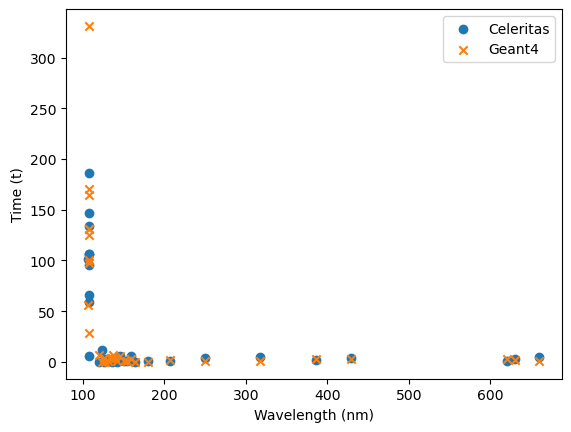

In [108]:
plt.scatter(celeritas_8["wavelength"], celeritas_8["t"])
plt.scatter(geant4_8["wavelength"], geant4_8["t"], marker = 'x')
plt.legend(["Celeritas", "Geant4"])
plt.xlabel("Wavelength (nm)")
plt.ylabel("Time (t)")
#plt.ylim(0, 20)
#plt.xlim(130, 600)
plt.show()

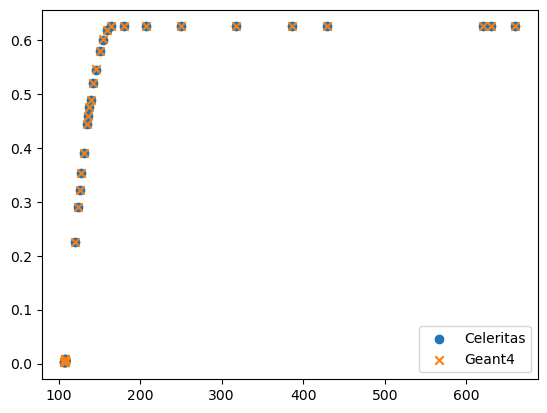

In [96]:
plt.scatter(celeritas_8["wavelength"], celeritas_8["rough_velocity"])
plt.scatter(geant4_8["wavelength"], geant4_8["rough_velocity"], marker = 'x')
plt.legend(["Celeritas", "Geant4"])
#plt.ylim(0, 12)
#plt.xlim(107,108)
plt.show()